# Ecopetrol
Sergio Cabrales, Universidad de los Andes

https://www.sac2.com/

## Setup

In [52]:
pip install yfinance

In [53]:
import numpy as np
import pandas as pd
import openpyxl
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import yfinance as yf
from os.path import altsep


In [54]:
EXCEL_PATH = "excel-1t26-esp.xlsm"

"""Lectura rápida de series del Excel de resultados de Ecopetrol.

Optimización clave: cada hoja se lee UNA sola vez a memoria (lista de tuplas)
y las búsquedas posteriores son diccionarios O(1). Se evita ws.cell() en modo
read_only, cuyo acceso aleatorio re-parsea el XML de la hoja en cada llamada.
"""
from functools import lru_cache
import openpyxl
import numpy as np

FILA_PERIODOS = 7   # encabezados '1T 2021', '12M 2024', ...
COL_ETIQUETAS = 1   # columna B (índice 0-based)
COL_DATOS_INI = 2   # columna C (índice 0-based)


@lru_cache(maxsize=None)
def _workbook():
    return openpyxl.load_workbook(EXCEL_PATH, data_only=True, read_only=True)


@lru_cache(maxsize=None)
def _hoja(nombre):
    """Devuelve (filas, cols_periodo, filas_etiqueta) de una hoja, leída una sola vez.

    - filas: tupla de tuplas con los valores (0-based).
    - cols_periodo: {periodo -> índice de columna} según la fila 7.
    - filas_etiqueta: {etiqueta -> primer índice de fila} según la columna B.
    """
    ws = _workbook()[nombre]
    # La dimensión declarada puede ser absurda (p. ej. XDW68 por celdas con
    # formato). El primer bloque de periodos termina en el primer hueco de la
    # fila 7 (a la derecha hay bloques duplicados: USD, variaciones %, inglés).
    filas = tuple(ws.iter_rows(values_only=True))
    encabezado = filas[FILA_PERIODOS - 1]
    cols_periodo = {}
    ultimo = COL_DATOS_INI
    for i in range(COL_DATOS_INI, len(encabezado)):
        if encabezado[i] is None:
            break
        cols_periodo[str(encabezado[i]).strip()] = i
        ultimo = i
    filas = tuple(f[:ultimo + 1] for f in filas)
    filas_etiqueta = {}
    for r, f in enumerate(filas):
        v = f[COL_ETIQUETAS] if len(f) > COL_ETIQUETAS else None
        if v is not None:
            filas_etiqueta.setdefault(str(v).strip(), r)
    return filas, cols_periodo, filas_etiqueta


def _limpiar(v):
    return np.nan if v in (None, "-") else v


def leer_serie(hoja, etiqueta, periodos):
    """Serie de una fila (columna B = etiqueta) alineada al orden de `periodos`."""
    filas, cols, etiquetas = _hoja(hoja)
    if etiqueta not in etiquetas:
        raise ValueError(f"Etiqueta '{etiqueta}' no encontrada en '{hoja}'.")
    fila = filas[etiquetas[etiqueta]]
    return [_limpiar(fila[cols[p]]) if p in cols and cols[p] < len(fila) else np.nan
            for p in periodos]


def leer_serie_segmento(hoja, segmento, etiqueta, periodos):
    """Serie de una hoja con bloques de segmento apilados verticalmente.

    Cada bloque inicia con un título en la columna B del tipo
    'Miles de Millones (COP) - UPSTREAM' que repite los periodos en esa misma
    fila. `segmento` puede ser el nombre corto ('UPSTREAM') o el título completo.
    """
    filas, _, _ = _hoja(hoja)
    seg_lower = segmento.strip().casefold()

    inicio = fin = None

    # A segment marker can be either a "Miles de Millones" header, or
    # the segment name itself (like "Refinería de Cartagena").
    for r, f in enumerate(filas):
        v_col_etiquetas = f[COL_ETIQUETAS] if len(f) > COL_ETIQUETAS else None

        # Identify the start of our specific segment block
        if inicio is None and v_col_etiquetas is not None and str(v_col_etiquetas).strip().casefold() == seg_lower:
            inicio = r
        # If we've found the start, the next segment marker (another "Miles de Millones"
        # segment, another refinery segment, or a blank line) marks the end of the current segment's data.
        elif inicio is not None:
            # Check if this row is a new segment marker or a blank line
            is_new_miles_de_millones_segment = (
                v_col_etiquetas is not None and
                str(v_col_etiquetas).strip().casefold().startswith("miles de millones")
            )
            is_new_refinery_segment = (
                v_col_etiquetas is not None and
                str(v_col_etiquetas).strip().casefold() != seg_lower and # Ensure it's not the current segment itself
                (str(v_col_etiquetas).strip().casefold() == "refinería de cartagena" or
                 str(v_col_etiquetas).strip().casefold() == "refinería de barrancabermeja")
            )
            # Nota: NO se corta en filas en blanco. Dentro de un mismo bloque de
            # segmento hay filas separadoras con la columna B vacía (p. ej. antes
            # de EBITDA o Margen EBITDA); tratarlas como fin de bloque cortaba el
            # segmento antes de llegar a esas etiquetas y producía falsos
            # "Etiqueta no encontrada" (ver celdas de EBITDA por segmento).

            if is_new_miles_de_millones_segment or is_new_refinery_segment:
                fin = r
                break

    if inicio is None:
        raise ValueError(f"Segmento '{segmento}' no encontrado en '{hoja}'.")

    fin = fin if fin is not None else len(filas) # If no end found, segment extends to the end of the sheet

    cols = {}
    fila_titulo = filas[inicio] # The segment header row itself
    # For segments like "Refinería de Cartagena", the periods are likely in FILA_PERIODOS (row 7)
    # If the segment header row doesn't contain periods, fall back to FILA_PERIODOS for column mapping.
    if all(fila_titulo[i] is None for i in range(COL_DATOS_INI, len(fila_titulo))): # Check if the segment row itself contains periods
        _ , cols, _ = _hoja(hoja) # Reuse the cols from the sheet's main header if segment row has no periods.
    else:
        for i in range(COL_DATOS_INI, len(fila_titulo)):
            if fila_titulo[i] is None:
                break
            cols[str(fila_titulo[i]).strip()] = i

    fila_dato = next((f for f in filas[inicio + 1:fin]
                      if len(f) > COL_ETIQUETAS and f[COL_ETIQUETAS] is not None
                      and str(f[COL_ETIQUETAS]).strip().casefold() == etiqueta.casefold()), None)
    if fila_dato is None:
        raise ValueError(f"Etiqueta '{etiqueta}' no encontrada en el segmento "
                         f"'{segmento}' de '{hoja}'.")
    return [_limpiar(fila_dato[cols[p]]) if p in cols and cols[p] < len(fila_dato) else np.nan
            for p in periodos]

In [55]:
# ---------- Tema Bloomberg ----------
def apply_bloomberg_theme():
    """Configura rcParams globales con estética Bloomberg (fondo negro)."""
    mpl.rcParams.update({
        "figure.facecolor":  "#000000",
        "axes.facecolor":    "#000000",
        "axes.edgecolor":    "#444444",
        "axes.labelcolor":   "#FFFFFF",
        "text.color":        "#FFFFFF",
        "xtick.color":       "#FFFFFF",
        "ytick.color":       "#FFFFFF",
        "xtick.labelsize":   8,
        "ytick.labelsize":   8,
        "font.family":       "monospace",
        "legend.facecolor":  "#111111",
        "legend.edgecolor":  "#444444",
        "legend.fontsize":   8,
        "figure.dpi":        150,
        # Grilla estilo estándar integrada
        "axes.grid":         True,
        "axes.grid.axis":    "y",
        "grid.linestyle":    "--",
        "grid.color":        "gray",
        "grid.alpha":        0.6,
        "axes.axisbelow":    True,
        # Spines superiores y derechos ocultos
        "axes.spines.top":   False,
        "axes.spines.right": False,
    })

## Datos

In [56]:
# ─── Transferencias de Ecopetrol a la Nación ────────────────────
anios = ["2018", "2019", "2020", "2021", "2022", "2023", "2024"]
dividendos = np.array([6.1, 11.4, 6.5, 5.6, 16.3, 21.6, 11.4])
regalias = np.array([0, 5.8, 3.9, 4.8, 9.7, 10.1, 10.1])
impuestos_terceros = np.array([10.0, 6.0, 5.8, 5.8, 5.9, 7.3, 7.6])
impuestos_propios = np.array([5.9, 3.1, 2.0, 2.6, 10.5, 19.3, 11.3])

In [57]:
# ─── Utilidad Neta Trimestral (2021-2025) ────────────────────────
trimestres = [
#    "1T 2020", "2T 2020", "3T 2020", "4T 2020",
    "1T 2021", "2T 2021", "3T 2021", "4T 2021",
    "1T 2022", "2T 2022", "3T 2022", "4T 2022",
    "1T 2023", "2T 2023", "3T 2023", "4T 2023",
    "1T 2024", "2T 2024", "3T 2024", "4T 2024",
    "1T 2025", "2T 2025", "3T 2025", "4T 2025",
    "1T 2026"
]
utilidad_neta = leer_serie("P&G - P&L", "Utilidad neta atribuible a accionistas de Ecopetrol", trimestres)
utilidad_neta_billones = [v / 1000 for v in utilidad_neta]

# ─── Precio Brent (USD/barril) ────────────────────────────────────
precio_brent = leer_serie("Precios - Prices", "Brent", trimestres)

# ─── Producción (kbped) ──────────────────────────────────────────
produccion = leer_serie("UP", "Total Grupo Empresarial", trimestres)

In [58]:
# ─── Descarga USD/COP desde Yahoo Finance ────────────────────────
df = yf.download("COP=X", start="2020-01-01", interval="1d", auto_adjust=True)

# Promedio mensual del cierre
trm_mes = df["Close"].squeeze().resample("MS").mean().round(2)

# ─── Construcción del diccionario TRM_mensual ────────────────────
TRM_mensual = {
    año: grupo.tolist()
    for año, grupo in trm_mes.groupby(trm_mes.index.year)
}

print(TRM_mensual)

[*********************100%***********************]  1 of 1 completed

{2020: [3309.22, 3402.95, 3868.95, 3966.55, 3862.42, 3701.31, 3657.63, 3783.71, 3747.29, 3828.78, 3685.65, 3469.16], 2021: [3485.63, 3549.55, 3610.41, 3652.27, 3736.84, 3687.4, 3822.73, 3885.53, 3816.47, 3768.61, 3893.7, 3962.68], 2022: [3996.54, 3932.03, 3799.87, 3787.82, 4022.43, 3940.06, 4384.38, 4319.84, 4442.96, 4715.98, 4916.8, 4786.09], 2023: [4709.91, 4777.32, 4754.69, 4533.99, 4544.28, 4202.84, 4062.24, 4063.47, 4003.62, 4215.3, 4029.17, 3951.44], 2024: [3908.51, 3917.86, 3890.83, 3863.22, 3865.61, 4049.36, 4041.5, 4060.78, 4186.68, 4253.77, 4396.65, 4373.97], 2025: [4285.95, 4123.58, 4121.46, 4265.05, 4204.68, 4101.62, 4047.3, 4047.85, 3921.33, 3879.28, 3763.94, 3790.81], 2026: [3681.81, 3668.62, 3710.15, 3624.54, 3722.16, 3510.0, 3310.06]}


In [59]:
def _trm_trimestral(TRM_dict):
    q = []
    for year in [2021, 2022, 2023, 2024, 2025]:
        m = TRM_dict[year]
        q += [np.mean(m[0:3]), np.mean(m[3:6]), np.mean(m[6:9]), np.mean(m[9:12])]

    # Handle 2026 separately as only 1T is available in utilidad_neta
    if 2026 in TRM_dict:
        m_2026 = TRM_dict[2026]
        if len(m_2026) >= 1:
            # Take the mean of available months for 1T 2026
            q.append(np.mean(m_2026[:min(len(m_2026), 3)]))
    return q

TRM_trimestral = _trm_trimestral(TRM_mensual)
utilidad_usd_millions = np.array(utilidad_neta_billones) * (1000.0 / np.array(TRM_trimestral)) * 1000.0

In [60]:
# ─── Costo de Levantamiento y Margen EBITDA (2020-2025) ─────────
trimestres_ext = [
#    "1T 2020", "2T 2020", "3T 2020", "4T 2020",
    "1T 2021", "2T 2021", "3T 2021", "4T 2021",
    "1T 2022", "2T 2022", "3T 2022", "4T 2022",
    "1T 2023", "2T 2023", "3T 2023", "4T 2023",
    "1T 2024", "2T 2024", "3T 2024", "4T 2024",
    "1T 2025", "2T 2025", "3T 2025", "4T 2025",
    "1T 2026"
]
costo_levantamiento = leer_serie("Financieros - Financials", "Costo de Levantamiento", trimestres_ext)
margen_ebitda = [v * 100 for v in leer_serie("P&G - P&L", "Margen EBITDA", trimestres_ext)]

# ─── Compañías Petroleras (FY 2024 vs FY 2025) ──────────────────
companies = [
    "Aramco*", "Exxon Mobil", "Petrobras*", "Shell",
    "Chevron", "TotalEnergies", "BP", "Equinor", "Eni", "Ecopetrol",
]
net_income_fy2024 = [106.0, 33.7, 23.0, 16.5, 17.7, 18.3, 8.9, 8.8, 2.8, 3.6]
net_income_fy2025 = [ 97.0, 28.8, 22.0, 18.1, 12.5, 18.5, 7.5, 1.3, 2.7, 2.2]
percent_change = [
    ((y - x) / abs(x) * 100) if x != 0 else 0
    for x, y in zip(net_income_fy2024, net_income_fy2025)
]

# ─── Reservas Probadas de Ecopetrol (MBPE) ──────────────────────
years_reservas = np.array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
crudo_nal = np.array([1016, 1068, 1172, 1215, 1111, 1256, 1326, 1296, 1364, 1497])
gas_nal   = np.array([ 561,  568,  523,  484,  491,  519,  457,  373,  325,  264])
internac  = np.array([  20,   24,   33,  195,  169,  227,  228,  214,  204,  183])
total_reservas = crudo_nal + gas_nal + internac

# ─── Waterfall Reservas Probadas 2024 → 2025 ────────────────────
wf_start = 1892.7
wf_steps = [
    ("Revisiones*", 140.8),
    ("Recobro\nMejorado", 142.6),
    ("Extensiones y\nDescubrimientos", 16.1),
    ("Compras/\nVentas", 0.0),
    ("Producción", -248.0),
]
wf_end = 1944.2

## Transferencias de Ecopetrol a la Nación

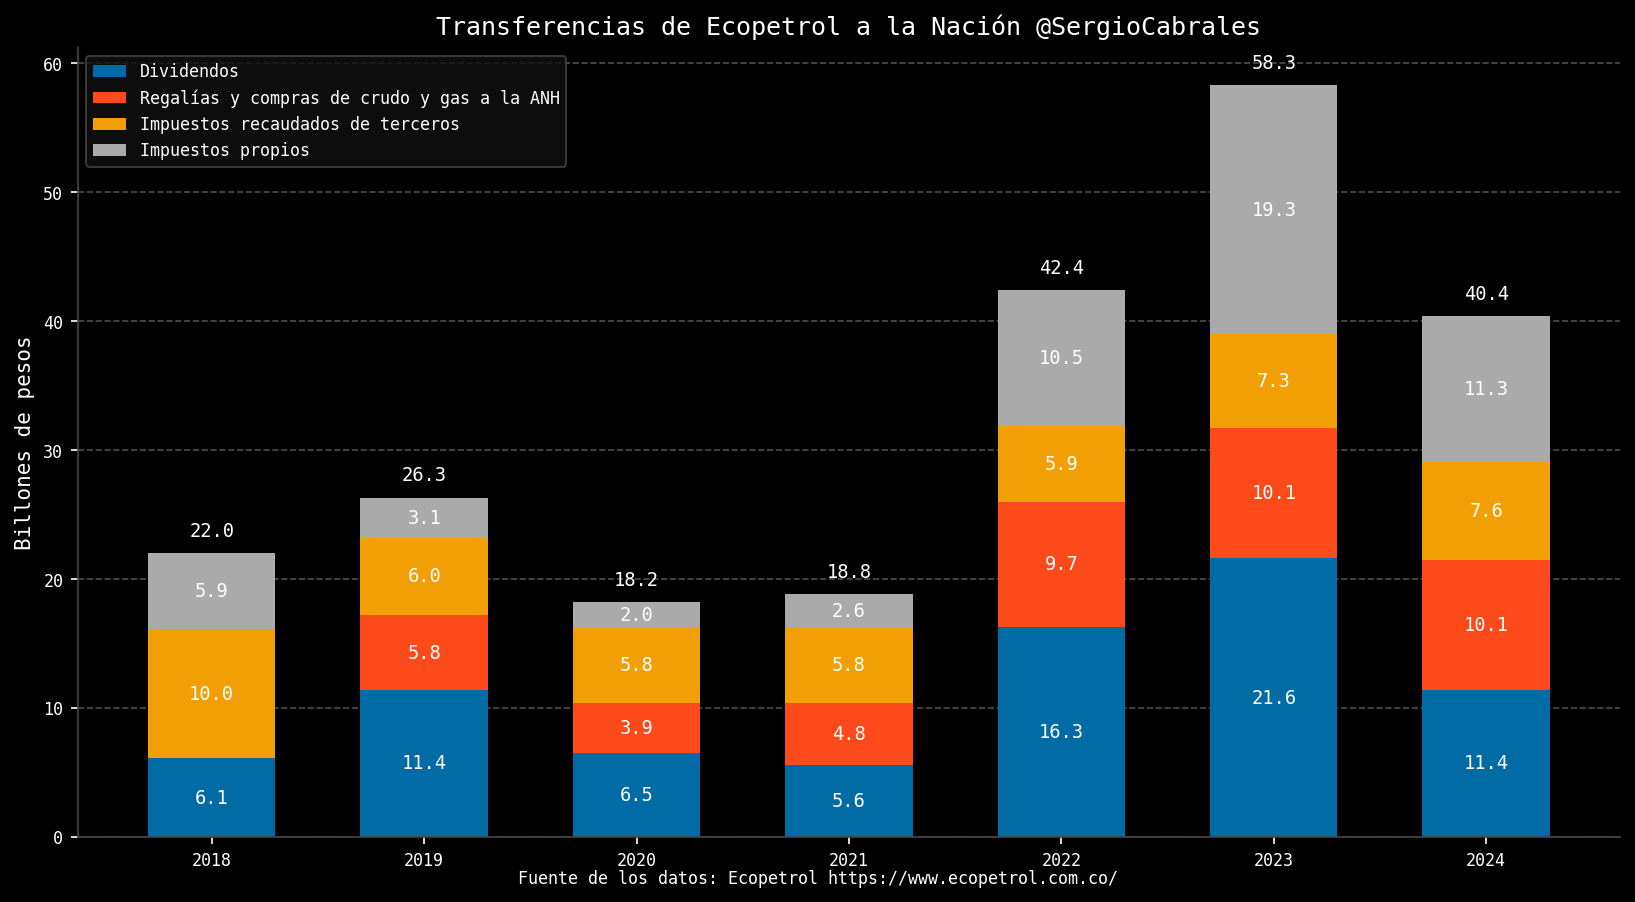

In [61]:
apply_bloomberg_theme()
fig, ax = plt.subplots(figsize=(11, 6))
bar_width = 0.6
bar1 = ax.bar(anios, dividendos, label="Dividendos", color="#006BA4", width=bar_width)
bar2 = ax.bar(anios, regalias, bottom=dividendos, label="Regalías y compras de crudo y gas a la ANH", color="#FC4A1A", width=bar_width)
bar3 = ax.bar(anios, impuestos_terceros, bottom=dividendos + regalias, label="Impuestos recaudados de terceros", color="#F29F05", width=bar_width)
bar4 = ax.bar(anios, impuestos_propios, bottom=dividendos + regalias + impuestos_terceros, label="Impuestos propios", color="#AAAAAA", width=bar_width)
for bars in [bar1, bar2, bar3, bar4]:
    for bar in bars:
        yval = bar.get_height()
        if yval > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + yval / 2,
                    round(yval, 1), va='center', ha='center', color='white', fontsize=9)
totals = dividendos + regalias + impuestos_terceros + impuestos_propios
for i, total in enumerate(totals):
    ax.text(i, total + 1, round(total, 1), ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Billones de pesos")
ax.set_title("Transferencias de Ecopetrol a la Nación @SergioCabrales")
ax.legend()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Producción

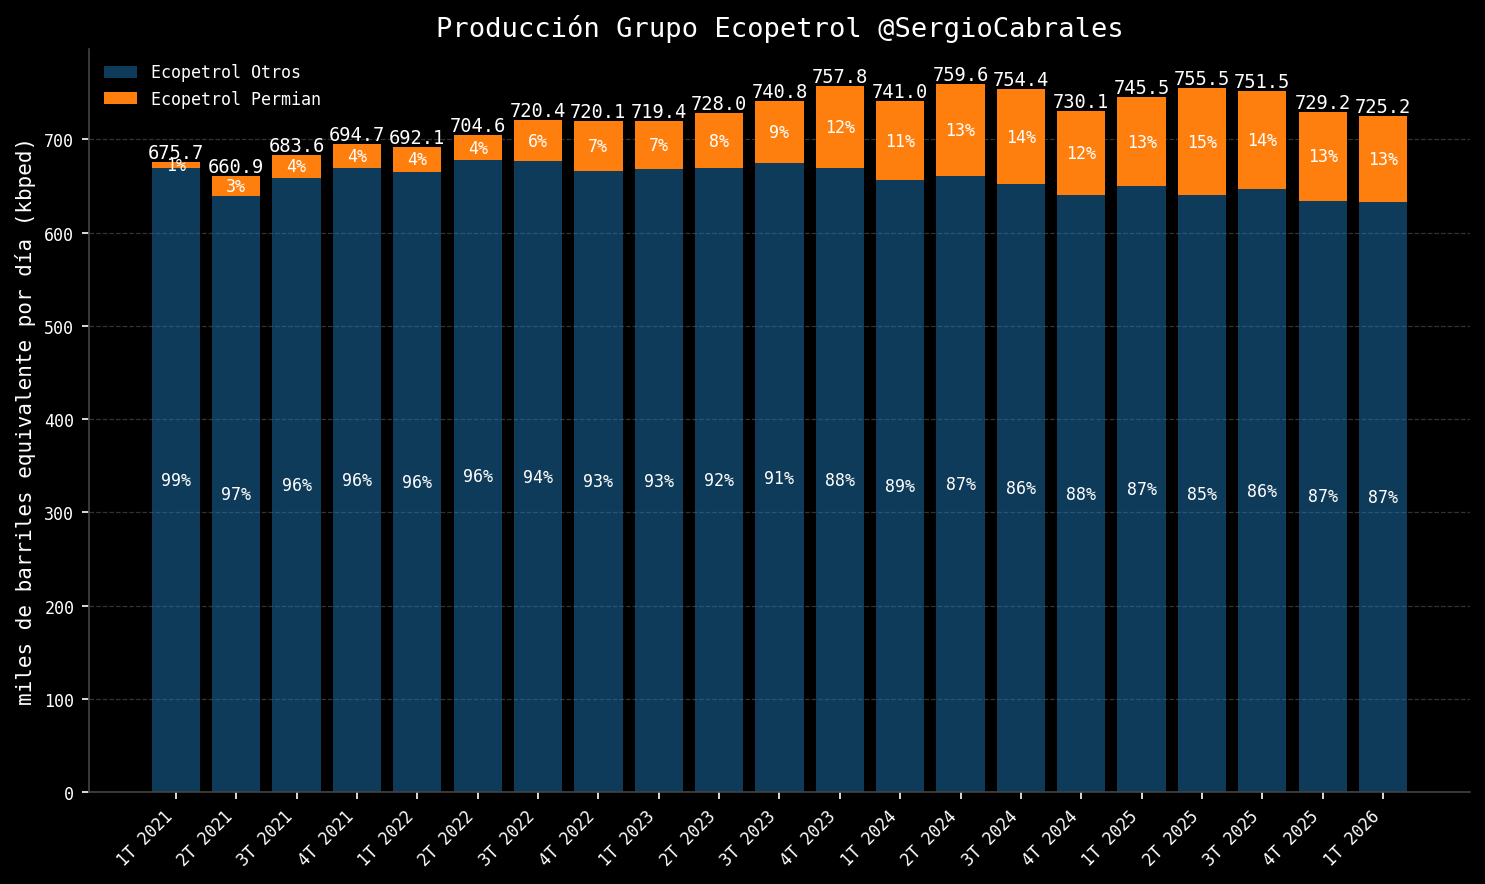

In [62]:
# Datos
periodos = [
    "1T 2021","2T 2021","3T 2021","4T 2021",
    "1T 2022","2T 2022","3T 2022","4T 2022",
    "1T 2023","2T 2023","3T 2023","4T 2023",
    "1T 2024","2T 2024","3T 2024","4T 2024",
    "1T 2025","2T 2025","3T 2025","4T 2025",
    "1T 2026",
]

permian = leer_serie("UP", "Total Ecopetrol Permian", periodos)
total   = leer_serie("UP", "Total Grupo Empresarial", periodos)
otros   = [t - p for t, p in zip(total, permian)]

df = pd.DataFrame({
    "Periodo": periodos,
    "Ecopetrol Permian": permian,
    "Ecopetrol Otros": otros,
    "Total Grupo Ecopetrol": total
})

# Eje x
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(10, 6))

# Barras apiladas: primero "otros" y encima "Permian"
b1 = ax.bar(x, df["Ecopetrol Otros"].values, label="Ecopetrol Otros", alpha=0.5)
b2 = ax.bar(x, df["Ecopetrol Permian"].values, bottom=df["Ecopetrol Otros"].values, label="Ecopetrol Permian")

# Etiquetas con el total en la parte superior
for i, (xt, tot) in enumerate(zip(x, df["Total Grupo Ecopetrol"].values)):
    ax.text(xt, tot, f"{tot:.1f}", ha="center", va="bottom", fontsize=9)

# Porcentaje de Permian centrado en su segmento
perc_permian = (df["Ecopetrol Permian"].values / df["Total Grupo Ecopetrol"].values) * 100.0
for i, xt in enumerate(x):
    base = df["Ecopetrol Otros"].values[i]
    altura_perm = df["Ecopetrol Permian"].values[i]
    if altura_perm > 1:
        y_text = base + altura_perm / 2.0
        ax.text(xt, y_text, f"{perc_permian[i]:.0f}%", ha="center", va="center", fontsize=8)

# Porcentaje de Ecopetrol Otros centrado en su segmento
perc_otros = (df["Ecopetrol Otros"].values / df["Total Grupo Ecopetrol"].values) * 100.0
for i, bar in enumerate(b1):
    val = df["Ecopetrol Otros"].values[i]
    if val > 1: # Only add if value is greater than 0 to avoid clutter
        y_text = bar.get_y() + bar.get_height() / 2.0
        ax.text(bar.get_x() + bar.get_width() / 2, y_text,
                f"{perc_otros[i]:.0f}%", ha="center", va="center", fontsize=8)

# Estilo "The Economist" aproximado: sin borde superior ni derecho, espinas finas, cuadrícula sutil en Y
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.set_title("Producción Grupo Ecopetrol @SergioCabrales", fontsize=13)
ax.set_ylabel("miles de barriles equivalente por día (kbped)", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(df["Periodo"].tolist(), rotation=45, ha="right")

ax.yaxis.grid(True, linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)

# Leyenda fuera del gráfico a la derecha
legend = ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

## Capex por Segmento

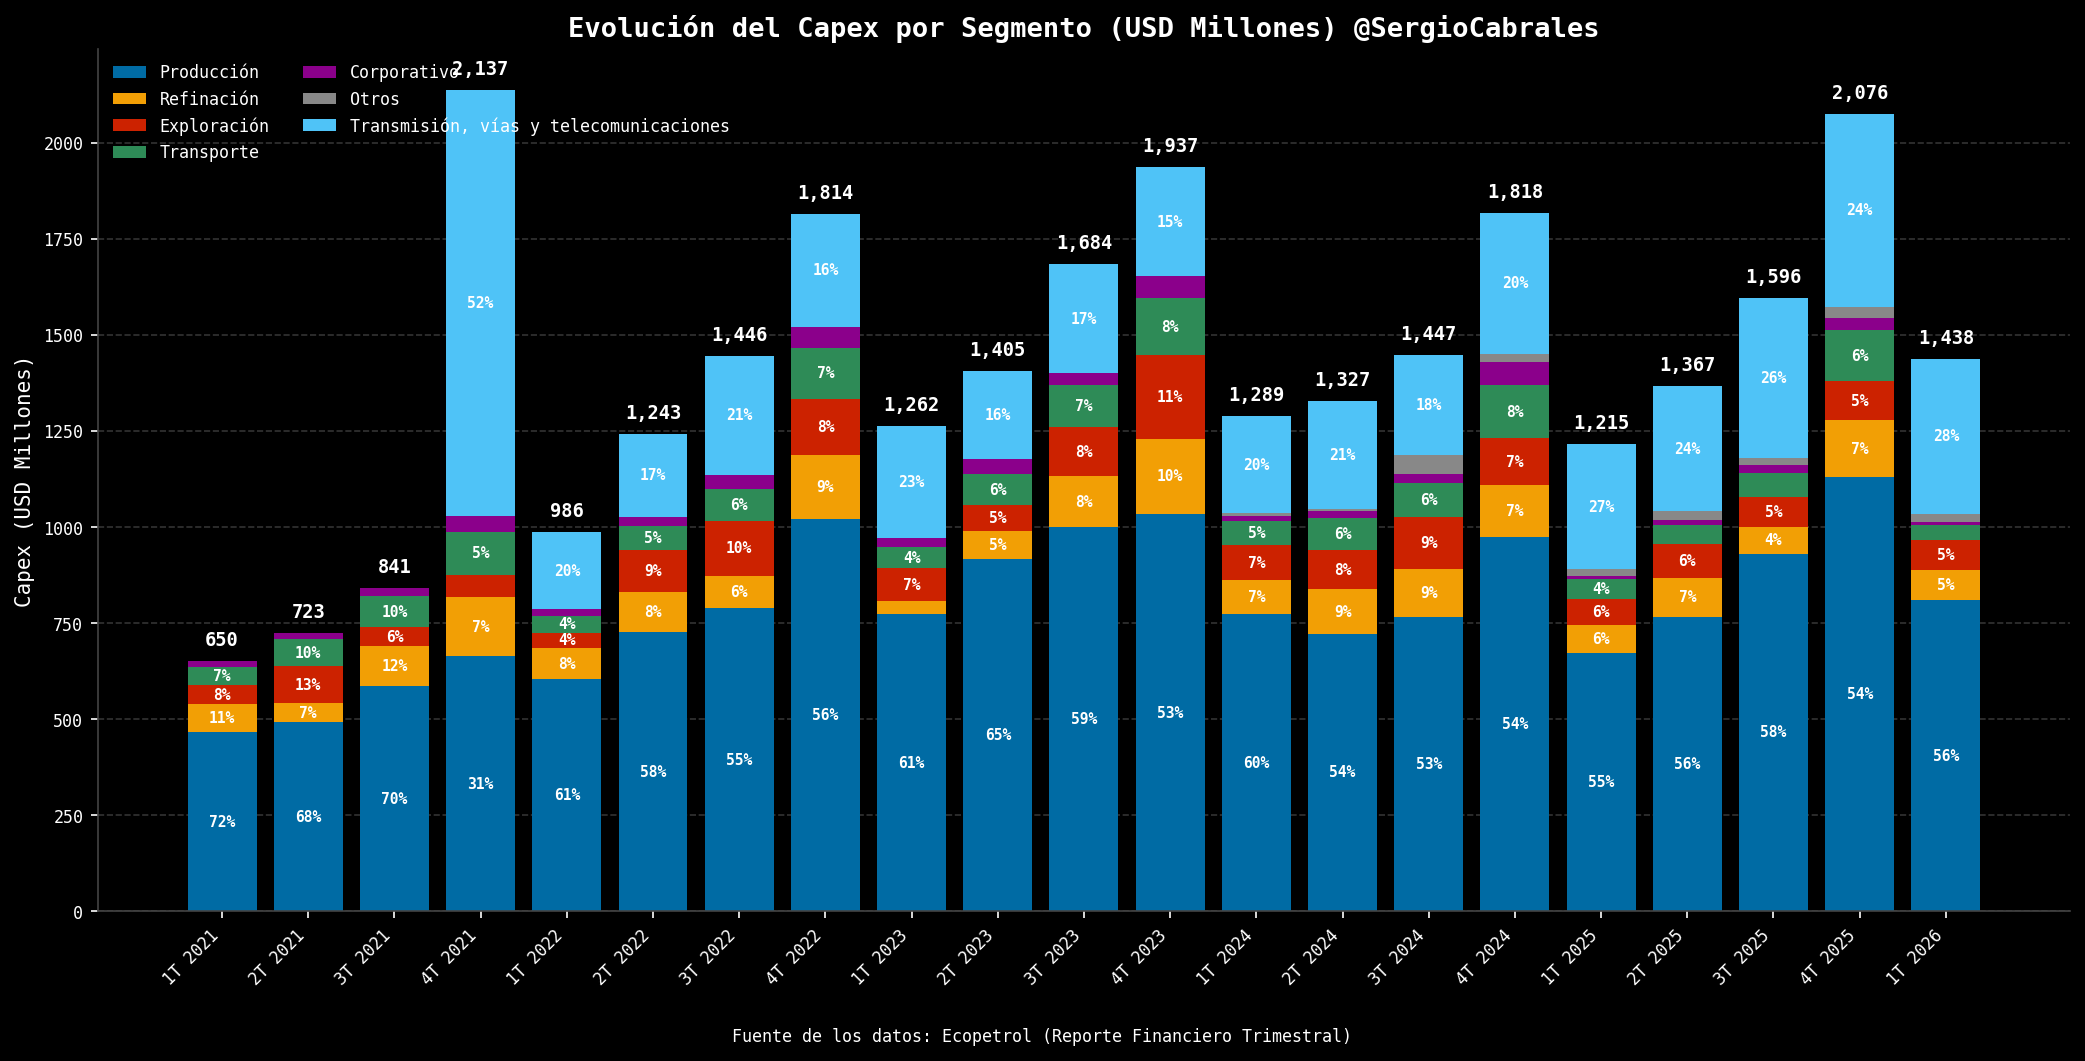

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Datos: Capex por segmento (USD Millones), hoja "Financieros - Financials"
periodos_capex = trimestres  # 1T 2021 ... 1T 2026

segmentos_capex = [
    "Producción", "Refinación", "Exploración", "Transporte",
    "Corporativo", "Otros", "Transmisión, vías y telecomunicaciones",
]
colores_capex = ["#006BA4", "#F29F05", "#CC2200", "#2E8B57", "#8B008B", "#888888", "#4FC3F7"]

capex = {seg: np.array(leer_serie("Financieros - Financials", seg, periodos_capex)) for seg in segmentos_capex}
capex_total = np.array(leer_serie("Financieros - Financials", "Total", periodos_capex))

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(periodos_capex))
bottom = np.zeros(len(periodos_capex))

for seg, color in zip(segmentos_capex, colores_capex):
    valores = capex[seg]
    ax.bar(x, valores, bottom=bottom, color=color, label=seg)
    porcentajes = np.divide(valores, capex_total, out=np.zeros_like(valores), where=capex_total != 0) * 100
    for i, (v, pct) in enumerate(zip(valores, porcentajes)):
        if v > capex_total[i] * 0.04:  # solo mostrar la etiqueta si el segmento es visible en la barra
            ax.text(x[i], bottom[i] + v / 2, f"{pct:.0f}%",
                    ha="center", va="center", fontsize=7, color="white", fontweight="bold")
    bottom += valores

for i, total in enumerate(capex_total):
    ax.text(x[i], total + 30, f"{total:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Evolución del Capex por Segmento (USD Millones) @SergioCabrales", fontsize=13, weight="bold")
ax.set_ylabel("Capex (USD Millones)")
ax.set_xticks(x)
ax.set_xticklabels(periodos_capex, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.figtext(0.5, 0.0, "Fuente de los datos: Ecopetrol (Reporte Financiero Trimestral)", ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Canasta de venta de crudo

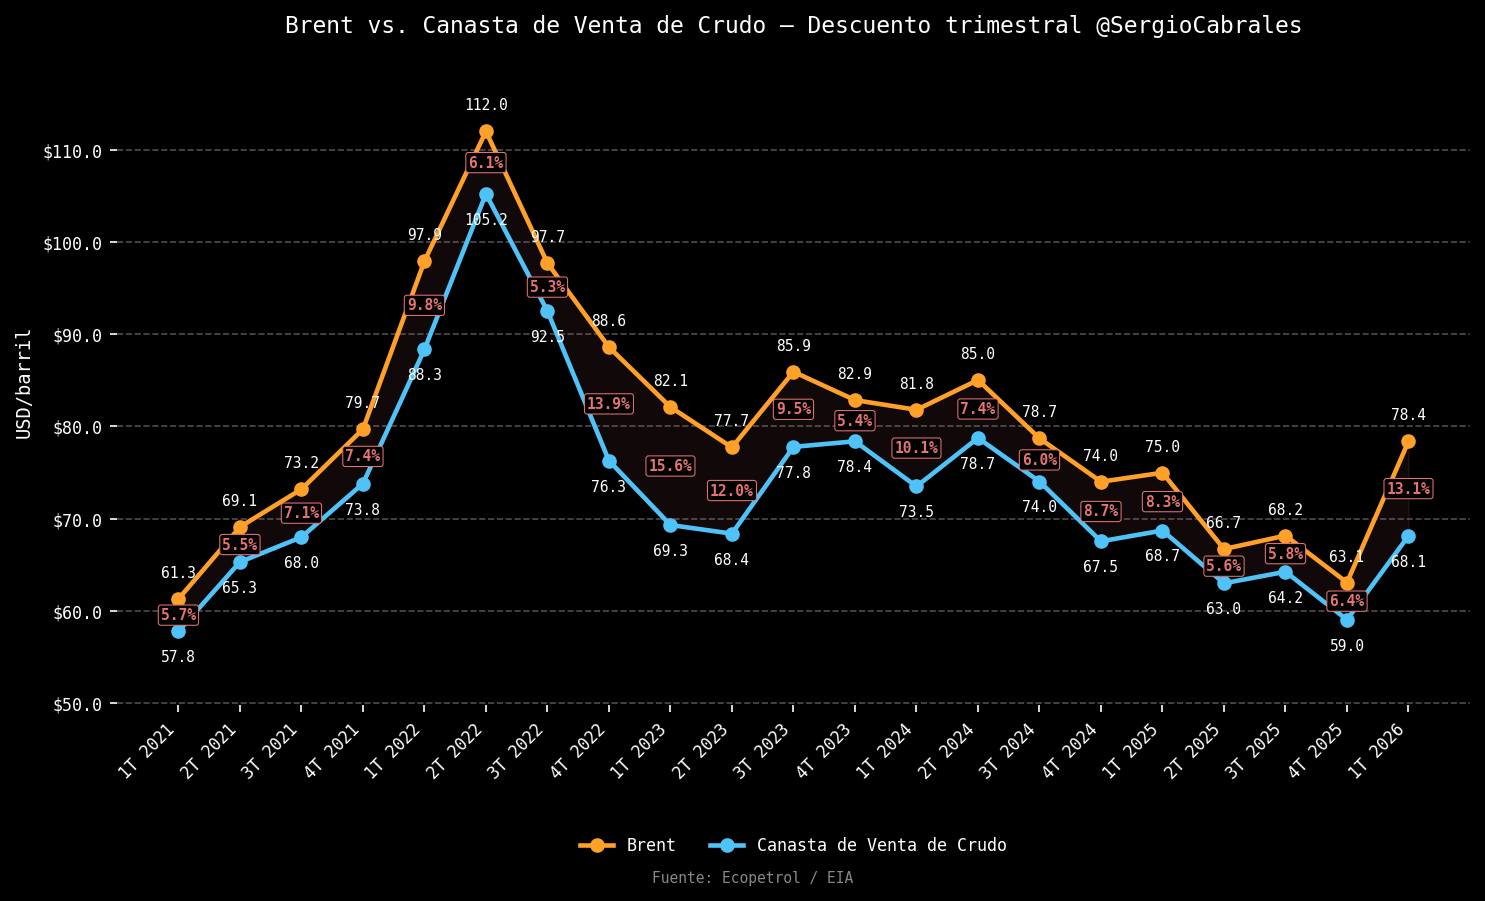

In [64]:
apply_bloomberg_theme()

# ---------- Datos ----------
periodos = [
#    "1T 2020", "2T 2020", "3T 2020", "4T 2020",
    "1T 2021", "2T 2021", "3T 2021", "4T 2021",
    "1T 2022", "2T 2022", "3T 2022", "4T 2022",
    "1T 2023", "2T 2023", "3T 2023", "4T 2023",
    "1T 2024", "2T 2024", "3T 2024", "4T 2024",
    "1T 2025", "2T 2025", "3T 2025", "4T 2025",
    "1T 2026"
]

brent = leer_serie("Precios - Prices", "Brent", periodos)
canasta = leer_serie("Precios - Prices", "Canasta de Venta de Crudo", periodos)

df = pd.DataFrame({
    "Periodo": periodos,
    "Brent": brent,
    "Canasta": canasta,
})
df["Descuento (%)"] = (1 - df["Canasta"] / df["Brent"]) * 100
df["Mid"] = (df["Brent"] + df["Canasta"]) / 2

# ---------- Colores ----------
C_BRENT   = "#FFA028"   # Naranja Bloomberg
C_CANASTA = "#4FC3F7"   # Azul claro
C_DESC    = "#E57373"   # Rojo suave para descuento
C_WM      = "#888888"

# ---------- Figura ----------
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.6)

x = range(len(df))

ax.plot(x, df["Brent"],   marker="o", linewidth=2.2,
        color=C_BRENT,   label="Brent")
ax.plot(x, df["Canasta"], marker="o", linewidth=2.2,
        color=C_CANASTA, label="Canasta de Venta de Crudo")

# Banda sombreada entre ambas series
ax.fill_between(list(x), df["Brent"], df["Canasta"],
                color=C_DESC, alpha=0.08)

# Eje y formato
ax.set_ylabel("USD/barril", fontsize=9)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.1f}"))
ax.set_xticks(list(x))
ax.set_xticklabels(df["Periodo"], rotation=45, ha="right")

# Spines estilo Bloomberg
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# Etiquetas de precio (Brent arriba, Canasta abajo)
for i, y in enumerate(df["Brent"]):
    ax.text(i, y + 2, f"{y:.1f}", ha="center", va="bottom",
            fontsize=7, color="white")

for i, y in enumerate(df["Canasta"]):
    ax.text(i, y - 2, f"{y:.1f}", ha="center", va="top",
            fontsize=7, color="white")

# Etiqueta del descuento porcentual ENTRE las dos series
for i, (mid, d) in enumerate(zip(df["Mid"], df["Descuento (%)"])):
    ax.text(i, mid, f"{d:.1f}%", ha="center", va="center",
            fontsize=7, color=C_DESC, weight="bold",
            bbox=dict(boxstyle="round,pad=0.18",
                      facecolor="#000000",
                      edgecolor=C_DESC,
                      linewidth=0.5))

# Holgura vertical para que las etiquetas no se corten
y_min = min(df["Canasta"]) - 8
y_max = max(df["Brent"])   + 8
ax.set_ylim(y_min, y_max)

# Título con watermark
ax.set_title(
    "Brent vs. Canasta de Venta de Crudo — Descuento trimestral @SergioCabrales",
    fontsize=11, color="#FFFFFF", pad=12
)

# Leyenda
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=2, frameon=False)

# Fuente
fig.text(0.44, 0.01, "Fuente: Ecopetrol / EIA", fontsize=7, color=C_WM)

plt.tight_layout()
plt.show()

# Restaurar rcParams por defecto para que el tema oscuro no afecte a las siguientes celdas
mpl.rcParams.update(mpl.rcParamsDefault)

## Ingresos por Segmento

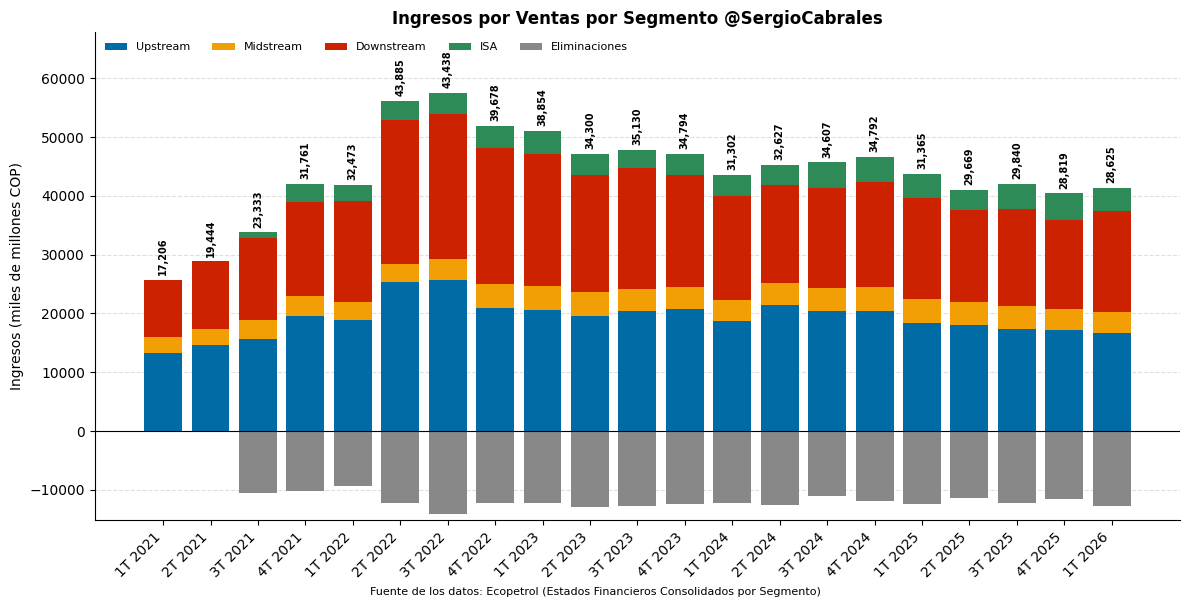

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Datos: Ingresos por ventas, por segmento (hoja "P&G Seg - P&L Seg")
# Nota: en Upstream/Midstream/Downstream la línea se llama "Ingresos por ventas";
# en ISA y Eliminaciones el mismo concepto aparece como "Total ingresos".
periodos_seg_ing = trimestres  # 1T 2021 ... 1T 2026

especificaciones_ingresos = {
    "Upstream": ("Miles de Millones (COP) - UPSTREAM", "Ingresos por ventas"),
    "Midstream": ("Miles de Millones (COP) - MIDSTREAM", "Ingresos por ventas"),
    "Downstream": ("Miles de Millones (COP) - DOWNSTREAM", "Ingresos por ventas"),
    "ISA": ("Miles de Millones (COP) - ISA", "Total ingresos"),
}

def a_float(v):
    """Convierte a float; '-' o vacío -> 0.0 (ej. ISA pre-adquisición)."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return 0.0

ingresos_por_segmento = {
    seg: np.array([a_float(v) for v in leer_serie_segmento(
        "P&G Seg - P&L Seg", header, etiqueta, periodos_seg_ing)])
    for seg, (header, etiqueta) in especificaciones_ingresos.items()
}

# Eliminaciones: la fila del archivo tiene datos corruptos (2T 2024 positivo;
# ceros en 4T 2025 y 1T 2026). Se deriva residualmente del Consolidado para
# garantizar coherencia: Eliminaciones = Consolidado - suma de segmentos.
ingresos_consolidado = np.array([a_float(v) for v in leer_serie_segmento(
    "P&G Seg - P&L Seg", "Miles de Millones (COP) - Consolidado",
    "Total ingresos", periodos_seg_ing)])

ingresos_por_segmento["Eliminaciones"] = (
    ingresos_consolidado - sum(ingresos_por_segmento.values())
)
ingresos_total_seg = ingresos_consolidado  # total neto de eliminaciones

# Barras apiladas con manejo de valores negativos (Eliminaciones remueve las
# ventas intercompañía y es negativo)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(periodos_seg_ing))
pos_bottom = np.zeros(len(periodos_seg_ing))
neg_bottom = np.zeros(len(periodos_seg_ing))
colores = ["#006BA4", "#F29F05", "#CC2200", "#2E8B57", "#888888"]

for (seg, valores), color in zip(ingresos_por_segmento.items(), colores):
    pos = np.where(valores > 0, valores, 0)
    neg = np.where(valores < 0, valores, 0)
    ax.bar(x, pos, bottom=pos_bottom, color=color, label=seg)
    ax.bar(x, neg, bottom=neg_bottom, color=color)
    pos_bottom += pos
    neg_bottom += neg

# Etiqueta del total consolidado sobre el tope de la pila positiva
for i, total in enumerate(ingresos_total_seg):
    # Only add text if total is a valid number
    if not np.isnan(total):
        ax.text(x[i], pos_bottom[i] + 800, f"{total:,.0f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold", rotation=90)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Ingresos por Ventas por Segmento @SergioCabrales", fontsize=12, weight="bold")
ax.set_ylabel("Ingresos (miles de millones COP)")
ax.set_xticks(x)
ax.set_xticklabels(periodos_seg_ing, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False, ncols=5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Calculate proposed y-limits
min_limit = neg_bottom.min() * 1.08
max_limit = pos_bottom.max() * 1.18

# Ensure there's a non-zero range if all data is zero, to prevent UserWarning
if np.isclose(min_limit, max_limit) and np.isclose(min_limit, 0):
    # Set a sensible default range for an empty plot
    ax.set_ylim(-5000, 10000)  # Example: Adjust these values based on expected data scale
else:
    ax.set_ylim(min_limit, max_limit)

plt.figtext(0.5, 0.0, "Fuente de los datos: Ecopetrol (Estados Financieros Consolidados por Segmento)",
            ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## Costo de Levantamiento

In [ ]:
apply_bloomberg_theme()

plt.figure(figsize=(10, 6))
bars = plt.bar(trimestres_ext, costo_levantamiento, color='darkgreen', alpha=0.6, width=0.4,
               label='Costo de Levantamiento Ecopetrol (USD/barril)')

# Último dato publicado por la EIA para el costo de levantamiento promedio
# mundial (Form EIA-28 / Financial Reporting System): esa serie se
# descontinuó tras 2009, año en que cayó a USD 11.51/boe. No existe una
# serie mundial trimestral comparable más reciente y con esta granularidad,
# así que se muestra como línea de referencia fija (no una serie por
# trimestre) y se deja explícito el año del dato en la etiqueta y la fuente.
COSTO_LEVANTAMIENTO_MUNDIAL_EIA = 11.51  # USD/boe, EIA FRS, dato 2009
plt.axhline(COSTO_LEVANTAMIENTO_MUNDIAL_EIA, color='#F29F05', linestyle='--', linewidth=2,
            label=f'Promedio Mundial reportado por la EIA ({COSTO_LEVANTAMIENTO_MUNDIAL_EIA:.2f} USD/boe, dato 2009)')

plt.title('Ecopetrol: Costo de Levantamiento vs. Promedio Mundial (EIA) @SergioCabrales')
plt.ylabel('USD/barril')
plt.xticks(rotation=45, ha='right')
plt.legend()
for rect, val in zip(bars, costo_levantamiento):
    plt.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.2, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
plt.figtext(0.5, 0.01,
            'Fuente: Ecopetrol https://www.ecopetrol.com.co/ | Promedio mundial: EIA, '
            'Performance Profiles of Major Energy Producers (lifting cost FRS mundial, '
            'último dato publicado: 2009)',
            ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Costo de levantamiento y Dilución

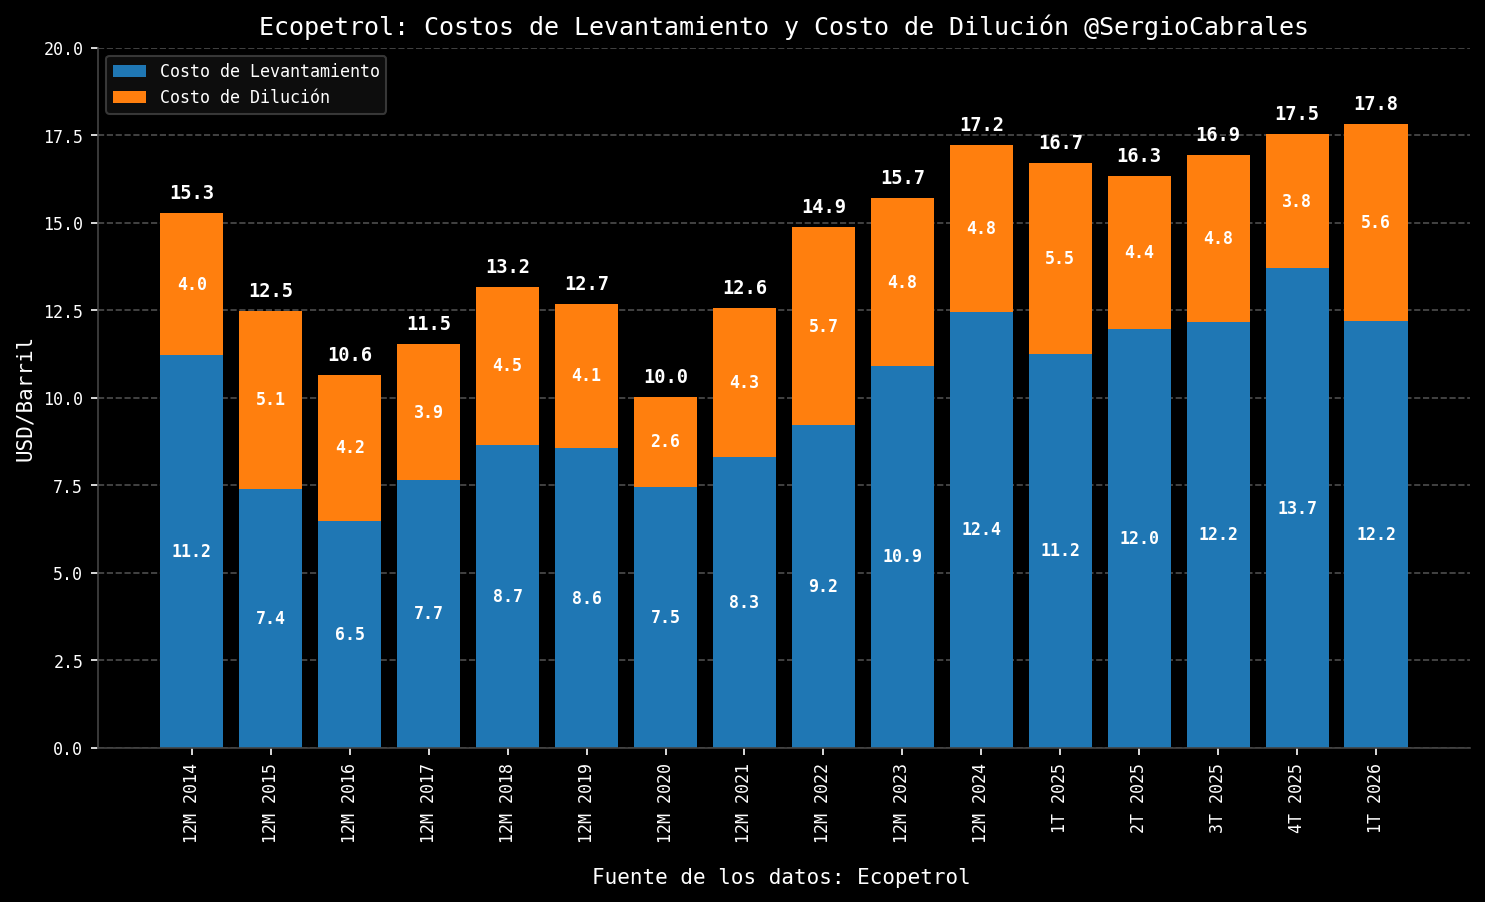

In [67]:
# Datos
periodos = [
    "12M 2014","12M 2015","12M 2016","12M 2017","12M 2018","12M 2019",
    "12M 2020","12M 2021","12M 2022","12M 2023","12M 2024",
    "1T 2025","2T 2025","3T 2025", "4T 2025",
    "1T 2026"
]

levantamiento = np.array(leer_serie("Financieros - Financials", "Costo de Levantamiento", periodos))
dilucion = np.array(leer_serie("Financieros - Financials", "Costo de Dilución", periodos))

totales = levantamiento + dilucion

# Figura
fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(periodos))

# Barras apiladas
bars_lev = ax.bar(x, levantamiento, label="Costo de Levantamiento")
bars_dil = ax.bar(x, dilucion, bottom=levantamiento, label="Costo de Dilución")

# Etiquetas centradas en cada segmento
for i in range(len(x)):
    ax.text(x[i], levantamiento[i]/2,
            f"{levantamiento[i]:.1f}",
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')

    ax.text(x[i], levantamiento[i] + dilucion[i]/2,
            f"{dilucion[i]:.1f}",
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')

    # Total en la parte superior
    ax.text(x[i], totales[i] + 0.3,
            f"{totales[i]:.1f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Formato
ax.set_xticks(x)
ax.set_xticklabels(periodos, rotation=90)
ax.set_ylabel("USD/Barril")
ax.set_title("Ecopetrol: Costos de Levantamiento y Costo de Dilución @SergioCabrales")
ax.legend()
ax.set_ylim(0,20)
# Apply Economist style by removing top and right spines
ax = plt.gca() # Get current axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add source text
plt.figtext(0.4, 0.01, "Fuente de los datos: Ecopetrol", ha="left", fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Margen EBITDA

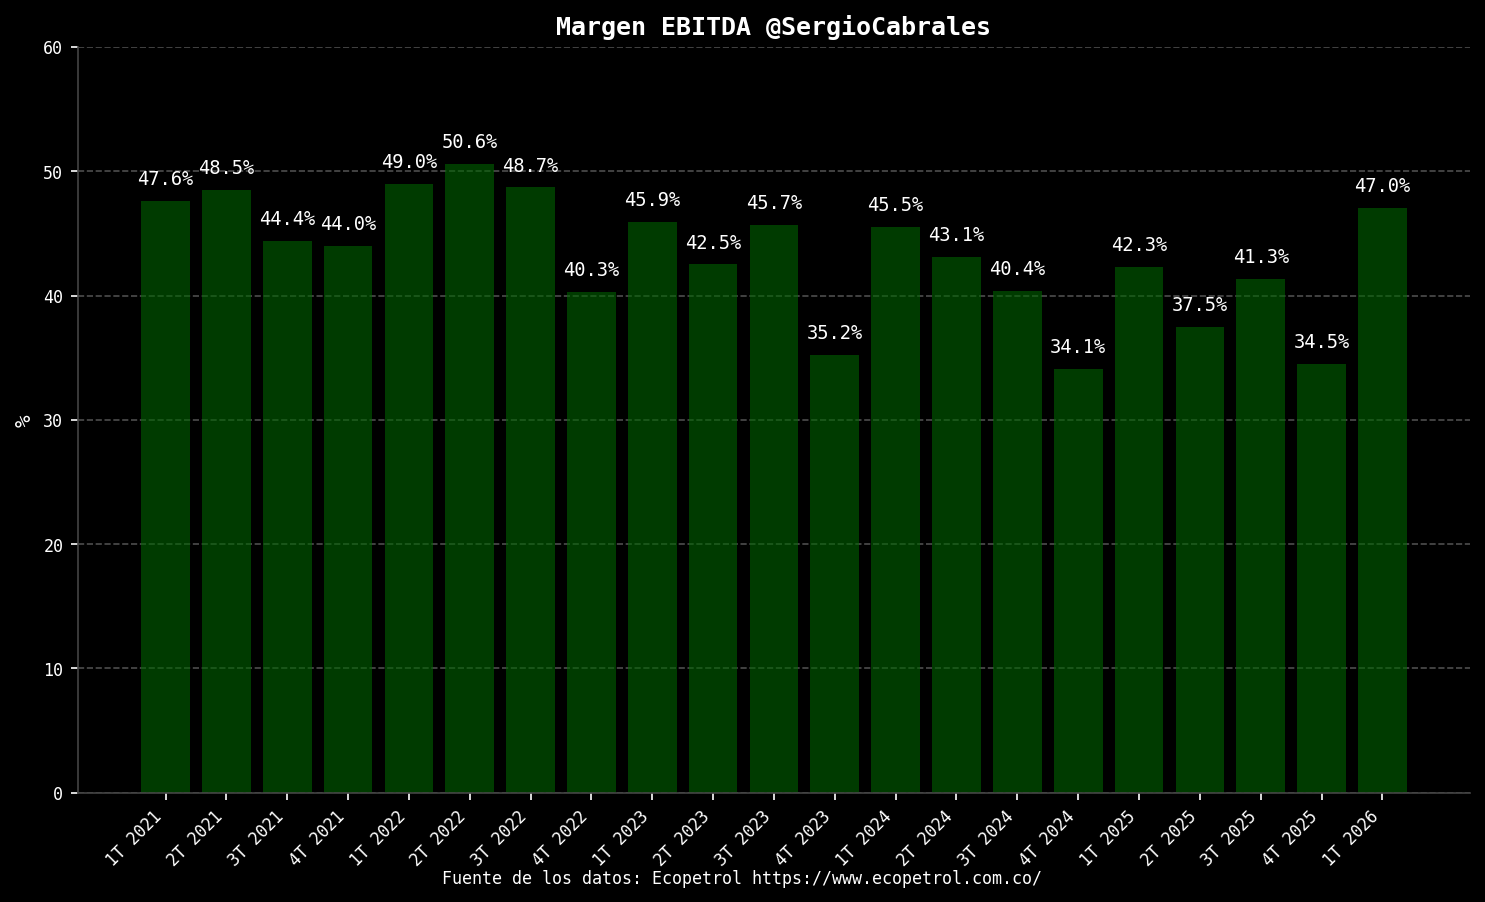

In [68]:
apply_bloomberg_theme()
plt.figure(figsize=(10, 6))
bars = plt.bar(trimestres_ext, margen_ebitda, color='darkgreen', alpha=0.6)
plt.ylim(0, 60)
plt.title("Margen EBITDA @SergioCabrales", loc='center', fontsize=12, weight='bold')
plt.ylabel("%")
plt.xticks(rotation=45, ha='right')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1, f"{round(yval, 1)}%", ha='center', va='bottom', fontsize=9)
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Margen EBITDA por Segmento

In [ ]:
# Clear caches to ensure fresh read of the excel file
_workbook.cache_clear()
_hoja.cache_clear()

# Datos: Margen EBITDA por segmento (hoja "P&G Seg - P&L Seg")
# Nota: "Eliminaciones" no se incluye porque no es un negocio real (es un ajuste
# contable) y su "margen" no tiene significado analítico.
periodos_margen_seg = trimestres  # 1T 2021 ... 1T 2026

segmentos_margen = {
    "Upstream": "Miles de Millones (COP) - UPSTREAM",
    "Midstream": "Miles de Millones (COP) - MIDSTREAM",
    "Downstream": "Miles de Millones (COP) - DOWNSTREAM",
    "ISA": "Miles de Millones (COP) - ISA",
#    "Consolidado": "Miles de Millones (COP) - Consolidado",
}

def a_pct(v):
    try:
        return float(v) * 100
    except (TypeError, ValueError):  # None, '-'
        return np.nan

margen_ebitda_seg = {
    seg: [a_pct(v) for v in leer_serie_segmento(
        "P&G Seg - P&L Seg", header, "Margen EBITDA", periodos_margen_seg)]
    for seg, header in segmentos_margen.items()
}

marcadores = ["o", "s", "^", "D", "x"]
colores = ["#006BA4", "#F29F05", "#CC2200", "#2E8B57", "#444444"]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(periodos_margen_seg))
for (seg, valores), marcador, color in zip(margen_ebitda_seg.items(), marcadores, colores):
    ax.plot(x, valores, marker=marcador, linestyle="--", color=color, label=seg)

ax.set_title("Margen EBITDA por Segmento @SergioCabrales", fontsize=12, weight="bold")
ax.set_ylabel("Margen EBITDA (%)")
ax.set_xticks(list(x))
ax.set_xticklabels(periodos_margen_seg, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.figtext(0.5, 0.0, "Fuente de los datos: Ecopetrol (Estados Financieros Consolidados por Segmento)",
            ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Margen EBITDA por segmento

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Datos: Margen EBITDA por segmento (hoja "P&G Seg - P&L Seg")
# Nota: "Eliminaciones" no se incluye porque no es un negocio real (es un ajuste
# contable) y su "margen" no tiene significado analítico.
periodos_margen_seg = trimestres  # 1T 2021 ... 1T 2026

segmentos_margen = {
    "Upstream": "Miles de Millones (COP) - UPSTREAM",
    "Midstream": "Miles de Millones (COP) - MIDSTREAM",
    "Downstream": "Miles de Millones (COP) - DOWNSTREAM",
    "ISA": "Miles de Millones (COP) - ISA",
#    "Consolidado": "Miles de Millones (COP) - Consolidado",
}

def a_pct(v):
    try:
        return float(v) * 100
    except (TypeError, ValueError):  # None, '-'
        return np.nan

margen_ebitda_seg = {
    seg: [a_pct(v) for v in leer_serie_segmento(
        "P&G Seg - P&L Seg", header, "Margen EBITDA", periodos_margen_seg
    )]
    for seg, header in segmentos_margen.items()
}

marcadores = ["o", "s", "^", "D", "x"]
colores = ["#006BA4", "#F29F05", "#CC2200", "#2E8B57", "#444444"]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(periodos_margen_seg))
for (seg, valores), marcador, color in zip(margen_ebitda_seg.items(), marcadores, colores):
    ax.plot(x, valores, marker=marcador, linestyle="--", color=color, label=seg)

ax.set_title("Margen EBITDA por Segmento @SergioCabrales", fontsize=12, weight="bold")
ax.set_ylabel("Margen EBITDA (%)")
ax.set_xticks(list(x))
ax.set_xticklabels(periodos_margen_seg, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.figtext(0.5, 0.0, "Fuente de los datos: Ecopetrol (Estados Financieros Consolidados por Segmento)",
            ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Evolución de la Utilidad Neta de Ecopetrol - Trimestral

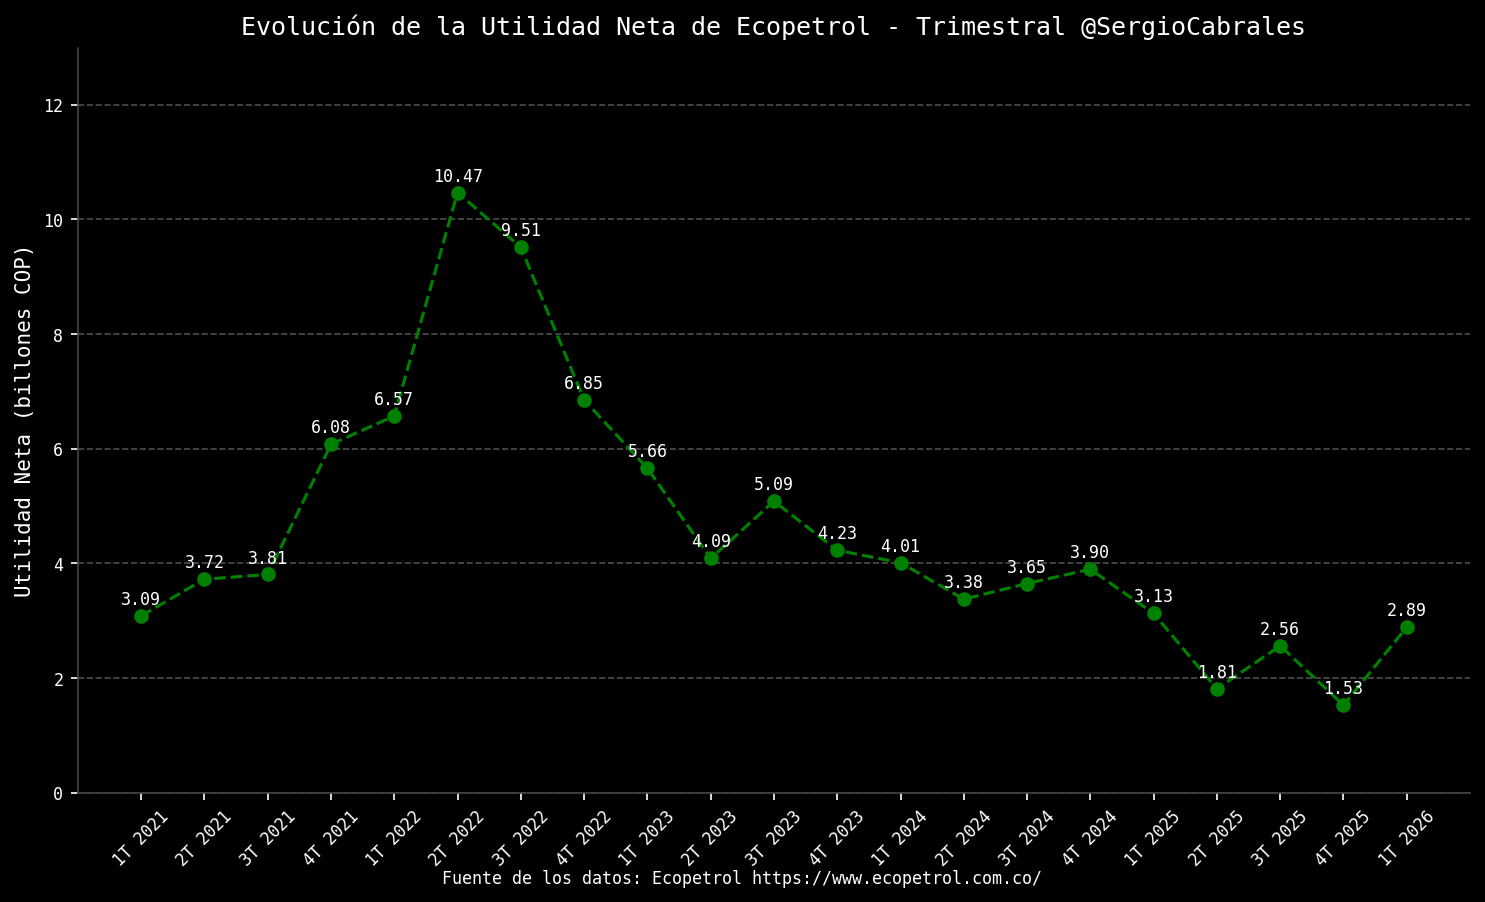

In [71]:
apply_bloomberg_theme()
plt.figure(figsize=(10, 6))
plt.plot(trimestres, np.array(utilidad_neta) / 1000, marker='o', linestyle='--', color='green')
plt.title('Evolución de la Utilidad Neta de Ecopetrol - Trimestral @SergioCabrales')
plt.ylabel('Utilidad Neta (billones COP)')
plt.xticks(rotation=45)
plt.ylim(0, 13)
for i, valor in enumerate(utilidad_neta):
    plt.text(i, valor / 1000 + 0.2, f"{valor / 1000:.2f}", ha='center', fontsize=8)
apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Evolución de la Utilidad Neta de Ecopetrol - Trimestral (Barras)

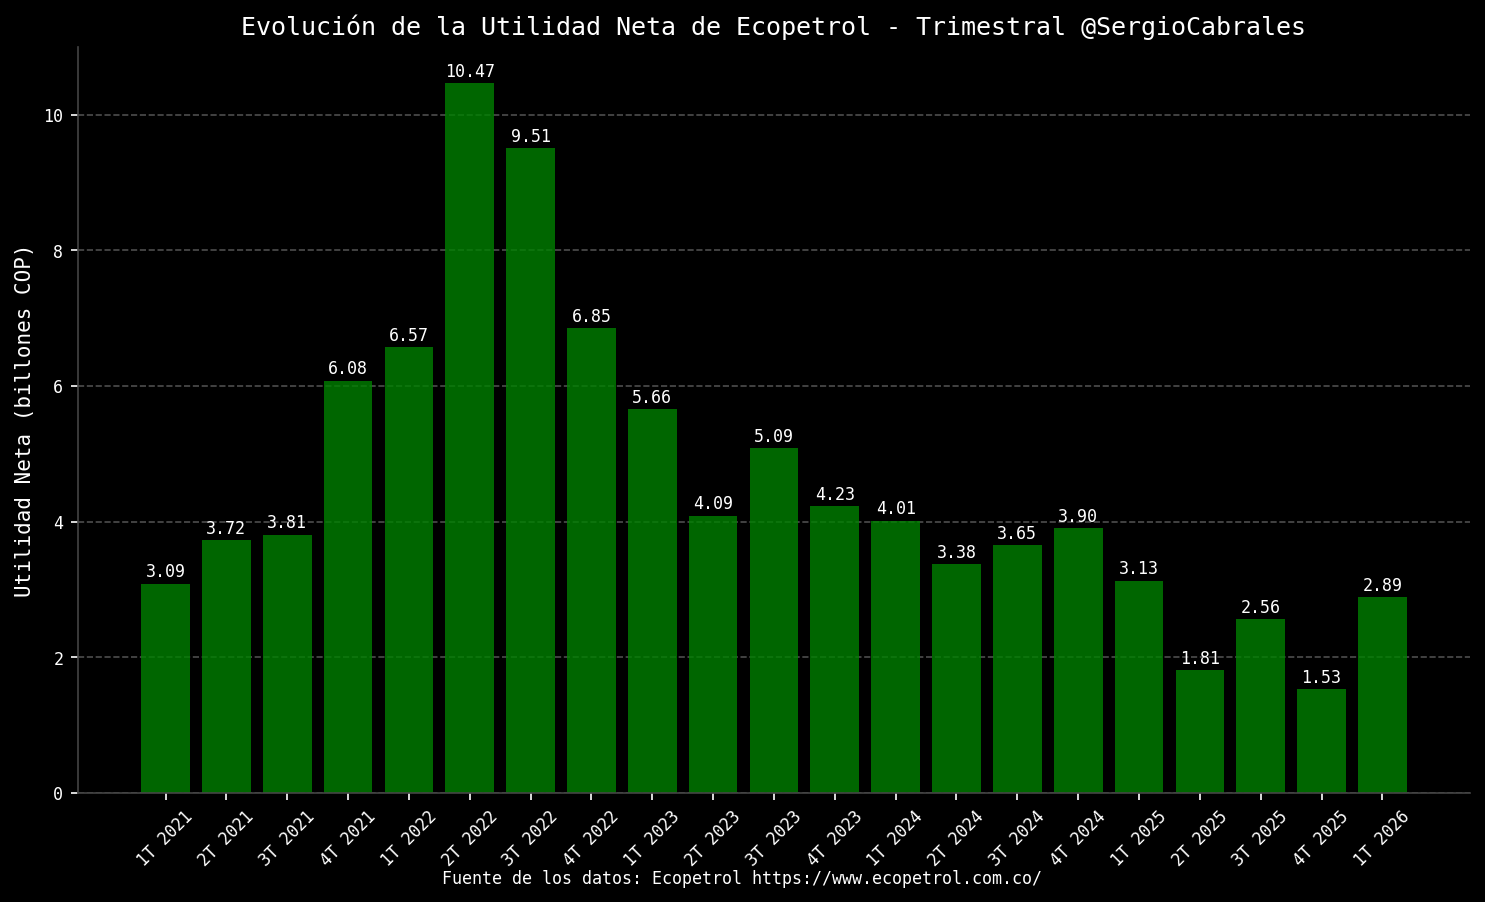

In [72]:
apply_bloomberg_theme()
# Crear gráfica de barras
plt.figure(figsize=(10,6))
plt.bar(trimestres, utilidad_neta_billones, color='green', alpha=0.8)

# Etiquetas y título
plt.title('Evolución de la Utilidad Neta de Ecopetrol - Trimestral @SergioCabrales')
plt.ylabel('Utilidad Neta (billones COP)')
#plt.xlabel('Trimestre')
plt.xticks(rotation=45)

# Valores encima de cada barra
for i, valor in enumerate(utilidad_neta_billones):
    plt.text(i, valor + 0.1, f"{valor:.2f}", ha='center', fontsize=8)
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')

plt.tight_layout()
plt.show()

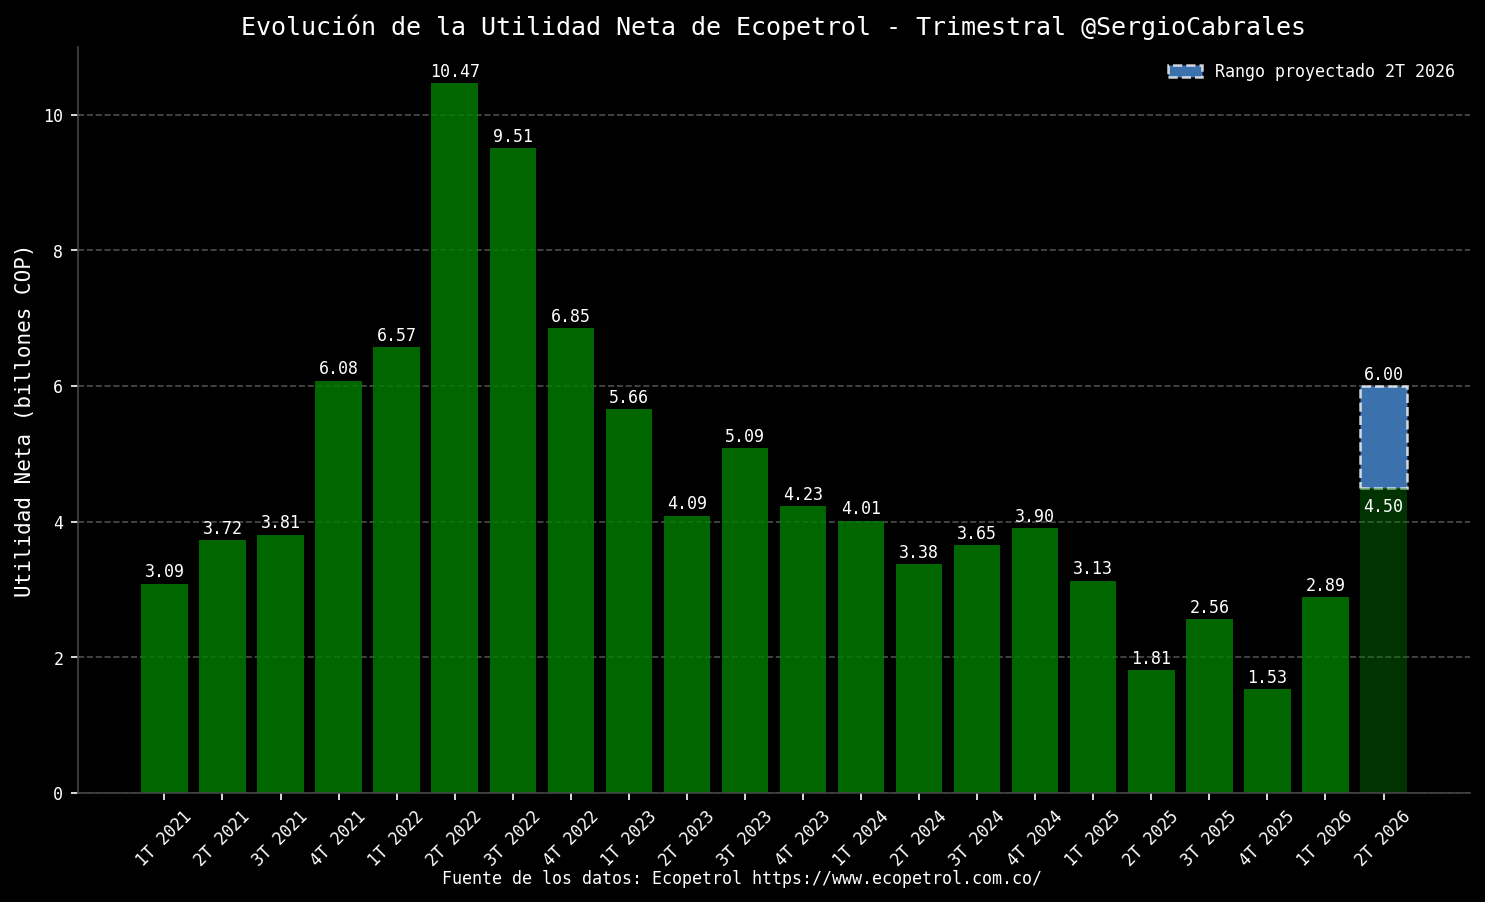

In [73]:
apply_bloomberg_theme()

# Rango proyectado 2T 2026
rango_min, rango_max = 4.5, 6.0

# Crear gráfica de barras
plt.figure(figsize=(10, 6))
plt.bar(trimestres, utilidad_neta_billones, color='green', alpha=0.8)

# Barra flotante azul para 2T 2026 (de 4.5 a 6.0) con borde discontinuo
plt.bar('2T 2026', rango_max - rango_min, bottom=rango_min,
        color='#4A90D9', alpha=0.8,
        edgecolor='white', linestyle='--', linewidth=1.2,
        label='Rango proyectado 2T 2026')

# Barra flotante azul para 2T 2026 (de 4.5 a 6.0) con borde discontinuo
plt.bar('2T 2026', rango_min, bottom=0,
        color='green', alpha=0.4)

# Etiquetas y título
plt.title('Evolución de la Utilidad Neta de Ecopetrol - Trimestral @SergioCabrales')
plt.ylabel('Utilidad Neta (billones COP)')
plt.xticks(rotation=45)

# Valores encima de cada barra histórica
for i, valor in enumerate(utilidad_neta_billones):
    plt.text(i, valor + 0.1, f"{valor:.2f}", ha='center', fontsize=8)

# Etiquetas del rango proyectado
n = len(trimestres)  # posición de la nueva barra
plt.text(n, rango_max + 0.1, f"{rango_max:.2f}", ha='center', fontsize=8)
plt.text(n, rango_min - 0.35, f"{rango_min:.2f}", ha='center', fontsize=8)

plt.legend(loc='upper right', fontsize=8, frameon=False)
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/',
            ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Utilidad neta por segmento

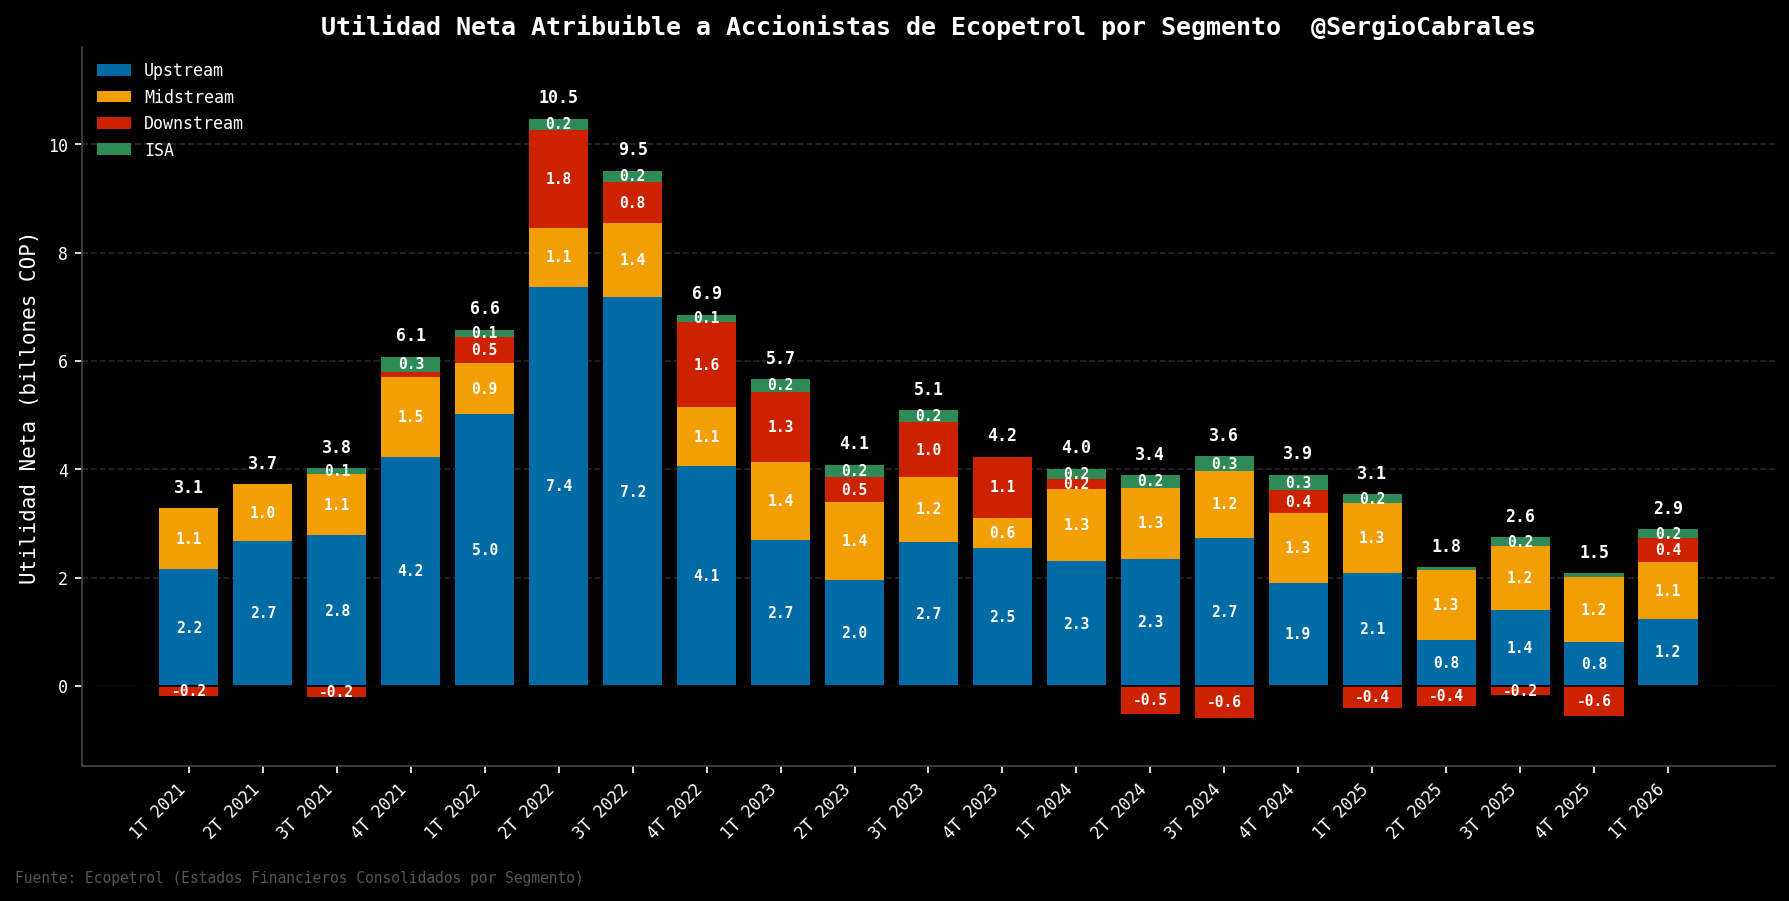

In [74]:
# Datos: Utilidad neta atribuible a accionistas de Ecopetrol, por segmento
# (hoja "P&G Seg - P&L Seg")
periodos_seg = trimestres  # 1T 2021 ... 1T 2026

headers_seg = {
    "Upstream": "Miles de Millones (COP) - UPSTREAM",
    "Midstream": "Miles de Millones (COP) - MIDSTREAM",
    "Downstream": "Miles de Millones (COP) - DOWNSTREAM",
    "ISA": "Miles de Millones (COP) - ISA",
#    "Eliminaciones": "Miles de Millones (COP) - Eliminaciones",
}

wb = openpyxl.load_workbook("excel-1t26-esp.xlsm", read_only=True, data_only=True)
ws = wb["P&G Seg - P&L Seg"]

MAX_COL = 60  # los datos reales terminan en la columna 59
filas = [[c.value for c in row] for row in ws.iter_rows(max_row=160, max_col=MAX_COL)]

def _leer_serie_segmento_from_filas(filas, encabezado, concepto, periodos):
    for i, f in enumerate(filas):
        # Asegurarse de que la fila tiene suficientes elementos antes de acceder al índice 1
        if len(f) > 1 and f[1] == encabezado:
            col_de = {str(v).strip(): j for j, v in enumerate(f) if v is not None}
            for f2 in filas[i + 1:]:
                v2 = f2[1]
                if isinstance(v2, str) and v2.startswith("Miles de Millones"):
                    break  # inicio del siguiente bloque
                if v2 == concepto:
                    return [f2.get if False else (f2[col_de[p]] if p in col_de else None)
                            for p in periodos]
    raise ValueError(f"No se encontró '{concepto}' bajo '{encabezado}'")

def a_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):  # None, '-', texto
        return 0.0

utilidad_por_segmento = {
    seg: np.array(
        [a_float(v) for v in _leer_serie_segmento_from_filas(
            filas, encabezado,
            "Utilidad neta atribuible a accionistas de Ecopetrol", periodos_seg)]
    ) / 1000.0 # Convert to billions COP
    for seg, encabezado in headers_seg.items()
}

utilidad_total_seg = np.sum(list(utilidad_por_segmento.values()), axis=0)

# Barras apiladas con manejo de valores negativos
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(periodos_seg))
# Initialize bottom positions for stacking
pos_bottom = np.zeros(len(periodos_seg))
neg_bottom = np.zeros(len(periodos_seg))
colores = ["#006BA4", "#F29F05", "#CC2200", "#2E8B57", "#888888"]

for (seg, valores), color in zip(utilidad_por_segmento.items(), colores):
    # Separate positive and negative values for current segment
    current_pos_values = np.clip(valores, 0, None)
    current_neg_values = np.clip(valores, None, 0)

    # Plot positive part of the bar
    bars_pos = ax.bar(x, current_pos_values, bottom=pos_bottom, color=color, label=seg)
    # Plot negative part of the bar
    bars_neg = ax.bar(x, current_neg_values, bottom=neg_bottom, color=color)

    # Add value labels for each segment
    for i in range(len(periodos_seg)):
        val_segment = valores[i]

        # Only display value if it's significant (e.g., >= 0.1 billion)
        if abs(val_segment) >= 0.1:
            label_text = f'{val_segment:.1f}'
            if val_segment > 0:
                text_y_pos = pos_bottom[i] + current_pos_values[i] / 2
                ax.text(x[i], text_y_pos, label_text,
                        ha="center", va="center", fontsize=7, color="white", fontweight="bold")
            elif val_segment < 0:
                text_y_pos = neg_bottom[i] + current_neg_values[i] / 2
                ax.text(x[i], text_y_pos, label_text,
                        ha="center", va="center", fontsize=7, color="white", fontweight="bold")

    # Update bottom positions for the next segment
    pos_bottom += current_pos_values
    neg_bottom += current_neg_values

# Offset proporcional al rango del eje Y (2 %)
y_min, y_max = neg_bottom.min(), pos_bottom.max()
offset = 0.02 * (y_max - y_min)
ax.set_ylim(y_min - 4 * offset, y_max + 6 * offset)

# Total labels on top/bottom of the bars
for i, total in enumerate(utilidad_total_seg):
    if total >= 0:
        # Position for positive total: above the stacked positive bars
        text_y_total = pos_bottom[i] + offset
        ax.text(x[i], text_y_total, f"{total:,.1f}", # Format to 1 decimal place for billions
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    else:
        # Position for negative total: below the stacked negative bars
        text_y_total = neg_bottom[i] - offset
        ax.text(x[i], text_y_total, f"{total:,.1f}", # Format to 1 decimal place for billions
                ha="center", va="top", fontsize=8, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(
    "Utilidad Neta Atribuible a Accionistas de Ecopetrol por Segmento  @SergioCabrales",
    fontsize=12, weight="bold",
)
ax.set_ylabel("Utilidad Neta (billones COP)") # Updated label
ax.set_xticks(x)
ax.set_xticklabels(periodos_seg, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
fig.text(0.01, 0.01,
         "Fuente: Ecopetrol (Estados Financieros Consolidados por Segmento)",
         fontsize=7, color="#555555")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Relación entre Utilidad Neta de Ecopetrol y Precio del Crudo Brent

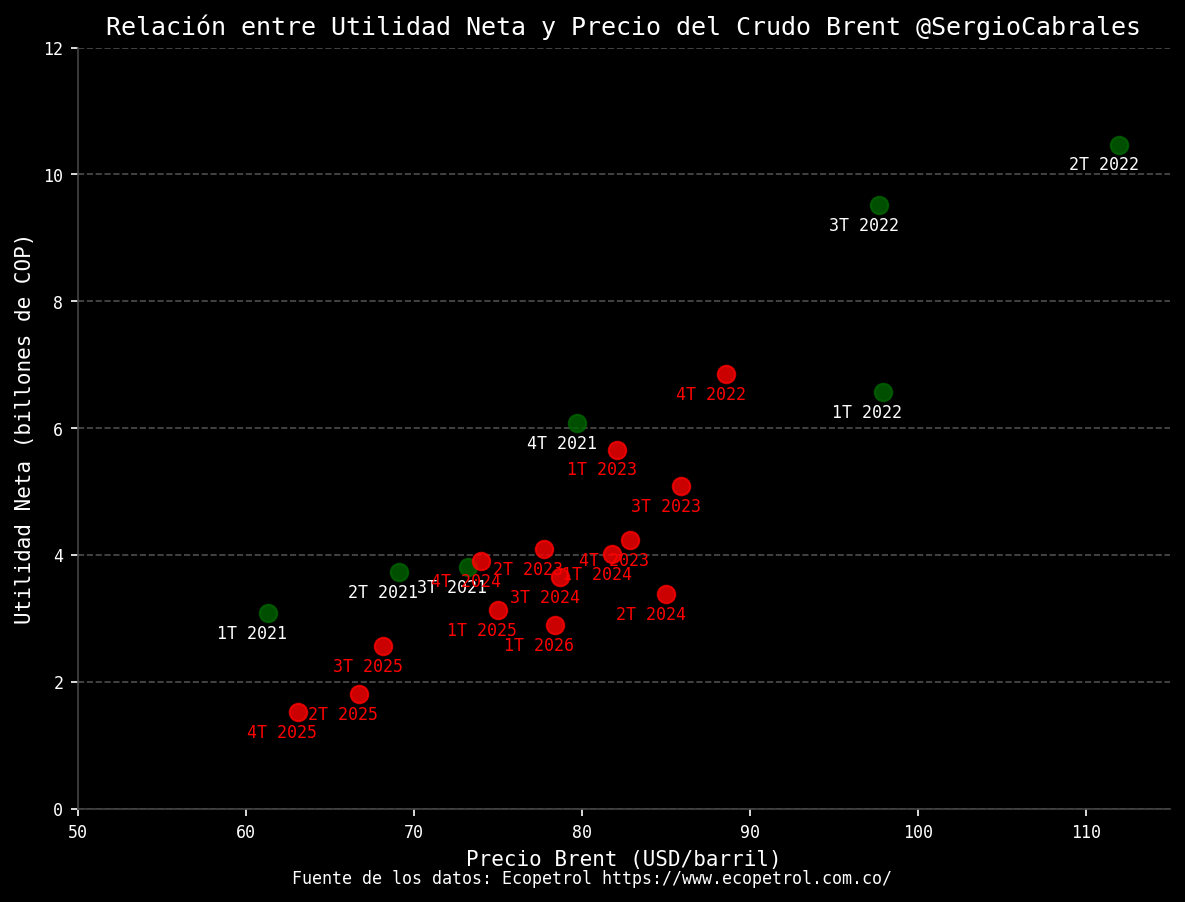

In [75]:
plt.figure(figsize=(8, 6))

# Find indices for the highlighting range
start_highlight_idx = trimestres.index("4T 2022")
end_highlight_idx = trimestres.index("1T 2026")

# Plot non-highlighted points
plt.scatter(precio_brent[:start_highlight_idx],
            utilidad_neta_billones[:start_highlight_idx],
            color='darkgreen', alpha=0.8, s=70)

# Plot highlighted points
plt.scatter(precio_brent[start_highlight_idx : end_highlight_idx + 1],
            utilidad_neta_billones[start_highlight_idx : end_highlight_idx + 1],
            color='red', alpha=0.8, s=70)

plt.title('Relación entre Utilidad Neta y Precio del Crudo Brent @SergioCabrales')
plt.xlabel('Precio Brent (USD/barril)')
plt.ylabel('Utilidad Neta (billones de COP)')
plt.ylim(0, 12)
plt.xlim(50, 115)

for i, trimestre in enumerate(trimestres):
    if start_highlight_idx <= i <= end_highlight_idx:
        text_color = 'red'
    else:
        # Default text color for the Bloomberg theme is white
        text_color = 'white'
    plt.text(precio_brent[i] - 3, utilidad_neta_billones[i] - 0.4, trimestre, fontsize=8, color=text_color)

apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

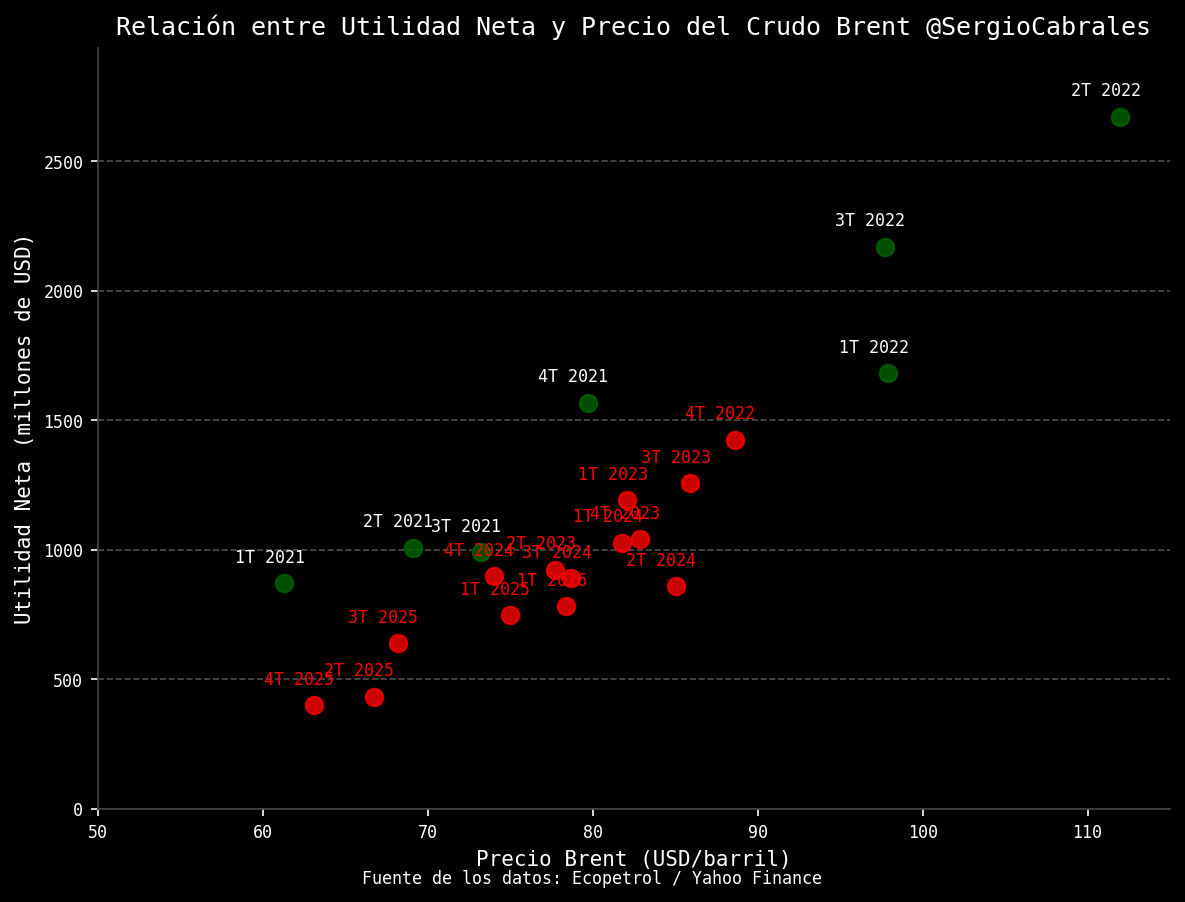

In [76]:
plt.figure(figsize=(8, 6))

# Find indices for the highlighting range
start_highlight_idx = trimestres.index("4T 2022")
end_highlight_idx = trimestres.index("1T 2026")

# Plot non-highlighted points
plt.scatter(precio_brent[:start_highlight_idx],
            utilidad_usd_millions[:start_highlight_idx],
            color='darkgreen', alpha=0.8, s=70)

# Plot highlighted points
plt.scatter(precio_brent[start_highlight_idx : end_highlight_idx + 1],
            utilidad_usd_millions[start_highlight_idx : end_highlight_idx + 1],
            color='red', alpha=0.8, s=70)

plt.title('Relación entre Utilidad Neta y Precio del Crudo Brent @SergioCabrales')
plt.xlabel('Precio Brent (USD/barril)')
plt.ylabel('Utilidad Neta (millones de USD)')
plt.ylim(0, max(utilidad_usd_millions) * 1.1) # Ajustar límite superior del eje Y
plt.xlim(50, 115)

for i, trimestre in enumerate(trimestres):
    if not np.isnan(utilidad_usd_millions[i]): # Solo anotar si el valor no es NaN
        if start_highlight_idx <= i <= end_highlight_idx:
            text_color = 'red'
        else:
            # Default text color for the Bloomberg theme is white
            text_color = 'white'
        plt.text(precio_brent[i] - 3, utilidad_usd_millions[i] + (0.03 * max(utilidad_usd_millions)), trimestre, fontsize=8, color=text_color)

apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol / Yahoo Finance', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Breakeven

In [77]:
# Últimos 3 datos del breakeven (según tu gráfica)
df = pd.DataFrame({
    "Periodo": ["2021","2022","2023", "2024", "2025"],
    "Breakeven_Utilidad_Neta_USD_bl": [34, 31, 41, 49, 52]
})

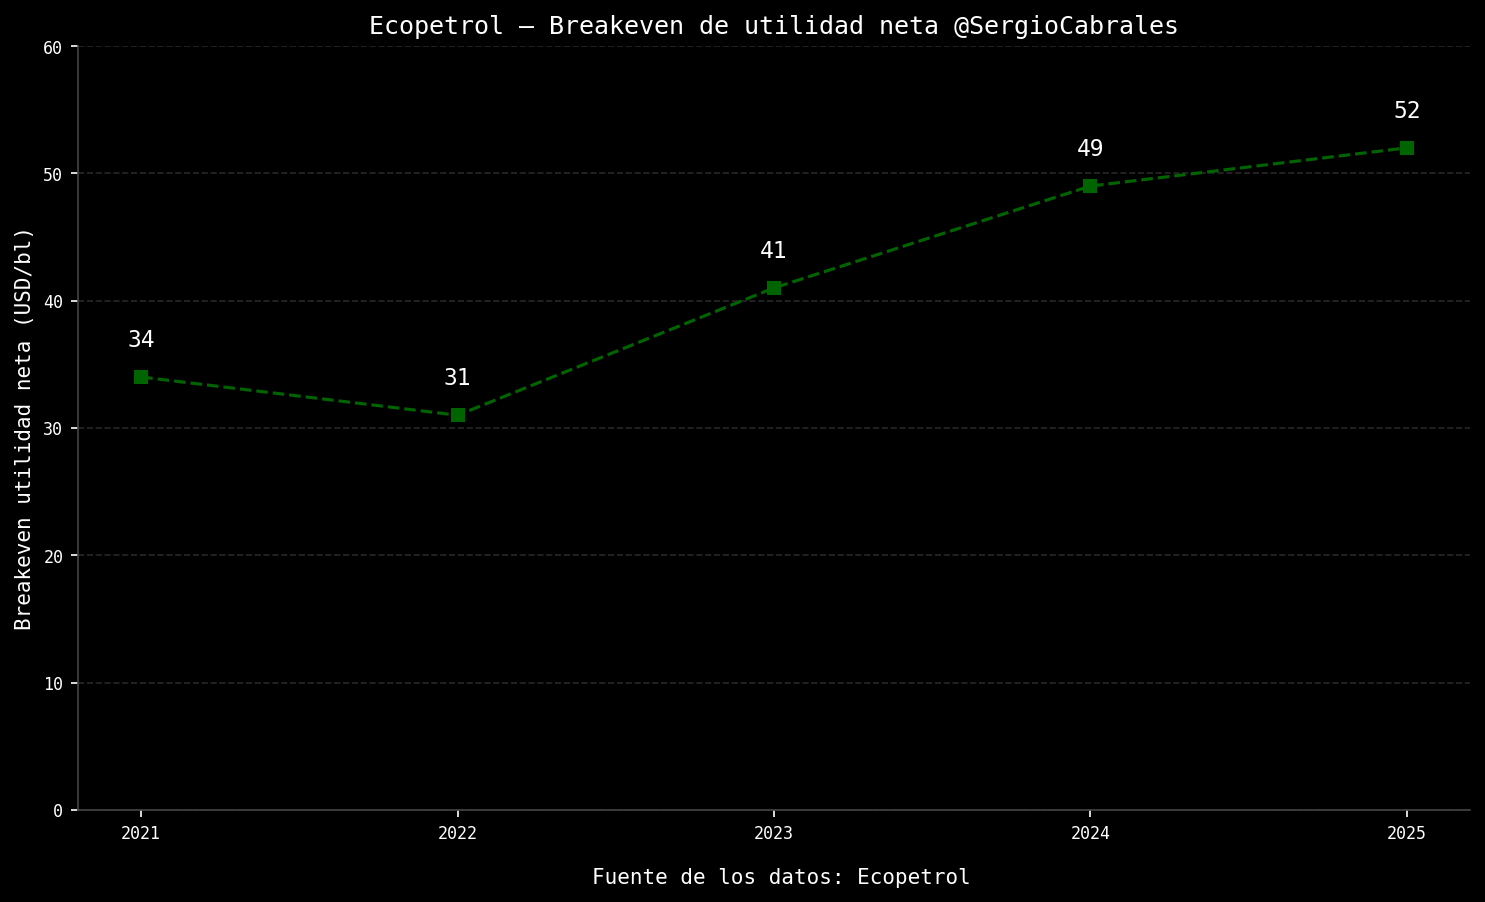

In [78]:
from matplotlib.lines import lineStyles
from matplotlib import color_sequences
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df["Periodo"], df["Breakeven_Utilidad_Neta_USD_bl"], marker="s", color='darkgreen', linestyle="--")
plt.ylabel("Breakeven utilidad neta (USD/bl)")
plt.xlabel("")
plt.title("Ecopetrol – Breakeven de utilidad neta @SergioCabrales")
plt.grid(True, axis="y", alpha=0.3)

# Set y-axis limits
plt.ylim(0, 60)

# Add values to points
for x, y in zip(df["Periodo"], df["Breakeven_Utilidad_Neta_USD_bl"]):
    plt.text(x, y + 2, str(y), ha='center', va='bottom', fontsize=11)

# Apply Economist style by removing top and right spines
ax = plt.gca() # Get current axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add source text
plt.figtext(0.4, 0.01, "Fuente de los datos: Ecopetrol", ha="left", fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Relación entre Utilidad Neta de Ecopetrol y Precio del Crudo Brent

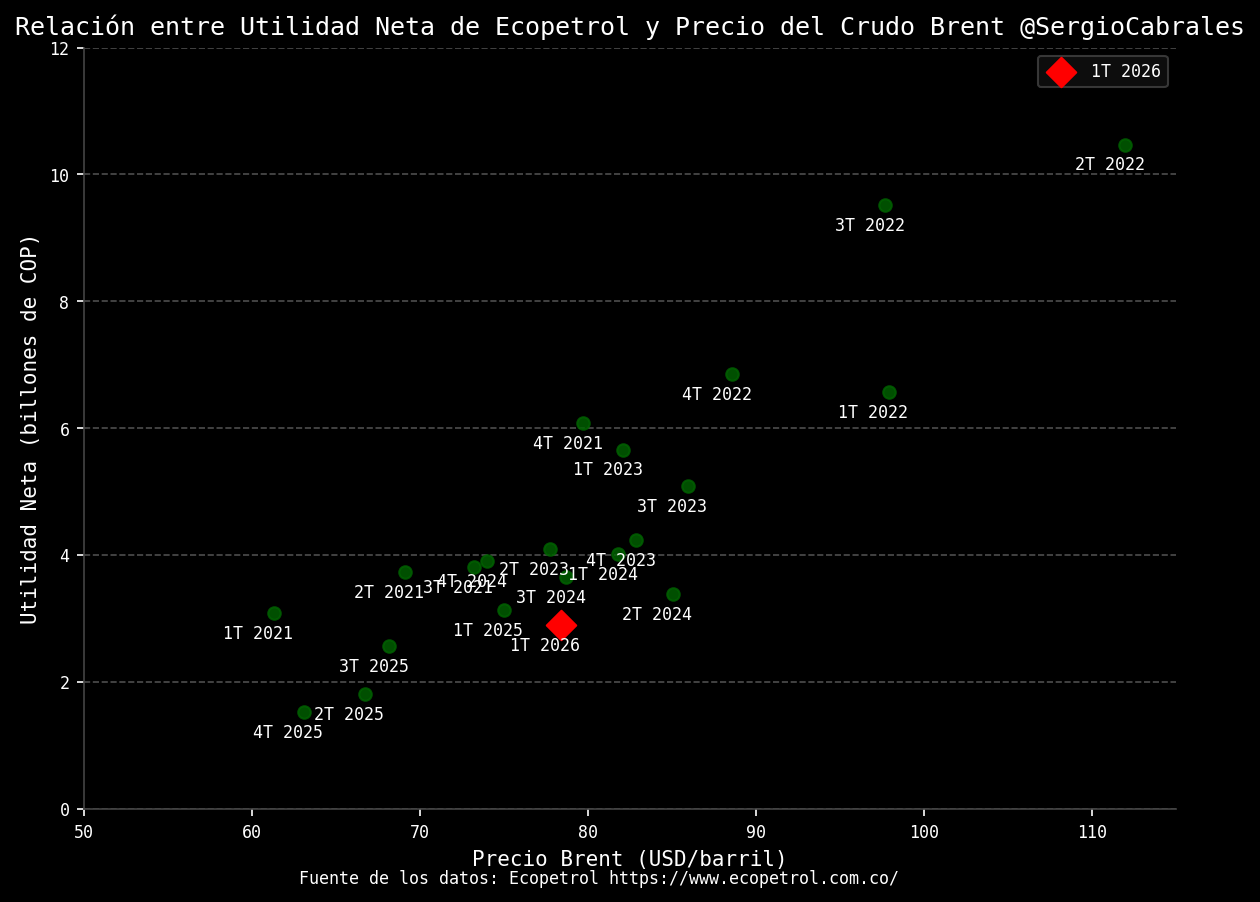

In [79]:
# Crear gráfico de dispersión con eje Y ajustado de 0 a 12
plt.figure(figsize=(8,6))

# Graficar todos los puntos en azul
plt.scatter(precio_brent, utilidad_neta_billones, color='darkgreen', alpha=0.8)

# Resaltar el punto de 2T 2025 (último valor) en rojo con marcador diferente
plt.scatter(precio_brent[-1], utilidad_neta_billones[-1], color='red', marker='D', s=100, label='1T 2026')

# Etiquetas y título
plt.title('Relación entre Utilidad Neta de Ecopetrol y Precio del Crudo Brent @SergioCabrales')
plt.xlabel('Precio Brent (USD/barril)')
plt.ylabel('Utilidad Neta (billones de COP)')
plt.xlim(50, 115)  # Limitar eje X
plt.ylim(0, 12)  # Limitar eje Y


# Anotar todos los trimestres
for i, trimestre in enumerate(trimestres):
    plt.text(precio_brent[i] - 3, utilidad_neta_billones[i] - 0.4, trimestre, fontsize=8)

apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.legend()
plt.tight_layout()
plt.show()

## Frontera eficiente: Utilidad neta

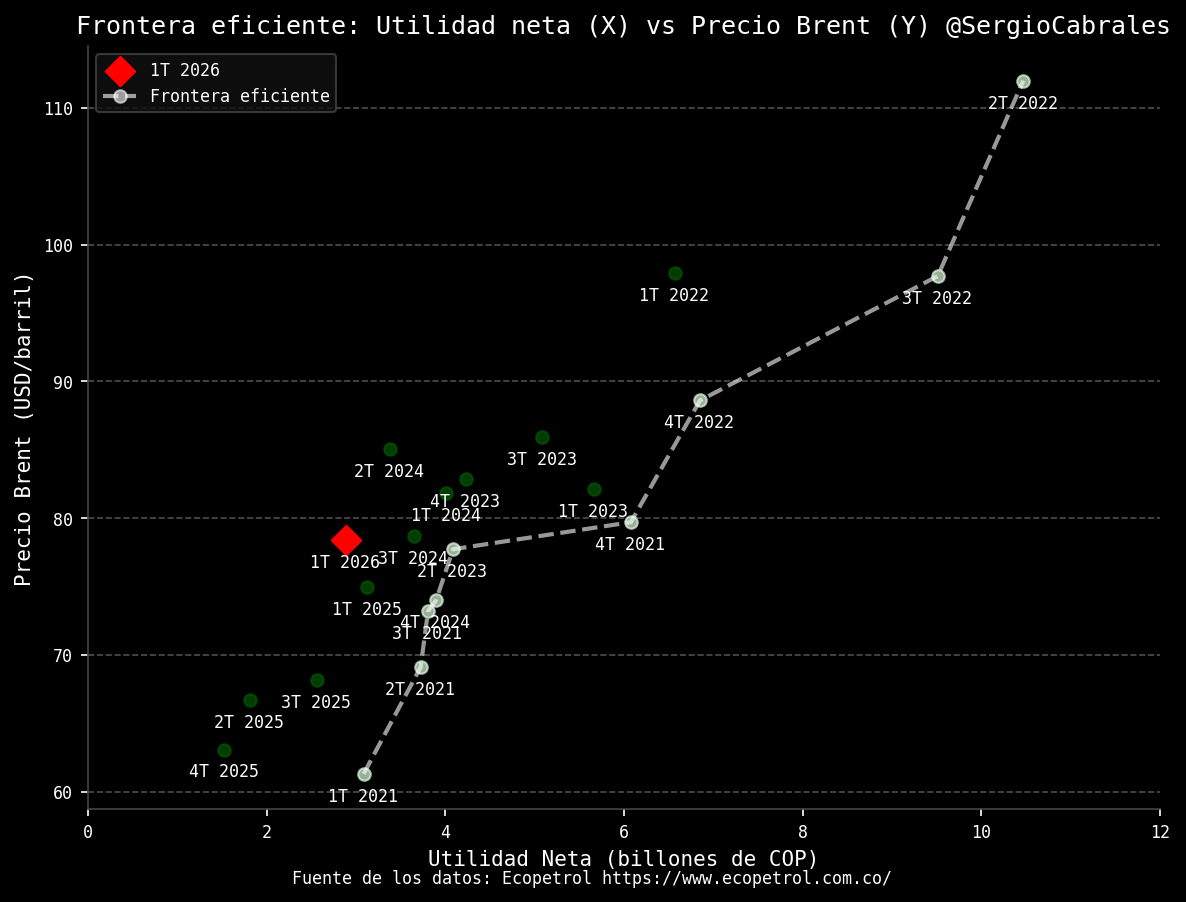

In [80]:
indices_orden = sorted(range(len(utilidad_neta_billones)), key=lambda i: utilidad_neta_billones[i], reverse=True)
frontera_idx = []
min_y = float('inf')
for i in indices_orden:
    if precio_brent[i] <= min_y:
        frontera_idx.append(i)
        min_y = precio_brent[i]
frontera_idx = sorted(frontera_idx, key=lambda i: utilidad_neta_billones[i])
fx = [utilidad_neta_billones[i] for i in frontera_idx]
fy = [precio_brent[i] for i in frontera_idx]

plt.figure(figsize=(8, 6))
plt.scatter(utilidad_neta_billones, precio_brent, color='darkgreen', alpha=0.6)
i_last = len(trimestres) - 1
plt.scatter(utilidad_neta_billones[i_last], precio_brent[i_last], marker='D', s=100, color='red', label='1T 2026')
plt.plot(fx, fy, marker='o', linestyle="--", linewidth=2, label='Frontera eficiente', alpha=0.6, color='white')
plt.title('Frontera eficiente: Utilidad neta (X) vs Precio Brent (Y) @SergioCabrales')
plt.xlabel('Utilidad Neta (billones de COP)')
plt.ylabel('Precio Brent (USD/barril)')
plt.xlim(0, 12)
for i, trimestre in enumerate(trimestres):
    plt.text(utilidad_neta_billones[i] - 0.4, precio_brent[i] - 2, trimestre, fontsize=8)
apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.legend()
plt.tight_layout()
plt.show()

## Frontera eficiente: Precio Brent

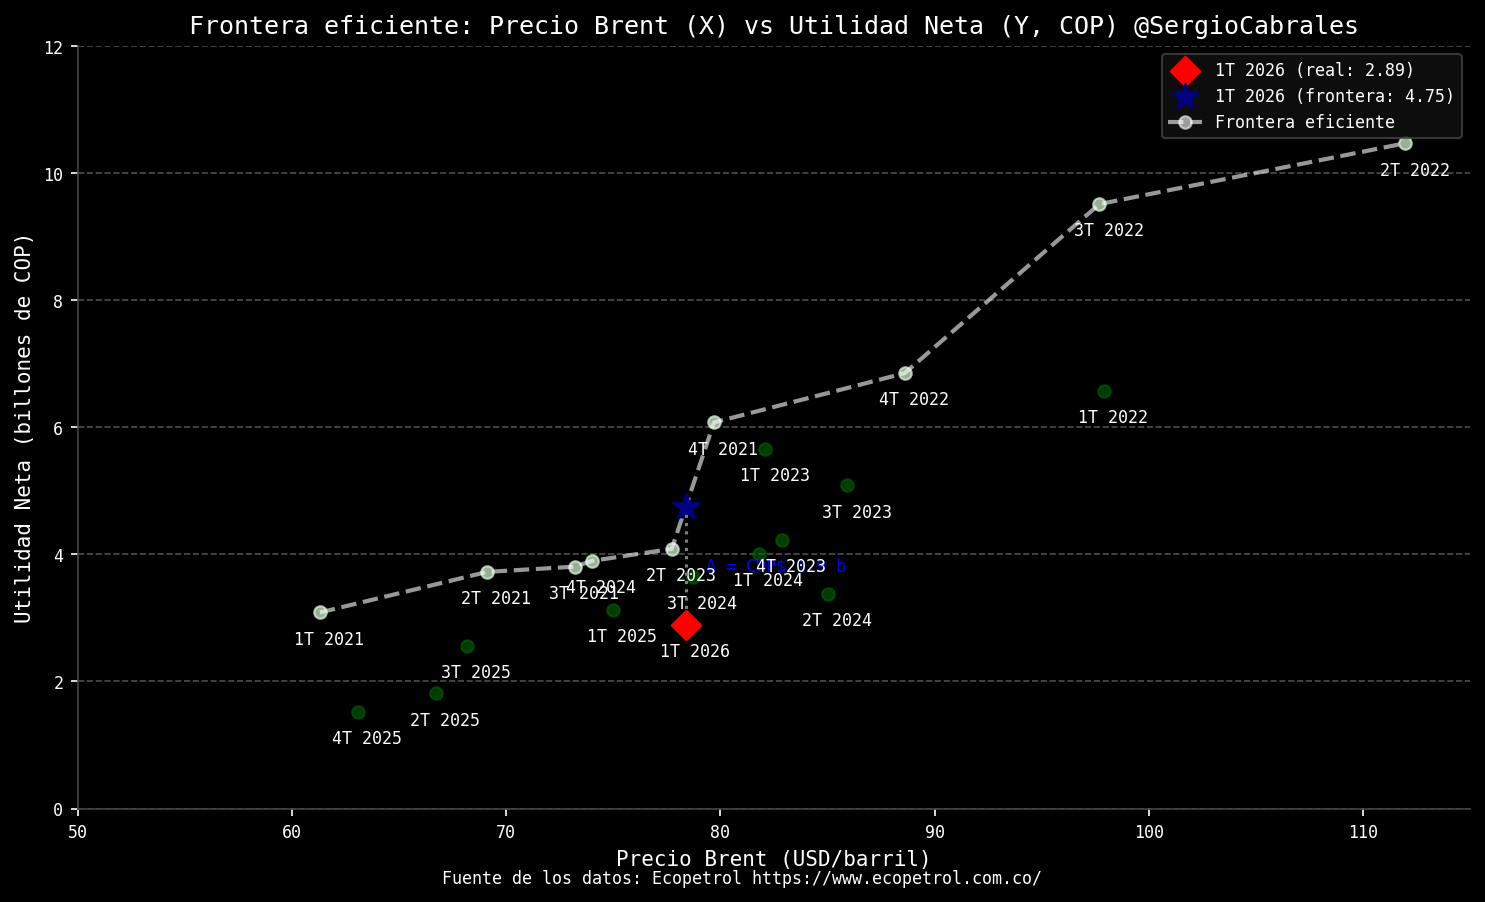

In [81]:
indices_orden = sorted(range(len(utilidad_neta_billones)), key=lambda i: utilidad_neta_billones[i], reverse=True)
frontera_idx = []
min_y = float('inf')
for i in indices_orden:
    if precio_brent[i] <= min_y:
        frontera_idx.append(i)
        min_y = precio_brent[i]
frontera_idx = sorted(frontera_idx, key=lambda i: utilidad_neta_billones[i])
fx = [precio_brent[i] for i in frontera_idx]
fy = [utilidad_neta_billones[i] for i in frontera_idx]
frontier_sorted = sorted(zip(fx, fy), key=lambda p: p[0])
fx_s = [p[0] for p in frontier_sorted]
fy_s = [p[1] for p in frontier_sorted]
i_last = len(trimestres) - 1
x_4t = precio_brent[i_last]
y_4t_actual = utilidad_neta_billones[i_last]
y_4t_frontera = np.interp(x_4t, fx_s, fy_s)

plt.figure(figsize=(10, 6))
plt.scatter(precio_brent, utilidad_neta_billones, color='darkgreen', alpha=0.6)
plt.scatter(x_4t, y_4t_actual, marker='D', s=100, color='red', zorder=5, label=f'1T 2026 (real: {y_4t_actual:.2f})')
plt.scatter(x_4t, y_4t_frontera, marker='*', s=180, color='navy', zorder=5, label=f'1T 2026 (frontera: {y_4t_frontera:.2f})')
plt.plot([x_4t, x_4t], [y_4t_actual, y_4t_frontera], linestyle=':', color='gray', linewidth=1.5, zorder=4)
mid_y = (y_4t_actual + y_4t_frontera) / 2
plt.annotate(f'  Δ = COP$ {y_4t_frontera - y_4t_actual:.1f} b', xy=(x_4t, mid_y), fontsize=8, color='blue', va='center')
plt.plot(fx, fy, marker='o', linestyle='--', linewidth=2, label='Frontera eficiente', alpha=0.6, color='white')
plt.title('Frontera eficiente: Precio Brent (X) vs Utilidad Neta (Y, COP) @SergioCabrales')
plt.xlabel('Precio Brent (USD/barril)')
plt.ylabel('Utilidad Neta (billones de COP)')
plt.xlim(50, 115)
plt.ylim(0, 12)
for i, t in enumerate(trimestres):
    plt.text(precio_brent[i] - 1.2, utilidad_neta_billones[i] - 0.5, t, fontsize=8)
apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.legend()
plt.tight_layout()
plt.show()

## Frontera eficiente - USD

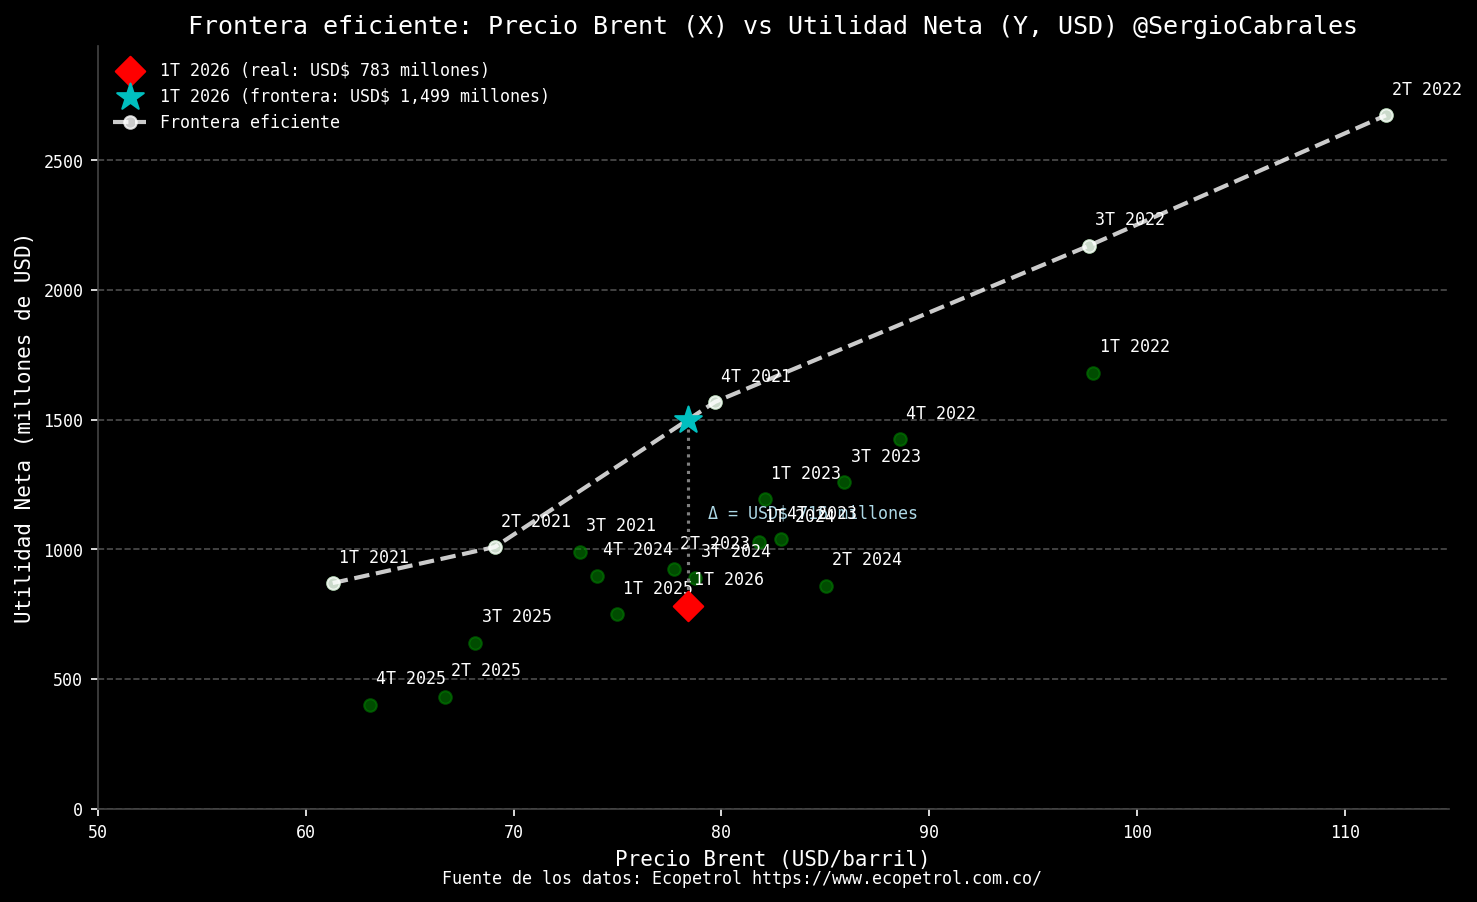

In [82]:
indices_orden = sorted(range(len(utilidad_usd_millions)), key=lambda i: utilidad_usd_millions[i] if not np.isnan(utilidad_usd_millions[i]) else -np.inf, reverse=True)
frontera_idx = []
min_x = float('inf')
for i in indices_orden:
    if precio_brent[i] <= min_x:
        frontera_idx.append(i)
        min_x = precio_brent[i]
frontera_idx = sorted(frontera_idx, key=lambda i: precio_brent[i])
fx = [precio_brent[i] for i in frontera_idx]
fy = [utilidad_usd_millions[i] for i in frontera_idx]
i_last = len(trimestres) - 1
x_4t = precio_brent[i_last]
y_4t_actual = utilidad_usd_millions[i_last]
y_4t_frontera = np.interp(x_4t, fx, fy)

plt.figure(figsize=(10, 6))
plt.scatter(precio_brent, utilidad_usd_millions, color='green', alpha=0.6)
plt.scatter(x_4t, y_4t_actual, marker='D', s=100, color='red', zorder=5,
            label=f'1T 2026 (real: USD$ {y_4t_actual:,.0f} millones)')
plt.scatter(x_4t, y_4t_frontera, marker='*', s=180, color='c', zorder=5,
            label=f'1T 2026 (frontera: USD$ {y_4t_frontera:,.0f} millones)')
plt.plot([x_4t, x_4t], [y_4t_actual, y_4t_frontera], linestyle=':', color='gray', linewidth=1.5, zorder=4)
mid_y = (y_4t_actual + y_4t_frontera) / 2
plt.annotate(f'  Δ = USD$ {y_4t_frontera - y_4t_actual:,.0f} millones', xy=(x_4t, mid_y), fontsize=8, color='lightblue', va='center')
plt.plot(fx, fy, marker='o', linestyle='--', linewidth=2, label='Frontera eficiente', alpha=0.8, color='white')
plt.title('Frontera eficiente: Precio Brent (X) vs Utilidad Neta (Y, USD) @SergioCabrales')
plt.xlabel('Precio Brent (USD/barril)')
plt.ylabel('Utilidad Neta (millones de USD)')
plt.xlim(50, 115)
plt.ylim(0, max(utilidad_usd_millions) * 1.1)
for i, trimestre in enumerate(trimestres):
    # Ajustar la posición de la etiqueta si la utilidad es NaN
    if not np.isnan(utilidad_usd_millions[i]):
        plt.text(precio_brent[i] + 0.3, utilidad_usd_millions[i] + 0.03 * max(utilidad_usd_millions), trimestre, fontsize=8)
apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Precio Brent vs Utilidad Neta con producción

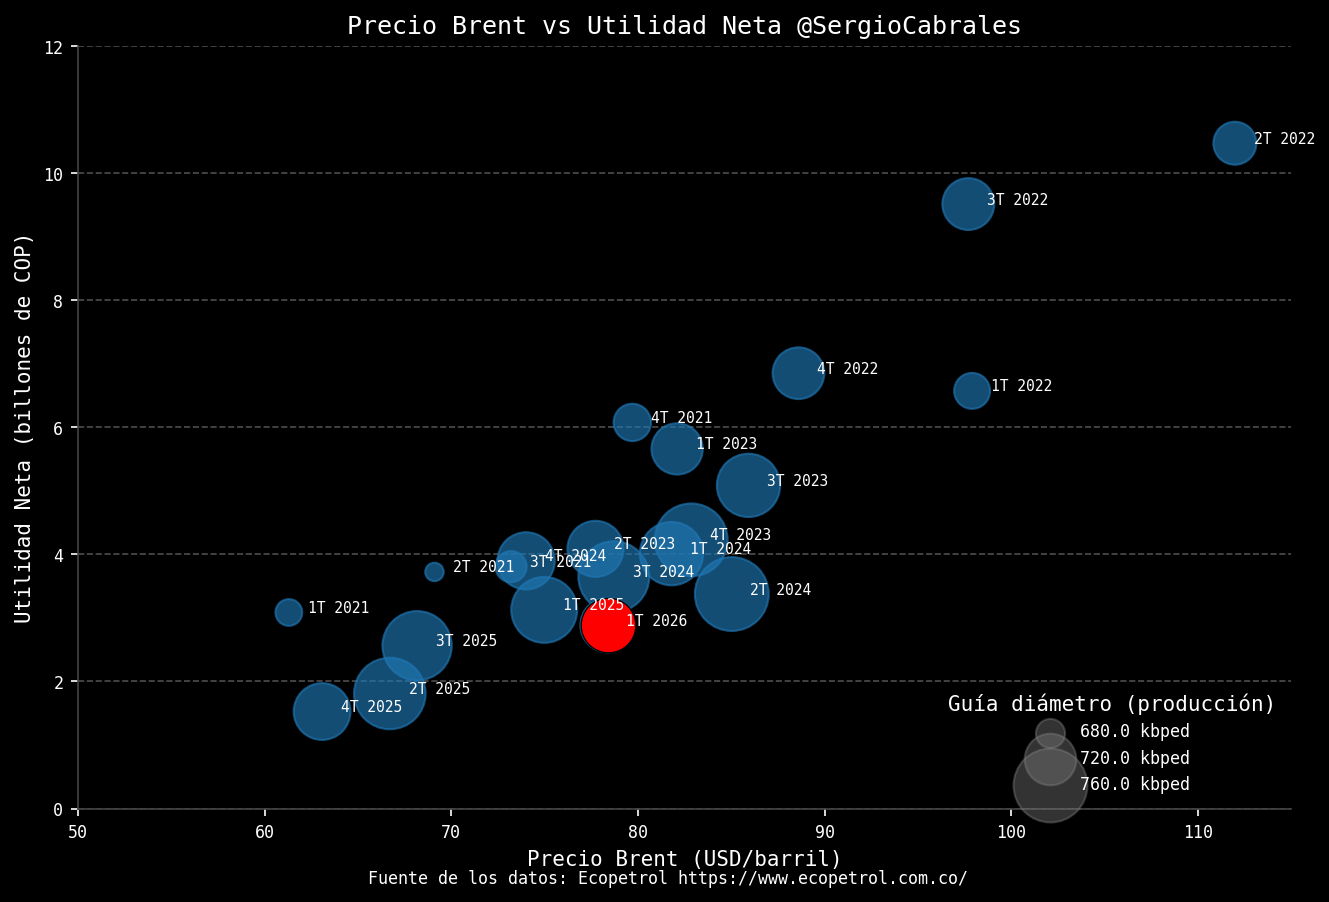

In [83]:
d_min, d_max = 10, 40
diametros_pts = np.interp(produccion, (min(produccion), max(produccion)), (d_min, d_max))
sizes = np.pi * (diametros_pts / 2) ** 2

plt.figure(figsize=(9, 6))
# Eje X: Precio Brent, Eje Y: Utilidad Neta
plt.scatter(precio_brent, utilidad_neta_billones, s=sizes, marker='o', alpha=0.65)
idx_special = len(trimestres) - 1
plt.scatter([precio_brent[idx_special]], [utilidad_neta_billones[idx_special]],
            s=[sizes[idx_special]], marker='o', color='red', edgecolor='black', linewidth=0.6, zorder=3)

plt.title('Precio Brent vs Utilidad Neta @SergioCabrales')
plt.xlabel('Precio Brent (USD/barril)')
plt.ylabel('Utilidad Neta (billones de COP)')
plt.xlim(50, 115)
plt.ylim(0, 12)

for i, tri in enumerate(trimestres):
    # Ajuste de posición del texto: desplazamiento pequeño en X
    plt.text(precio_brent[i] + 1, utilidad_neta_billones[i], tri, fontsize=7)

for ref in [680, 720, 760]:
    d_ref = np.interp(ref, (min(produccion), max(produccion)), (d_min, d_max))
    s_ref = np.pi * (d_ref / 2) ** 2
    plt.scatter([], [], s=s_ref, marker='o', label=f'{ref:.1f} kbped', color='gray', zorder=2, alpha=0.4)

plt.legend(title='Guía diámetro (producción)', loc='lower right', frameon=False)
apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

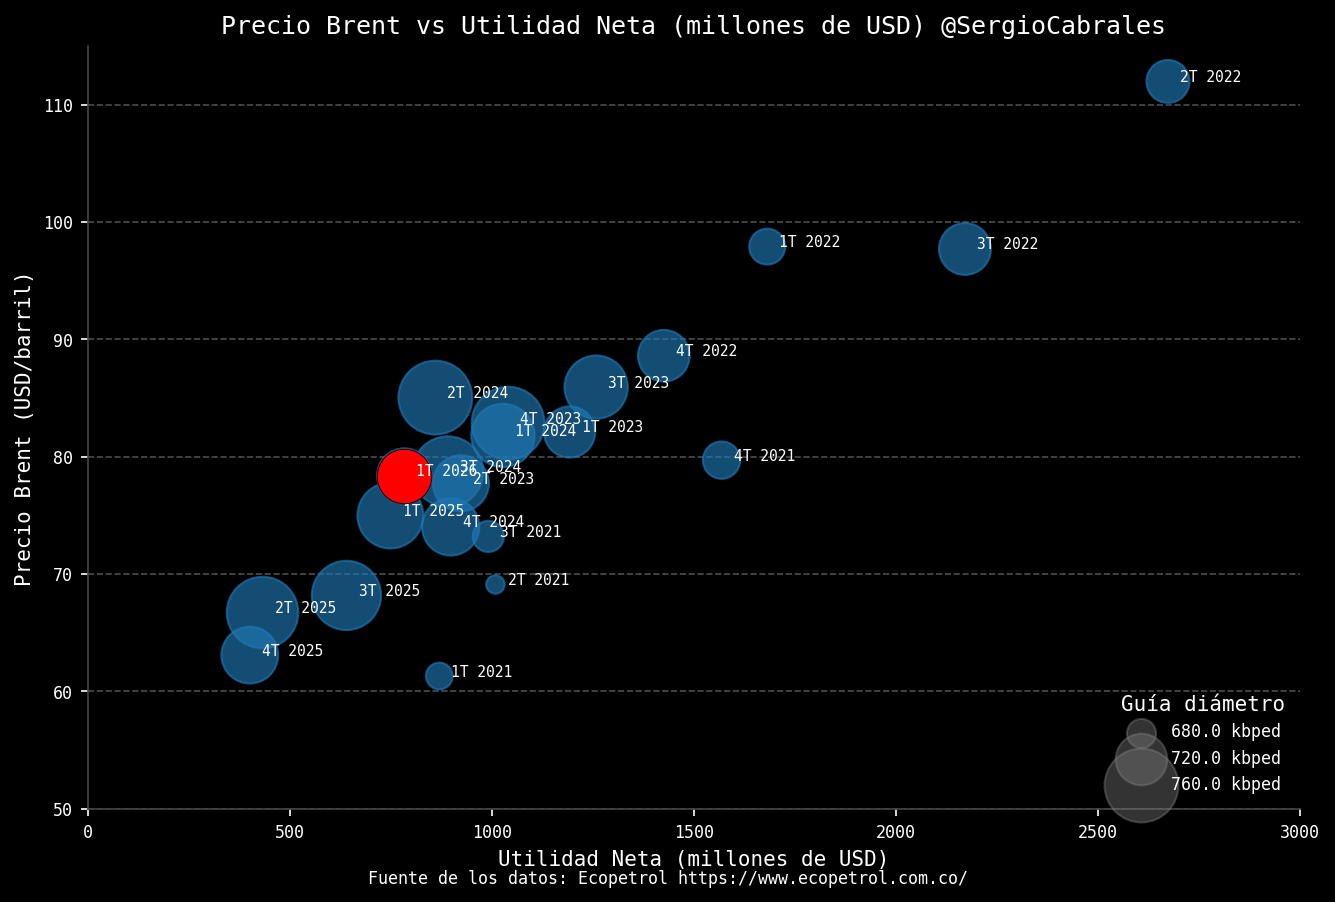

In [84]:
d_min, d_max = 10, 40
diametros_pts = np.interp(produccion, (min(produccion), max(produccion)), (d_min, d_max))
sizes = np.pi * (diametros_pts / 2) ** 2

plt.figure(figsize=(9, 6))
plt.scatter(utilidad_usd_millions, precio_brent, s=sizes, marker='o', alpha=0.65)
idx_special = len(trimestres) - 1
plt.scatter([utilidad_usd_millions[idx_special]], [precio_brent[idx_special]],
            s=[sizes[idx_special]], marker='o', color='red', edgecolor='black', linewidth=0.4, zorder=2)
plt.title('Precio Brent vs Utilidad Neta (millones de USD) @SergioCabrales')
plt.xlabel('Utilidad Neta (millones de USD)')
plt.ylabel('Precio Brent (USD/barril)')
plt.xlim(0, 3000)
plt.ylim(50, 115)
for i, tri in enumerate(trimestres):
    plt.text(utilidad_usd_millions[i] + 30, precio_brent[i], tri, fontsize=7)
for ref in [680, 720, 760]:
    d_ref = np.interp(ref, (min(produccion), max(produccion)), (d_min, d_max))
    s_ref = np.pi * (d_ref / 2) ** 2
    plt.scatter([], [], s=s_ref, marker='o', label=f'{ref:.1f} kbped', color='gray', zorder=2, alpha=0.4)
plt.legend(title='Guía diámetro', loc='lower right', frameon=False)
apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Reservas Probadas de Ecopetrol (MBPE)

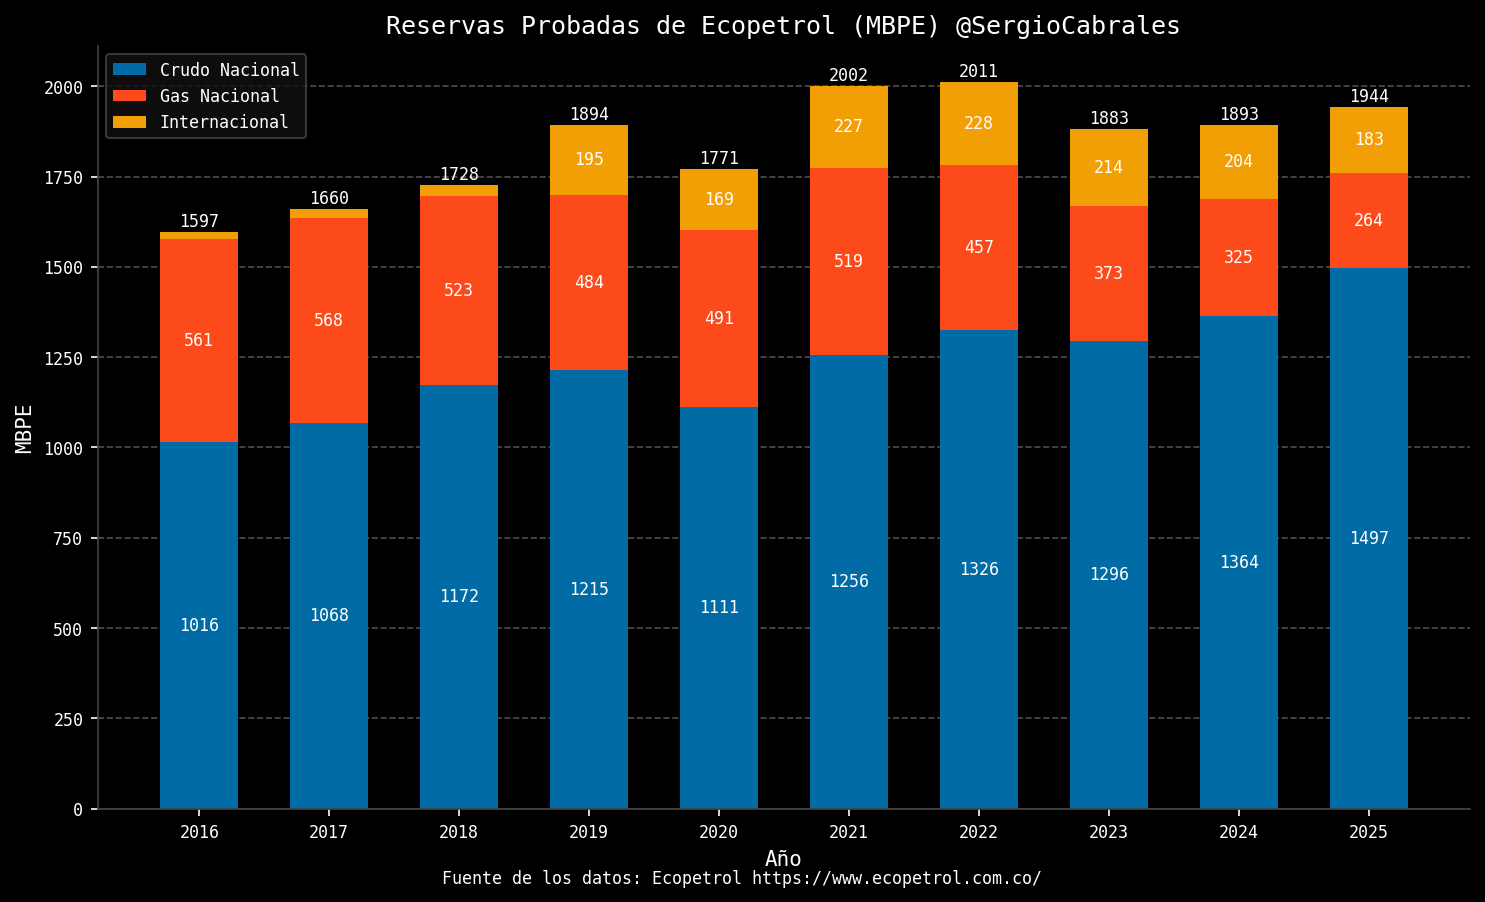

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.6
bar1 = ax.bar(years_reservas, crudo_nal, width=width, label='Crudo Nacional', color='#006BA4')
bar2 = ax.bar(years_reservas, gas_nal, width=width, bottom=crudo_nal, label='Gas Nacional', color='#FC4A1A')
bar3 = ax.bar(years_reservas, internac, width=width, bottom=crudo_nal + gas_nal, label='Internacional', color='#F29F05')

# Add text labels inside each bar segment if value > 100
# Crudo Nacional
for i, bar in enumerate(bar1):
    val = crudo_nal[i]
    if val > 100:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f"{int(val)}", ha='center', va='center', color='white', fontsize=8)

# Gas Nacional
for i, bar in enumerate(bar2):
    val = gas_nal[i]
    if val > 100:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f"{int(val)}", ha='center', va='center', color='white', fontsize=8)

# Internacional
for i, bar in enumerate(bar3):
    val = internac[i]
    if val > 100:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f"{int(val)}", ha='center', va='center', color='white', fontsize=8)

# Existing code for total reserves on top of the stack
for i in range(len(years_reservas)):
    ax.text(years_reservas[i], total_reservas[i] + 15, str(total_reservas[i]), ha='center', fontsize=8)

ax.set_title('Reservas Probadas de Ecopetrol (MBPE) @SergioCabrales')
ax.set_ylabel('MBPE')
ax.set_xlabel('Año')
ax.set_xticks(years_reservas)
ax.legend()
apply_bloomberg_theme()
plt.figtext(0.5, 0.01, 'Fuente de los datos: Ecopetrol https://www.ecopetrol.com.co/', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## Reservas Probadas (MBPE): Variación 2024-2025

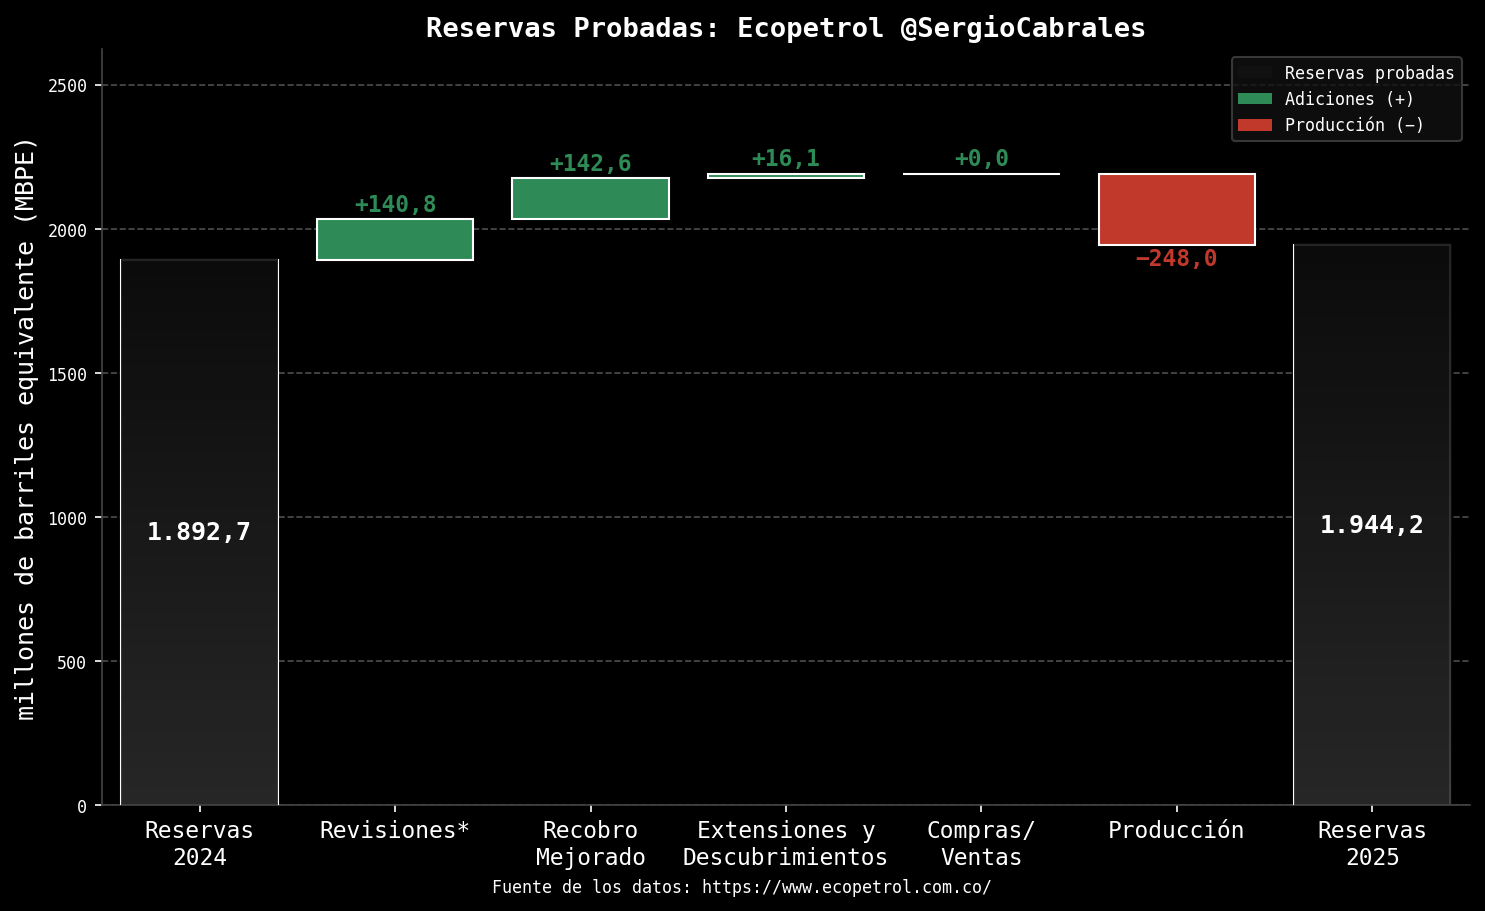

In [86]:
labels = ["Reservas\n2024"] + [s[0] for s in wf_steps] + ["Reservas\n2025"]
x = np.arange(len(labels))
c_pillar = "#111111"
c_plus   = "#2E8B57"
c_minus  = "#C0392B"
running = wf_start
bases   = [0]
heights = [wf_start]
colors  = [c_pillar]
for _, v in wf_steps:
    if v >= 0:
        base, height, color = running, v, c_plus
    else:
        base, height, color = running + v, -v, c_minus
    bases.append(base)
    heights.append(height)
    colors.append(color)
    running += v
bases.append(0)
heights.append(wf_end)
colors.append(c_pillar)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, heights, bottom=bases, color=colors, edgecolor="white", linewidth=1.0, zorder=3)

def add_vertical_shade(ax, rect, top="#2a2a2a", bottom="#0b0b0b"):
    x0, x1 = rect.get_x(), rect.get_x() + rect.get_width()
    y0, y1 = rect.get_y(), rect.get_y() + rect.get_height()
    grad = np.linspace(0, 1, 256).reshape(256, 1)
    cmap = mcolors.LinearSegmentedColormap.from_list("pillar_grad", [top, bottom])
    ax.imshow(grad, extent=[x0, x1, y0, y1], origin="lower", aspect="auto",
              cmap=cmap, zorder=4, alpha=0.9, interpolation="bicubic")

add_vertical_shade(ax, bars[0])
add_vertical_shade(ax, bars[-1])

fmt = lambda n: f"{n:,.1f}".replace(",", "X").replace(".", ",").replace("X", ".")
ax.text(x[0], wf_start / 2, fmt(wf_start), ha="center", va="center", color="white", fontsize=12, fontweight="bold", zorder=6)
ax.text(x[-1], wf_end / 2, fmt(wf_end), ha="center", va="center", color="white", fontsize=12, fontweight="bold", zorder=6)

for i, (label, v) in enumerate(wf_steps, start=1):
    if v >= 0:
        text_y, text_color, va = bases[i] + heights[i] + 10, c_plus, "bottom"
    else:
        text_y, text_color, va = bases[i] - 10, c_minus, "top"
    sign_char = "+" if v >= 0 else "−"
    ax.text(x[i], text_y, f"{sign_char}{fmt(abs(v))}", ha="center", va=va, fontsize=11, fontweight="bold", color=text_color, zorder=6)

ax.set_title("Reservas Probadas: Ecopetrol @SergioCabrales", fontsize=13, fontweight="bold")
ax.set_ylabel("millones de barriles equivalente (MBPE)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, max(wf_start, wf_end) * 1.35)
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
legend_items = [
    Patch(facecolor=c_pillar, edgecolor="none", label="Reservas probadas"),
    Patch(facecolor=c_plus, edgecolor="none", label="Adiciones (+)"),
    Patch(facecolor=c_minus, edgecolor="none", label="Producción (−)"),
]
ax.legend(handles=legend_items, loc="upper right", frameon=True)
plt.figtext(0.5, 0.0, 'Fuente de los datos: https://www.ecopetrol.com.co/', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## Razones financieras

In [111]:
# --- 1. Clasificación de ratios ---
liquidez = [
    "Current ratio",
    "Quick assets to total assets",
    "Quick assets to sales",
    "Current liabilities to total assets",
    "Working capital to sales",
    "Working capital to total assets",
]

rentabilidad = [
    "Net income to sales",
    "Net income to total assets (ROA)",
    "Net income to total debt",
    "Net income to equity (ROE)"
]

apalancamiento = [
    "Total liabilities to total assets",
    "Book value of equity to total liabilities",
    "Net worth to sales",
]

eficiencia = [
    "Sales to total assets",
    "Cash to sales",
    "Cash to total assets",
]

flujo_caja = [
    "Cash flow to sales",
    "Cash flow to total assets",
    "Cash flow to total debt",
    "Cash flow to net worth",
    "Cash interval (days)",
    "No-credit interval (days)",
]

In [112]:
# --- 2. Datos base desde el Excel (P&G, Balance General, Flujo de Efectivo) ---
periodos_rf = trimestres  # 1T 2021 ... 1T 2026

ventas   = np.array(leer_serie("P&G - P&L", "Total ingresos", periodos_rf))
cogs     = np.array(leer_serie("P&G - P&L", "Total costo de ventas", periodos_rf))
gastos_op = np.array(leer_serie("P&G - P&L", "Gastos operacionales", periodos_rf))
ni       = np.array(leer_serie("P&G - P&L", "Utilidad neta atribuible a accionistas de Ecopetrol", periodos_rf))

activos_corr    = np.array(leer_serie("BG - BS", "Total activos corrientes", periodos_rf))
activos_totales = np.array(leer_serie("BG - BS", "Total activos", periodos_rf))
pasivos_corr    = np.array(leer_serie("BG - BS", "Total pasivos corrientes", periodos_rf))
pasivos_totales = np.array(leer_serie("BG - BS", "Total pasivos", periodos_rf))
patrimonio      = np.array(leer_serie("BG - BS", "Total patrimonio", periodos_rf))
efectivo        = np.array(leer_serie("BG - BS", "Efectivo y equivalentes de efectivo", periodos_rf))
inventarios     = np.array(leer_serie("BG - BS", "Inventarios", periodos_rf))
prestamos_cp    = np.array(leer_serie("BG - BS", "Préstamos corto plazo", periodos_rf))
prestamos_lp    = np.array(leer_serie("BG - BS", "Préstamos largo plazo", periodos_rf))
cuentas_x_cobrar = np.array(leer_serie("BG - BS", "Cuentas comerciales y otras cuentas por cobrar", periodos_rf))

flujo_caja_operativo = np.array(leer_serie("FC - CF", "Efectivo neto generado por las actividades de operación", periodos_rf))

# --- 3. Variables intermedias ---
deuda_total       = prestamos_cp + prestamos_lp
deuda_neta        = deuda_total - efectivo
capital_trabajo    = activos_corr - pasivos_corr
activos_rapidos    = activos_corr - inventarios
# Gasto operativo diario del trimestre (costo de ventas + gastos operacionales, sobre ~91 días)
gasto_operativo_diario = (cogs + gastos_op) / 91

# --- 4. Cálculo de las 21 razones financieras ---
razones = {
    # Liquidez
    "Current ratio": activos_corr / pasivos_corr,
    "Quick assets to total assets": activos_rapidos / activos_totales,
    "Quick assets to sales": activos_rapidos / ventas,
    "Current liabilities to total assets": pasivos_corr / activos_totales,
    "Working capital to sales": capital_trabajo / ventas,
    "Working capital to total assets": capital_trabajo / activos_totales,
    # Rentabilidad
    "Net income to sales": ni / ventas,
    "Net income to total assets (ROA)": ni / activos_totales,
    "Net income to total debt": ni / deuda_total,
    "Net income to equity (ROE)": ni / patrimonio,
    # Apalancamiento
    "Total liabilities to total assets": pasivos_totales / activos_totales,
    "Book value of equity to total liabilities": patrimonio / pasivos_totales,
    "Net worth to sales": patrimonio / ventas,
    "Net Debt": deuda_neta,
    # Eficiencia
    "Sales to total assets": ventas / activos_totales,
    "Cash to sales": efectivo / ventas,
    "Cash to total assets": efectivo / activos_totales,
    # Flujo de caja
    "Cash flow to sales": flujo_caja_operativo / ventas,
    "Cash flow to total assets": flujo_caja_operativo / activos_totales,
    "Cash flow to total debt": flujo_caja_operativo / deuda_total,
    "Cash flow to net worth": flujo_caja_operativo / patrimonio,
    "Cash interval (days)": (efectivo + cuentas_x_cobrar) / gasto_operativo_diario,
    "No-credit interval (days)": efectivo / gasto_operativo_diario,
}

In [113]:
# --- 5. Función de graficado (una figura por categoría de razones) ---
def graficar_razones(nombres, titulo, periodos=periodos_rf, nombres_eje_dias=None):
    """Grafica la evolución trimestral de una lista de razones (del dict `razones`).
    `nombres_eje_dias` (opcional) grafica esas razones en un eje Y secundario (para las
    razones en días, cuya escala es muy distinta a las razones adimensionales)."""
    fig, ax = plt.subplots(figsize=(11, 6))
    x = range(len(periodos))
    for nombre in nombres:
        ax.plot(x, razones[nombre], marker='o', linewidth=1.8, label=nombre)

    lines, labels = ax.get_legend_handles_labels()
    if nombres_eje_dias:
        ax2 = ax.twinx()
        for nombre in nombres_eje_dias:
            ax2.plot(x, razones[nombre], marker='s', linestyle='--', linewidth=1.8, label=nombre)
        ax2.set_ylabel("Días")
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines, labels = lines + lines2, labels + labels2
        ax.spines["right"].set_visible(True)
    else:
        ax.spines["right"].set_visible(False)

    ax.legend(lines, labels, loc='upper left', fontsize=8, frameon=False)
    ax.set_title(f"{titulo} @SergioCabrales", fontsize=12, weight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(periodos, rotation=45, ha='right')
    ax.spines["top"].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    plt.figtext(0.5, 0.0, "Fuente de los datos: Ecopetrol (Estados Financieros Consolidados)", ha="center", fontsize=8)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

### Liquidez

🔹 1. Liquidez

Evalúan la capacidad de la empresa para cumplir sus obligaciones de corto plazo.

Current ratio: mide la capacidad de cubrir pasivos corrientes con activos corrientes. Un valor mayor a 1 indica solvencia de corto plazo.

Quick assets to total assets: proporción de activos líquidos (efectivo, inversiones de corto plazo, cuentas por cobrar) sobre el total de activos; refleja la flexibilidad financiera.

Quick assets to sales: muestra la relación entre los activos líquidos y las ventas, indicando cuántos recursos líquidos respaldan la generación de ingresos.

Current liabilities to total assets: porcentaje de activos financiados con pasivos de corto plazo; altos valores implican mayor presión financiera inmediata.

Working capital to sales: relación entre el capital de trabajo y las ventas; mide cuánto capital operativo se requiere para sostener el nivel de ventas.

Working capital to total assets: proporción del capital de trabajo dentro del total de activos; refleja la estructura de liquidez de la empresa.

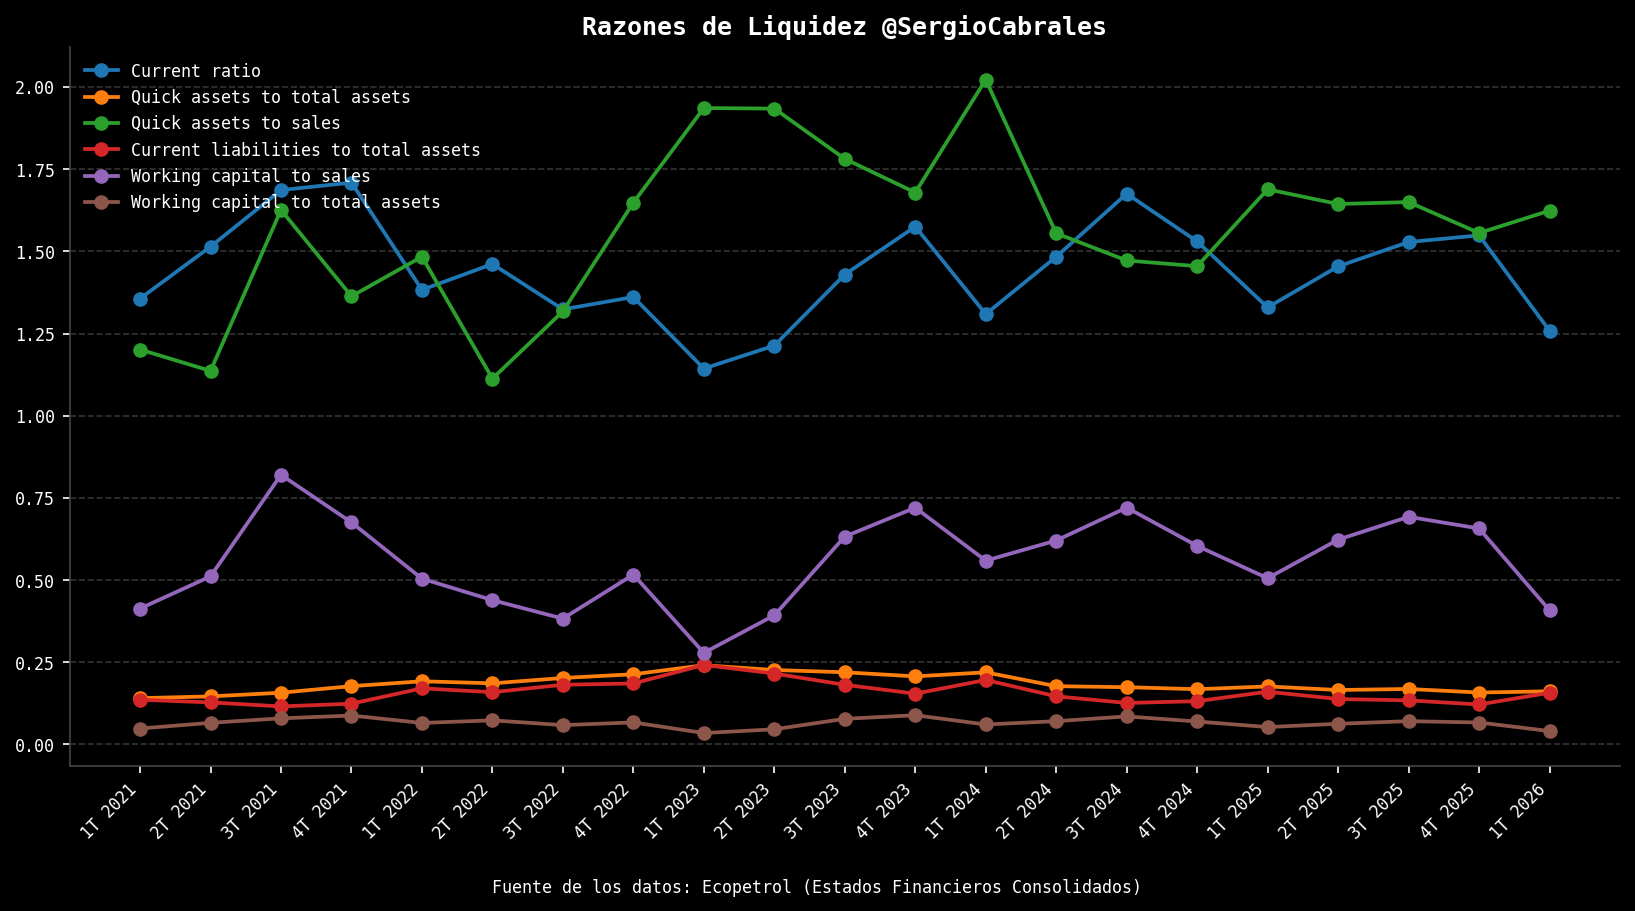

In [114]:
graficar_razones(liquidez, "Razones de Liquidez")

### Rentabilidad

🔹 2. Rentabilidad

Miden la capacidad de generar utilidades a partir de las ventas, los activos o el endeudamiento.

Net income to sales (margen neto): porcentaje de utilidad neta sobre las ventas; indica la eficiencia en el control de costos y gastos.

Net income to total assets (ROA): rentabilidad sobre activos; mide la eficiencia del uso de los activos para generar utilidades.

Net income to total debt: muestra cuánto beneficio neto se obtiene en relación con el total de deuda; refleja la capacidad de cubrir obligaciones financieras con resultados.

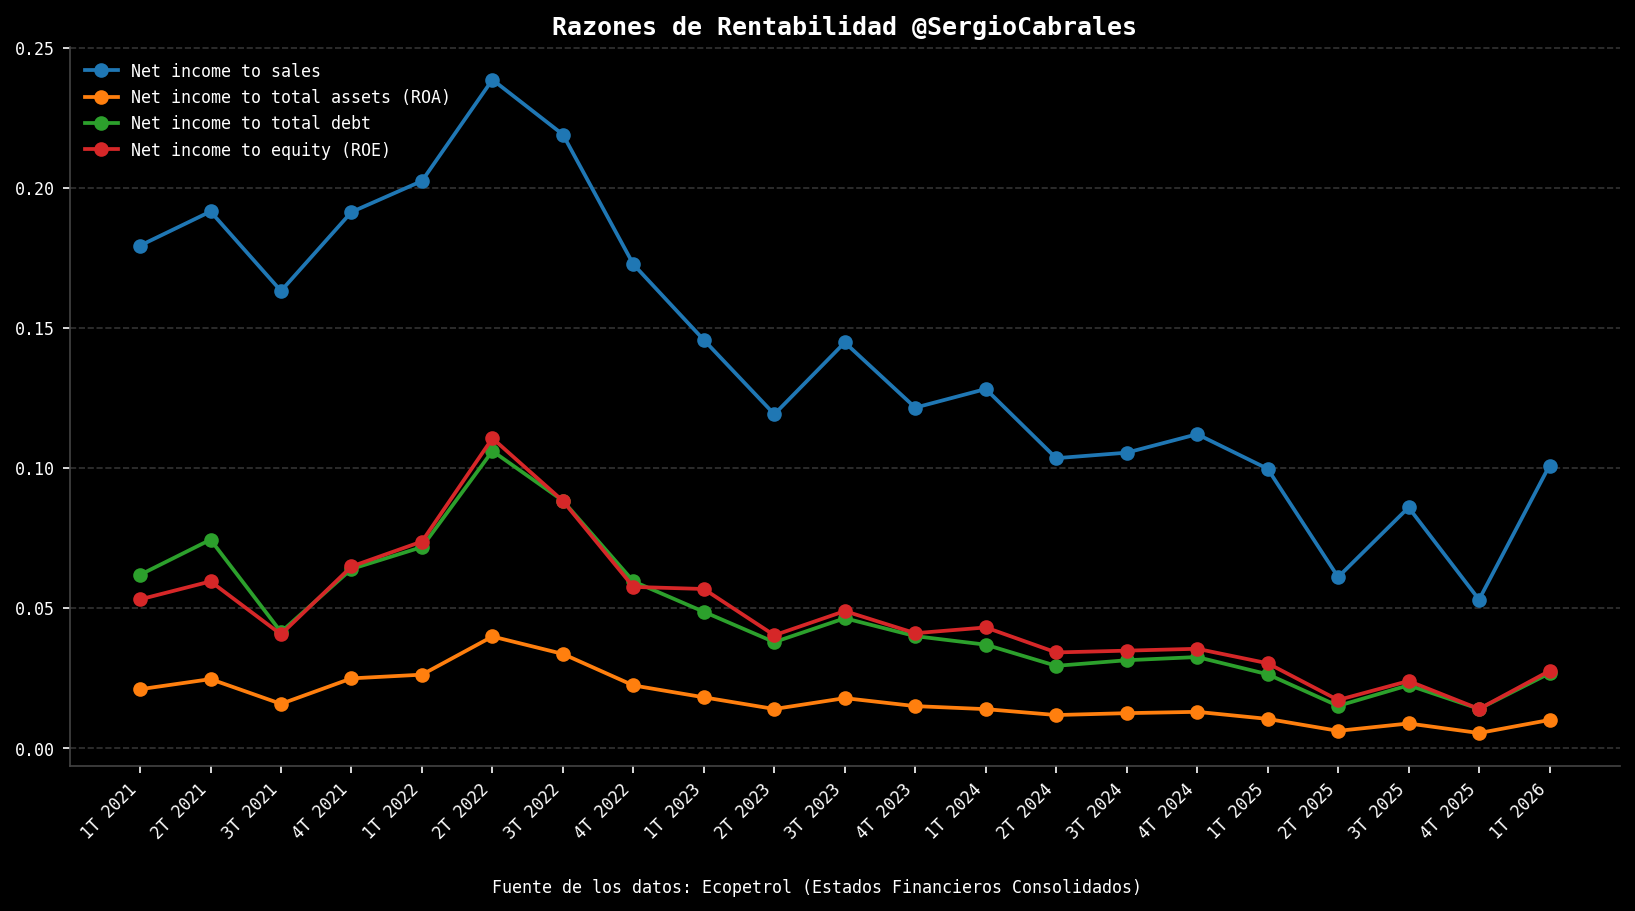

In [115]:
graficar_razones(rentabilidad, "Razones de Rentabilidad")

### Apalancamiento

🔹 3. Apalancamiento

Evalúan el grado de endeudamiento y la estructura de capital.

Total liabilities to total assets: proporción de activos financiados con deuda; indica el riesgo financiero.

Book value of equity to total liabilities: compara el patrimonio contable con las deudas; un valor alto sugiere mayor respaldo patrimonial.

Net worth to sales: muestra la relación entre el patrimonio neto y las ventas; mide la eficiencia del capital propio para generar ingresos.

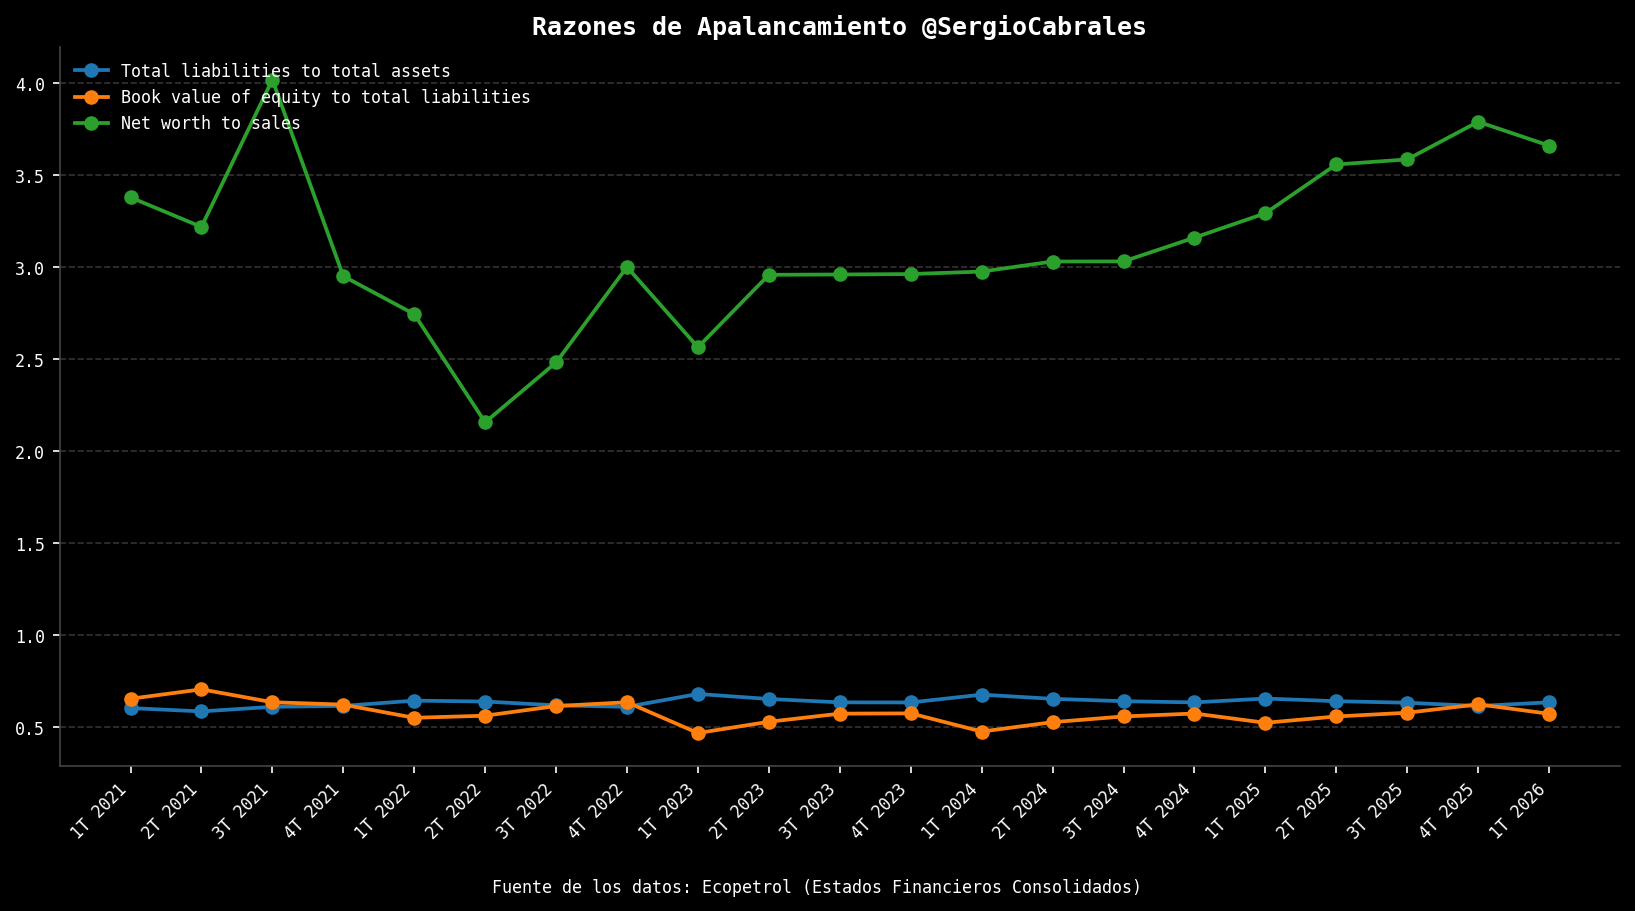

In [116]:
graficar_razones(apalancamiento, "Razones de Apalancamiento")

### Eficiencia o gestión

🔹 4. Eficiencia o gestión

Analizan el uso de los recursos en la generación de ventas.

Sales to total assets (rotación de activos): mide cuántas ventas se generan por unidad de activo; refleja eficiencia operativa.

Cash to sales: indica la proporción de ventas respaldada por efectivo; mide la liquidez operativa.

Cash to total assets: muestra la fracción de activos mantenida en efectivo; refleja disponibilidad inmediata de fondos.

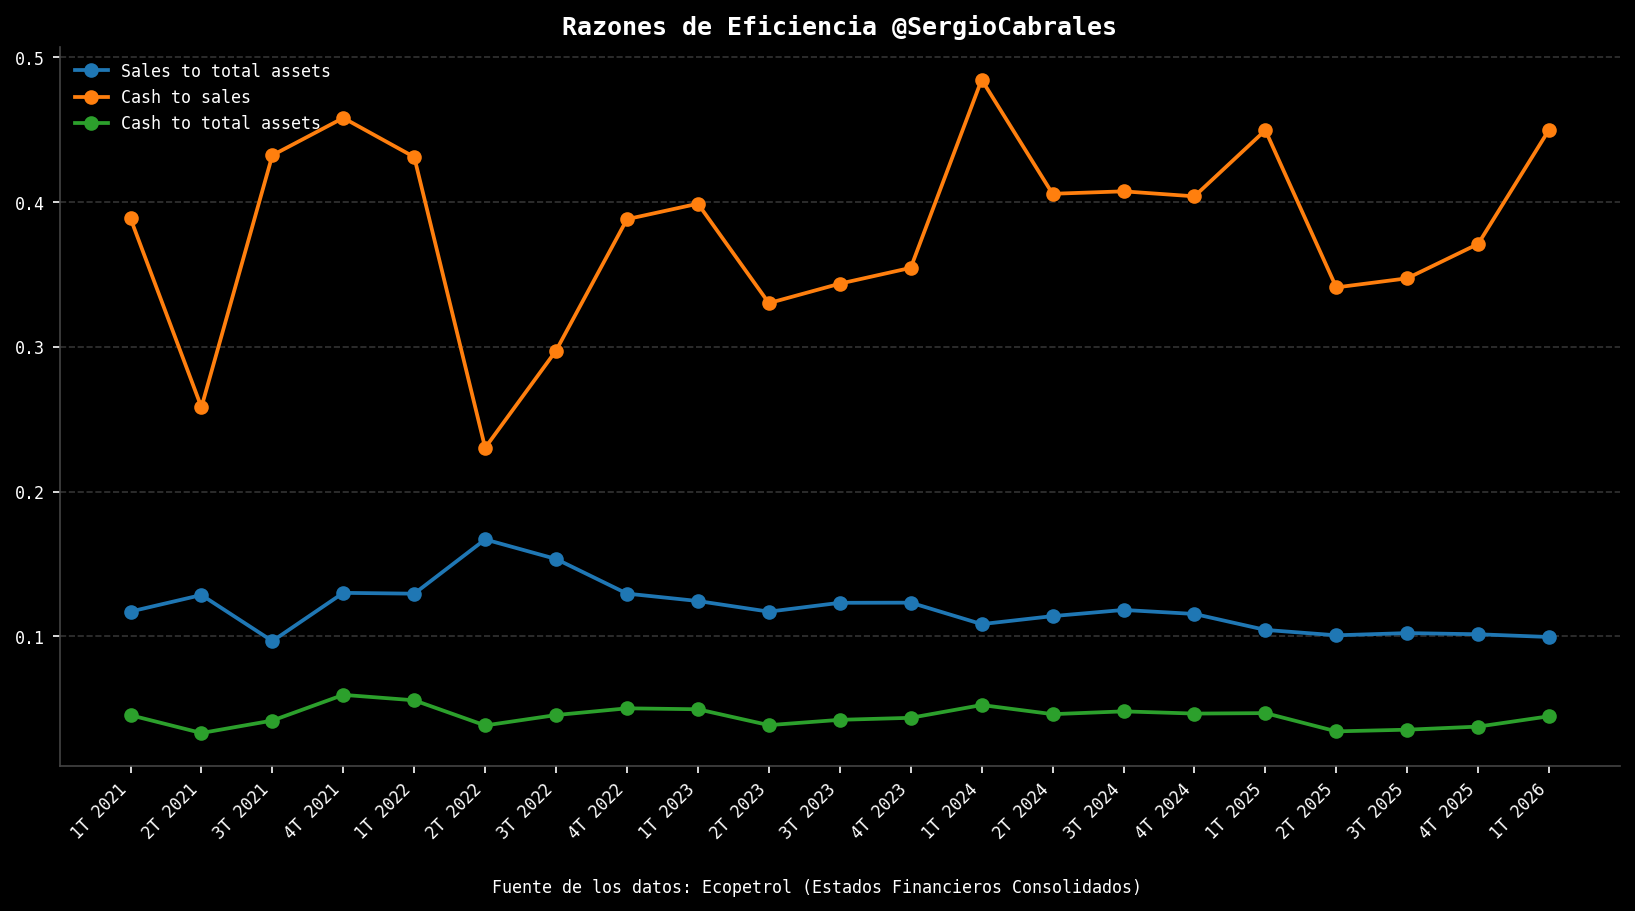

In [117]:
graficar_razones(eficiencia, "Razones de Eficiencia")

### Flujo de caja

🔹 5. Flujo de caja

Evalúan la capacidad de la empresa para generar efectivo y mantener su operación.

Cash flow to sales: porcentaje del flujo de caja operativo respecto a las ventas; mide la conversión de ingresos en efectivo.

Cash flow to total assets: eficiencia de los activos para generar flujo de efectivo operativo.

Cash flow to total debt: capacidad del flujo de caja para cubrir el total de deuda; mide solvencia.

Cash flow to net worth: flujo de caja en relación con el patrimonio; evalúa el retorno efectivo para los accionistas.

Cash interval (days): días que la empresa puede operar con su efectivo y equivalentes sin recibir ingresos adicionales.

No-credit interval (days): días que puede operar considerando efectivo, inversiones de corto plazo y cuentas por cobrar; refleja la autonomía de corto plazo.

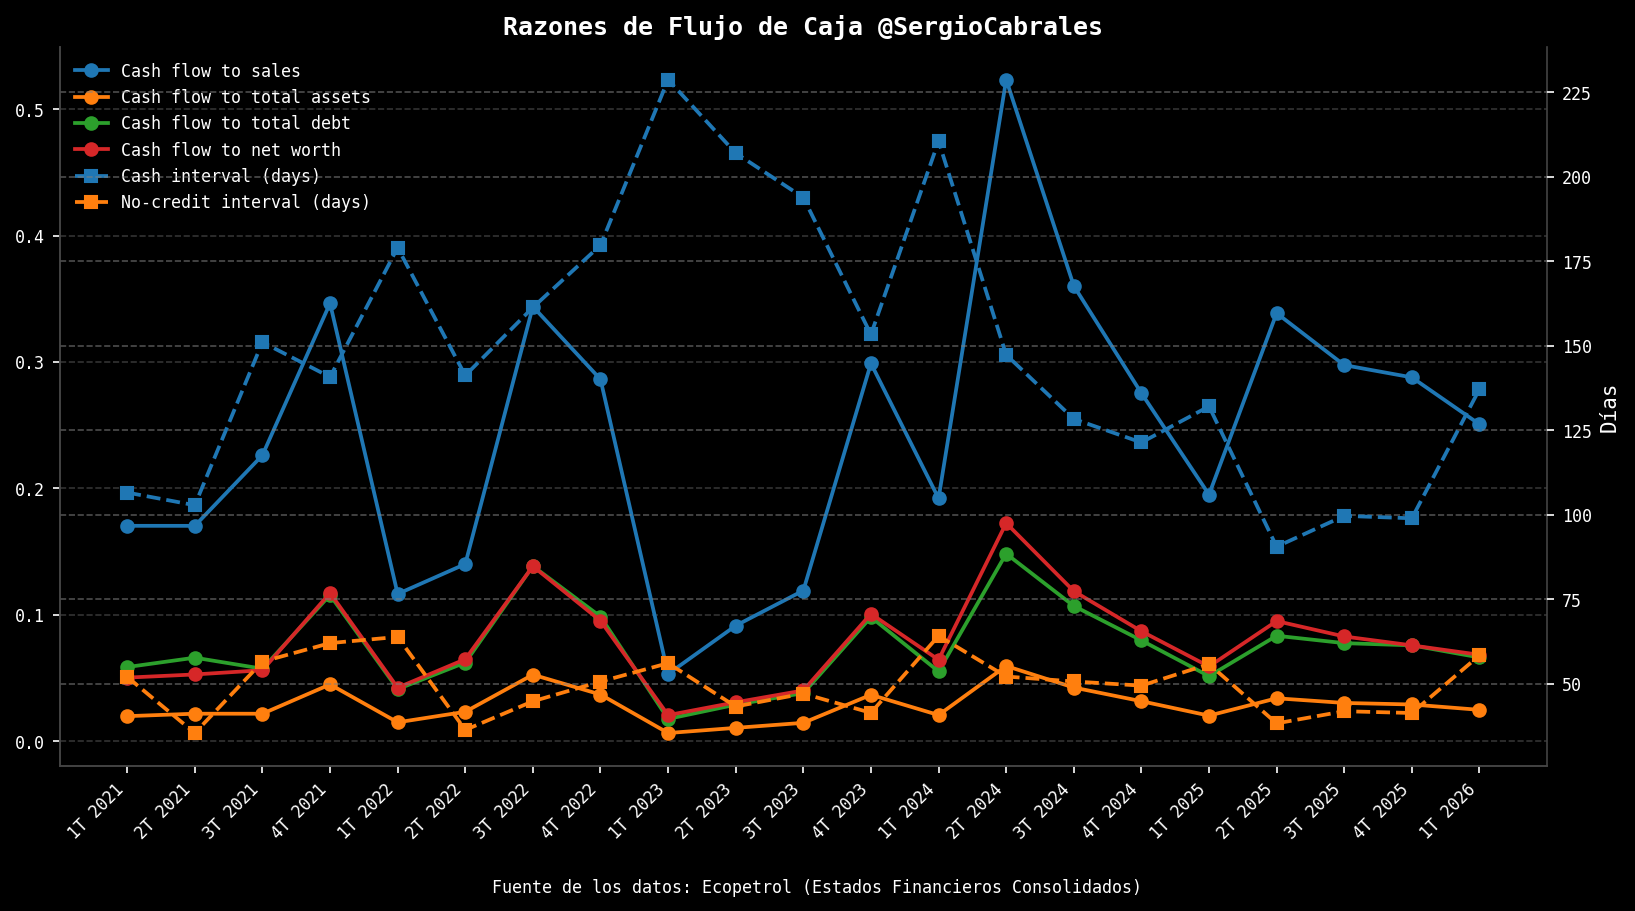

In [118]:
# Las dos razones en días ("interval") van en un eje secundario por su escala distinta
razones_dias = [r for r in flujo_caja if "days" in r]
razones_multiplo = [r for r in flujo_caja if r not in razones_dias]
graficar_razones(razones_multiplo, "Razones de Flujo de Caja", nombres_eje_dias=razones_dias)

## Deuda Consolidada de Ecopetrol

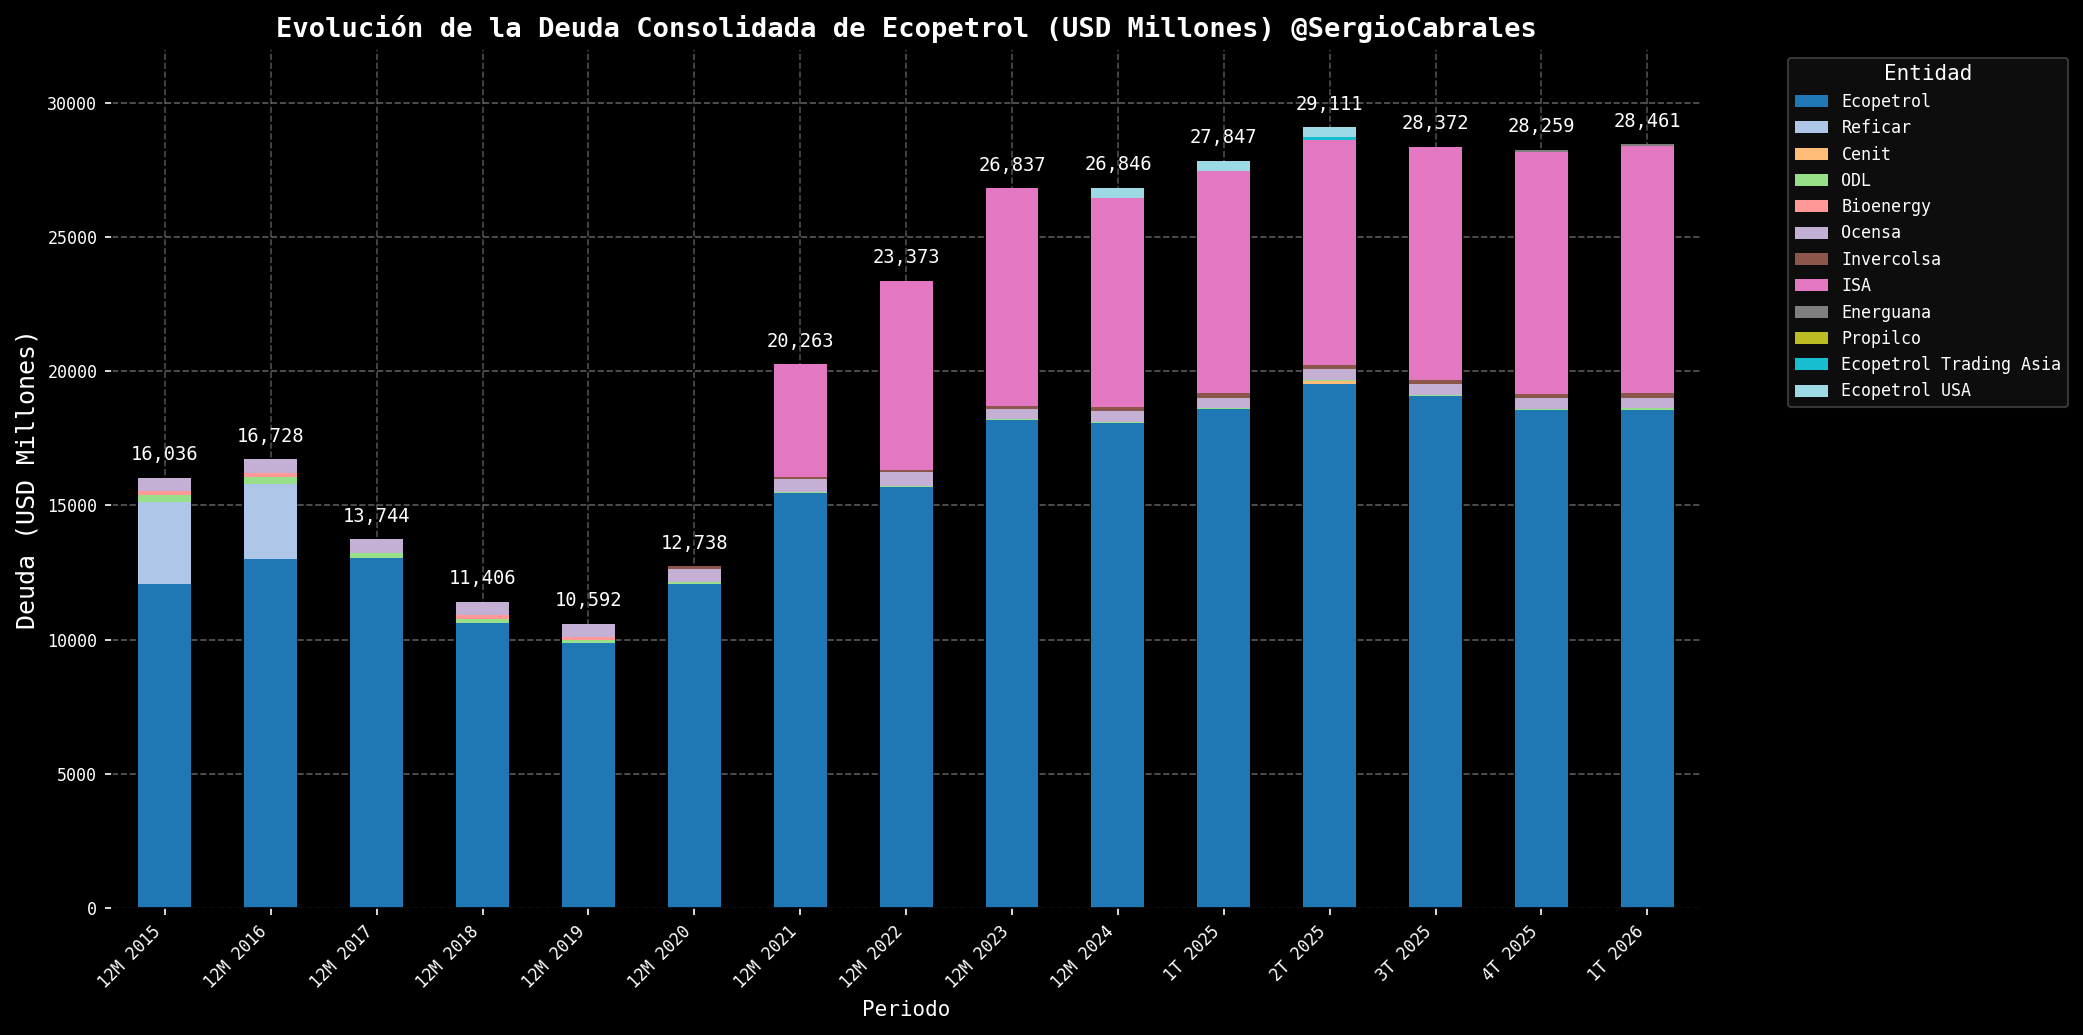

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos: Deuda por entidad (USD Millones), hoja "Financieros - Financials"
periodos_deuda = [
    "12M 2015", "12M 2016", "12M 2017", "12M 2018", "12M 2019",
    "12M 2020", "12M 2021", "12M 2022", "12M 2023", "12M 2024",
    "1T 2025", "2T 2025", "3T 2025", "4T 2025", "1T 2026",
]
entidades_deuda = [
    "Ecopetrol", "Reficar", "Cenit", "ODL", "Bioenergy", "Ocensa",
    "Invercolsa", "ISA", "Energuana", "Propilco", "Ecopetrol Trading Asia", "Ecopetrol USA",
]

data = {"Periodo": periodos_deuda}
for entidad in entidades_deuda:
    valores = leer_serie("Financieros - Financials", entidad, periodos_deuda)
    data[entidad] = [0 if (v is None or (isinstance(v, float) and np.isnan(v))) else v for v in valores]

# Crear DataFrame
df = pd.DataFrame(data)
df.set_index("Periodo", inplace=True)
df["Total"] = df[entidades_deuda].sum(axis=1)

# Graficar
plt.figure(figsize=(16, 8))
ax = df[entidades_deuda].plot(kind="bar", stacked=True, figsize=(14, 7), colormap="tab20", ax=plt.gca())

plt.title("Evolución de la Deuda Consolidada de Ecopetrol (USD Millones) @SergioCabrales", fontsize=13, weight="bold")
plt.ylabel("Deuda (USD Millones)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Entidad", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Etiquetas de total encima de cada barra
for i, total in enumerate(df["Total"]):
    ax.text(i, total + 500, f"{total:,.0f}", ha='center', va='bottom', fontsize=9)

# Estilo tipo The Economist
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color("black")
plt.gca().spines["bottom"].set_color("black")
plt.ylim(0, 32000)
plt.tight_layout()
plt.show()

## Market Value / Book Value

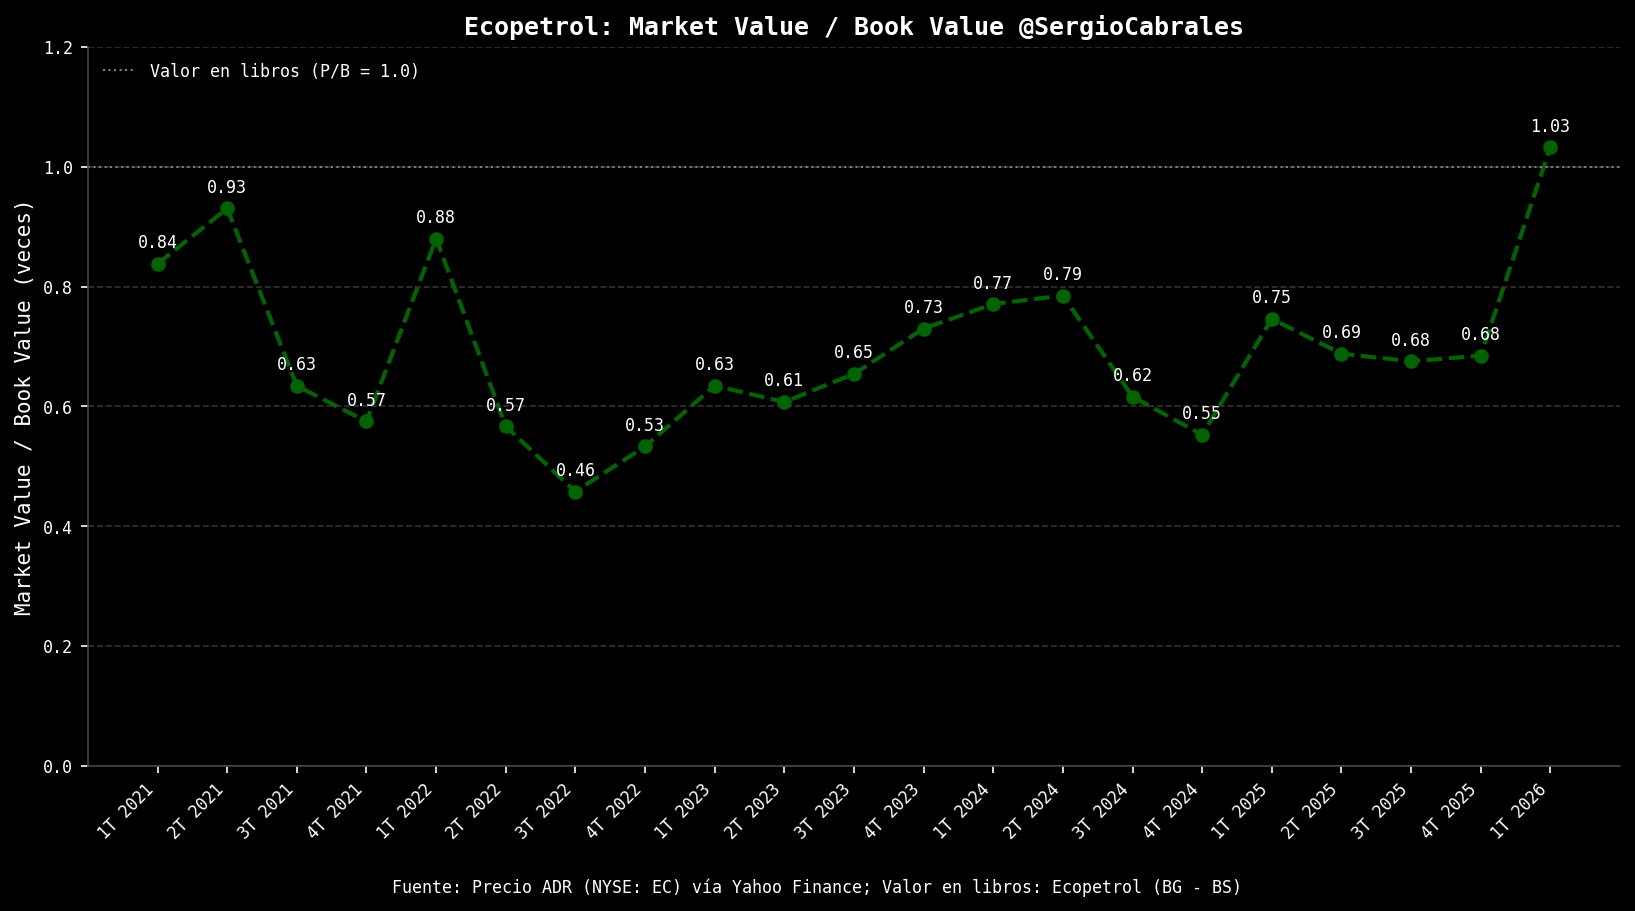

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Datos: Market Value (ADR de Ecopetrol en NYSE, ticker EC vía Yahoo Finance)
# vs. Book Value ("Total patrimonio", hoja "BG - BS")
periodos_vb = trimestres  # 1T 2021 ... 1T 2026

# Precio de cierre trimestral del ADR
_ec = yf.Ticker("EC")
_precio_cierre_trimestral = _ec.history(start="2020-12-01")["Close"].resample("QE").last()
precio_adr_por_trimestre = {
    f"{(ts.month - 1) // 3 + 1}T {ts.year}": precio
    for ts, precio in _precio_cierre_trimestral.items()
}
precio_adr = np.array([precio_adr_por_trimestre.get(p, np.nan) for p in periodos_vb])

# 1 ADR = 20 acciones ordinarias -> "sharesOutstanding" que reporta Yahoo para EC
# ya viene expresado en ADRs equivalentes (acciones ordinarias en circulación / 20)
adr_equivalentes = _ec.info["sharesOutstanding"]

# Market value = Precio ADR (USD) x ADRs equivalentes x TRM, en miles de millones COP
# (misma unidad que "Total patrimonio" en BG - BS). Se asume el número de ADRs
# equivalentes constante en el tiempo (Ecopetrol no ha tenido recompras/emisiones
# relevantes en el periodo analizado).
market_value = precio_adr * adr_equivalentes * np.array(TRM_trimestral) / 1e9
book_value = np.array(leer_serie("BG - BS", "Total patrimonio", periodos_vb))
value_to_book = market_value / book_value

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(periodos_vb))
ax.plot(x, value_to_book, marker="o", linestyle="--", color="darkgreen", linewidth=2)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="Valor en libros (P/B = 1.0)")

for i, v in enumerate(value_to_book):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_title("Ecopetrol: Market Value / Book Value @SergioCabrales", fontsize=12, weight="bold")
ax.set_ylabel("Market Value / Book Value (veces)")
ax.set_xticks(list(x))
ax.set_xticklabels(periodos_vb, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_ylim(0, 1.2)
ax.set_axisbelow(True)
plt.figtext(0.5, 0.0, "Fuente: Precio ADR (NYSE: EC) vía Yahoo Finance; Valor en libros: Ecopetrol (BG - BS)",
            ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Enterprise Value: Market Value + Deuda

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Datos: Deuda Bruta / EBITDA (UDM), hojas "BG - BS", "P&G - P&L" y "Financieros - Financials"
periodos_deb_ebitda = trimestres  # 1T 2021 ... 1T 2026

# EBITDA trimestral con 3 trimestres extra de historia (2T-4T 2020) para poder
# calcular el EBITDA de los últimos doce meses (UDM/TTM) desde 1T 2021 en adelante
_periodos_ebitda_hist = ["2T 2020", "3T 2020", "4T 2020"] + periodos_deb_ebitda
_ebitda_hist = np.array(leer_serie("P&G - P&L", "EBITDA", _periodos_ebitda_hist))
ebitda_ttm = np.array([_ebitda_hist[i:i + 4].sum() for i in range(len(periodos_deb_ebitda))])

# `deuda_total` (Préstamos corto + largo plazo, BG - BS) ya se calculó en la
# sección de Razones Financieras, en la misma unidad (miles de millones COP)
deuda_bruta_ebitda = deuda_total / ebitda_ttm

def a_float(v):
    """Convierte a float; '-' o vacío -> 0.0 (ISA no consolidada antes de la adquisición)."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return 0.0

# --- Serie adicional: excluyendo ISA ---
# Deuda de ISA está en USD Millones (hoja "Financieros - Financials"); se convierte
# a miles de millones COP con la TRM trimestral para restarla de `deuda_total`.
# ISA se incorporó al grupo a mediados de 2021: antes de la adquisición la celda
# viene vacía/"-" en el Excel (leer_serie la deja como NaN), y como `deuda_total`
# tampoco incluía deuda de ISA en esos trimestres, se trata como 0 en vez de NaN
# para no dejar la serie "ex-ISA" en blanco antes de la adquisición.
deuda_isa_usd = np.array([a_float(v) for v in
                           leer_serie("Financieros - Financials", "ISA", periodos_deb_ebitda)])
deuda_isa_cop = deuda_isa_usd * np.array(TRM_trimestral) / 1000
deuda_bruta_ex_isa = deuda_total - deuda_isa_cop

# EBITDA de ISA por segmento (hoja "P&G Seg - P&L Seg"), con su propia historia
# 2T-4T 2020 para el UDM. Mismo tratamiento que la deuda: "-"/vacío antes de la
# adquisición -> 0 (no hacía parte del grupo consolidado), en vez de NaN.
_ebitda_isa_hist = np.array([a_float(v) for v in leer_serie_segmento(
    "P&G Seg - P&L Seg", "Miles de Millones (COP) - ISA", "EBITDA", _periodos_ebitda_hist
)])
ebitda_isa_ttm = np.array([_ebitda_isa_hist[i:i + 4].sum() for i in range(len(periodos_deb_ebitda))])
ebitda_ttm_ex_isa = ebitda_ttm - ebitda_isa_ttm
deuda_bruta_ebitda_ex_isa = deuda_bruta_ex_isa / ebitda_ttm_ex_isa

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(periodos_deb_ebitda))
ax.plot(x, deuda_bruta_ebitda, marker="o", linestyle="--", color="darkred", linewidth=2,
        label="Deuda Bruta / EBITDA (consolidado)")
ax.plot(x, deuda_bruta_ebitda_ex_isa, marker="s", linestyle="--", color="#006BA4", linewidth=2,
        label="Deuda Bruta / EBITDA (excluyendo ISA)")

for i, (v, v_ex) in enumerate(zip(deuda_bruta_ebitda, deuda_bruta_ebitda_ex_isa)):
    ax.text(i, v + 0.05, f"{v:.2f}x", ha="center", va="bottom", fontsize=7, color="darkred")
    ax.text(i, v_ex - 0.12, f"{v_ex:.2f}x", ha="center", va="top", fontsize=7, color="#006BA4")

ax.set_title("Ecopetrol: Deuda Bruta / EBITDA (UDM) @SergioCabrales", fontsize=12, weight="bold")
ax.set_ylabel("Deuda Bruta / EBITDA (veces)")
ax.set_xticks(list(x))
ax.set_xticklabels(periodos_deb_ebitda, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.figtext(0.5, 0.0,
            "Fuente: Ecopetrol (BG - BS, P&G - P&L, P&G Seg - P&L Seg, Financieros - Financials). "
            "EBITDA de los últimos doce meses (UDM/TTM)",
            ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Utilidad Neta: Comparación Compañías Petroleras FY 2024 vs FY 2025

In [ ]:
x = np.arange(len(companies))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width / 2, net_income_fy2024, width, label='FY 2024', color='navy')
bars2 = ax.bar(x + width / 2, net_income_fy2025, width, label='FY 2025', color='#CC2200')
for b1, b2, v24, v25, chg in zip(bars1, bars2, net_income_fy2024, net_income_fy2025, percent_change):
    ax.text(b1.get_x() + b1.get_width() / 2, b1.get_height() + 0.8,
            f"{v24:.1f}", ha='center', va='bottom', fontsize=11, color='white')
    ax.text(b2.get_x() + b2.get_width() / 2, b2.get_height() + 0.8,
            f"{v25:.1f}", ha='center', va='bottom', fontsize=11, color='white')
    color_chg = '#006400' if chg >= 0 else '#8B0000'
    ax.text(b2.get_x() + b2.get_width() / 2, max(b1.get_height(), b2.get_height()) + 6,
            f"{chg:+.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')
ax.set_title("Net Income of Major Oil & Gas Companies – 2025 @SergioCabrales", fontsize=13, weight='bold', pad=16)
ax.set_ylabel("Utilidad neta (billion USD)")
ax.set_xticks(x)
ax.set_xticklabels(companies, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.annotate(
    "* Aramco y Petrobras FY2025: estimados (sin reporte anual oficial al cierre de la gráfica).\n"
    "  BP = underlying RC profit; TotalEnergies = adjusted net op. income; Eni en USD (€×1.04); Ecopetrol en USD.",
    xy=(0, -0.22), xycoords='axes fraction', fontsize=7.5, color='#555555')
plt.tight_layout()
plt.show()

## Margen Bruto de Refinación

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Clear caches to ensure fresh read of the excel file
_workbook.cache_clear()
_hoja.cache_clear()

# Datos: Margen Bruto (USD/Bl) por refinería (hoja "MID - DOWN")
periodos_margen_ref = trimestres  # 1T 2021 ... 1T 2026

# Usamos leer_serie_segmento para obtener el margen bruto de cada refinería
margen_cartagena = leer_serie_segmento("MID - DOWN", "Refinería de Cartagena", "Margen Bruto (USD/Bl)", periodos_margen_ref)
margen_bquilla = leer_serie_segmento("MID - DOWN", "Refinería de Barrancabermeja", "Margen Bruto (USD/Bl)", periodos_margen_ref)

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(periodos_margen_ref))
ax.plot(x, margen_cartagena, marker="o", color="#006BA4", linestyle='--', label="Refinería de Cartagena")
ax.plot(x, margen_bquilla, marker="s", color="#CC2200", linestyle='--', label="Refinería de Barrancabermeja")

ax.set_title("Margen Bruto de Refinación (USD/Bl) @SergioCabrales", fontsize=12, weight="bold")
ax.set_ylabel("USD/Barril")
ax.set_xticks(list(x))
ax.set_xticklabels(periodos_margen_ref, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_ylim(0, 38)
plt.figtext(0.5, 0.0, "Fuente de los datos: Ecopetrol (Reporte Financiero Trimestral)", ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Carga de Refinerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Datos: Carga (kbpd) por refinería (hoja "MID - DOWN")
periodos_carga = trimestres  # 1T 2021 ... 1T 2026

carga_cartagena = np.array(leer_serie_segmento("MID - DOWN", "Refinería de Cartagena", "Carga (kbpd)", periodos_carga))
carga_bquilla = np.array(leer_serie_segmento("MID - DOWN", "Refinería de Barrancabermeja", "Carga (kbpd)", periodos_carga))
carga_total = carga_cartagena + carga_bquilla

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(periodos_carga))

ax.bar(x, carga_bquilla, color="#006BA4", label="Refinería de Barrancabermeja")
ax.bar(x, carga_cartagena, bottom=carga_bquilla, color="#F29F05", label="Refinería de Cartagena")

pct_bquilla = carga_bquilla / carga_total * 100
pct_cartagena = carga_cartagena / carga_total * 100

for i in range(len(x)):
    ax.text(x[i], carga_bquilla[i] / 2, f"{pct_bquilla[i]:.0f}%",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.text(x[i], carga_bquilla[i] + carga_cartagena[i] / 2, f"{pct_cartagena[i]:.0f}%",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.text(x[i], carga_total[i] + 8, f"{carga_total[i]:,.0f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_title("Carga de Refinerías (kbpd) @SergioCabrales", fontsize=12, weight="bold")
ax.set_ylabel("kbpd")
ax.set_xticks(x)
ax.set_xticklabels(periodos_carga, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.figtext(0.5, 0.0, "Fuente de los datos: Ecopetrol (Reporte Financiero Trimestral)", ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## Material particulado

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear DataFrame con los datos leídos del Excel (hoja ESG)
anios_azufre = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]
periodos_azufre = [f"12M {a}" for a in anios_azufre]

datos = {
    "Año": anios_azufre,
    "Diesel - Barrancabermeja": leer_serie("ESG", "Cantidad de Azufre en Diesel - Barrancabermeja", periodos_azufre),
    "Gasolina - Barrancabermeja": leer_serie("ESG", "Cantidad de Azufre en Gasolina - Barrancabermeja", periodos_azufre),
    "Diesel - Cartagena": leer_serie("ESG", "Cantidad de Azufre en Diesel - Cartagena", periodos_azufre),
    "Gasolina - Cartagena": leer_serie("ESG", "Cantidad de Azufre en Gasolina - Cartagena", periodos_azufre),
}

df = pd.DataFrame(datos)

# Graficar la evolución de la calidad del aire en ppm (contenido de azufre en combustibles)
plt.figure(figsize=(10, 6))

# Gráficas individuales para cada tipo de combustible y ubicación
for columna in df.columns[1:]:
    plt.plot(df["Año"], df[columna], marker='o', label=columna)

plt.title("Evolución del contenido de azufre en combustibles (ppm) - Ecopetrol")
#plt.xlabel("Año")
plt.ylabel("Cantidad de Azufre (ppm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Agregar la fuente de los datos
plt.figtext(0.5, 0.01, "Fuente de los datos: Ecopetrol S.A. https://www.ecopetrol.com.co", ha="center", fontsize=10)
plt.show()

## Deuda Bruta / EBITDA

In [ ]:
# Datos: Deuda Bruta / EBITDA (UDM), hojas "BG - BS", "P&G - P&L" y "Financieros - Financials"
periodos_deb_ebitda = trimestres  # 1T 2021 ... 1T 2026

# EBITDA trimestral con 3 trimestres extra de historia (2T-4T 2020) para poder
# calcular el EBITDA de los últimos doce meses (UDM/TTM) desde 1T 2021 en adelante
_periodos_ebitda_hist = ["2T 2020", "3T 2020", "4T 2020"] + periodos_deb_ebitda
_ebitda_hist = np.array(leer_serie("P&G - P&L", "EBITDA", _periodos_ebitda_hist))
ebitda_ttm = np.array([_ebitda_hist[i:i + 4].sum() for i in range(len(periodos_deb_ebitda))])

# `deuda_total` (Préstamos corto + largo plazo, BG - BS) ya se calculó en la
# sección de Razones Financieras, en la misma unidad (miles de millones COP)
deuda_bruta_ebitda = deuda_total / ebitda_ttm

def a_float(v):
    """Convierte a float; '-' o vacío -> 0.0 (ISA no consolidada antes de la adquisición)."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return 0.0

# --- Serie adicional: excluyendo ISA ---
# Deuda de ISA está en USD Millones (hoja "Financieros - Financials"); se convierte
# a miles de millones COP con la TRM trimestral para restarla de `deuda_total`.
# ISA se incorporó al grupo a mediados de 2021: antes de la adquisición la celda
# viene vacía/"-" en el Excel (leer_serie la deja como NaN), y como `deuda_total`
# tampoco incluía deuda de ISA en esos trimestres, se trata como 0 en vez de NaN
# para no dejar la serie "ex-ISA" en blanco antes de la adquisición.
deuda_isa_usd = np.array([a_float(v) for v in
                           leer_serie("Financieros - Financials", "ISA", periodos_deb_ebitda)])
deuda_isa_cop = deuda_isa_usd * np.array(TRM_trimestral) / 1000
deuda_bruta_ex_isa = deuda_total - deuda_isa_cop

# EBITDA de ISA por segmento (hoja "P&G Seg - P&L Seg"), con su propia historia
# 2T-4T 2020 para el UDM. Mismo tratamiento que la deuda: "-"/vacío antes de la
# adquisición -> 0 (no hacía parte del grupo consolidado), en vez de NaN.
_ebitda_isa_hist = np.array([a_float(v) for v in leer_serie_segmento(
    "P&G Seg - P&L Seg", "Miles de Millones (COP) - ISA", "EBITDA", _periodos_ebitda_hist
)])
ebitda_isa_ttm = np.array([_ebitda_isa_hist[i:i + 4].sum() for i in range(len(periodos_deb_ebitda))])
ebitda_ttm_ex_isa = ebitda_ttm - ebitda_isa_ttm
deuda_bruta_ebitda_ex_isa = deuda_bruta_ex_isa / ebitda_ttm_ex_isa

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(periodos_deb_ebitda))
ax.plot(x, deuda_bruta_ebitda, marker="o", linestyle="--", color="darkred", linewidth=2,
        label="Deuda Bruta / EBITDA (consolidado)")
ax.plot(x, deuda_bruta_ebitda_ex_isa, marker="s", linestyle="--", color="#006BA4", linewidth=2,
        label="Deuda Bruta / EBITDA (excluyendo ISA)")

for i, (v, v_ex) in enumerate(zip(deuda_bruta_ebitda, deuda_bruta_ebitda_ex_isa)):
    ax.text(i, v + 0.05, f"{v:.2f}x", ha="center", va="bottom", fontsize=7, color="darkred")
    ax.text(i, v_ex - 0.12, f"{v_ex:.2f}x", ha="center", va="top", fontsize=7, color="#006BA4")

ax.set_title("Ecopetrol: Deuda Bruta / EBITDA (UDM) @SergioCabrales", fontsize=12, weight="bold")
ax.set_ylabel("Deuda Bruta / EBITDA (veces)")
ax.set_xticks(list(x))
ax.set_xticklabels(periodos_deb_ebitda, rotation=45, ha="right")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.figtext(0.5, 0.0,
            "Fuente: Ecopetrol (BG - BS, P&G - P&L, P&G Seg - P&L Seg, Financieros - Financials). "
            "EBITDA de los últimos doce meses (UDM/TTM)",
            ha="center", fontsize=8)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()